# PHÂN TÍCH CHẤT LƯỢNG CÂU HỎI CỦA CÁC ĐỀ THI CHUẨN HOÁ VÀ ĐÁNH GIÁ NĂNG LỰC THÍ SINH
*Dự án cá nhân kiêm đồ án môn học Phân tích dữ liệu (DS111)*

**Author:**

Thái Bình Dương - 23520356

Khoa Hệ thông thông tin

Trường Đại học Công nghệ thông tin - ĐHQG-HCM

In [1]:
import matplotlib.font_manager
fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
print(fonts)


['STIXNonUnicode', 'STIXSizeTwoSym', 'DejaVu Sans Mono', 'cmtt10', 'STIXSizeOneSym', 'DejaVu Serif', 'cmr10', 'STIXSizeOneSym', 'DejaVu Sans Mono', 'DejaVu Sans', 'STIXSizeFourSym', 'cmex10', 'DejaVu Sans Mono', 'STIXSizeTwoSym', 'STIXGeneral', 'STIXSizeFiveSym', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Sans Mono', 'STIXGeneral', 'cmmi10', 'STIXSizeThreeSym', 'STIXNonUnicode', 'STIXSizeFourSym', 'STIXGeneral', 'DejaVu Serif', 'DejaVu Sans', 'DejaVu Serif Display', 'STIXGeneral', 'STIXSizeThreeSym', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Sans', 'cmb10', 'DejaVu Sans', 'DejaVu Sans Display', 'cmsy10', 'cmss10', 'Comic Sans MS', 'Liberation Mono', 'Trebuchet MS', 'Arial Black', 'Courier New', 'Liberation Serif', 'Comic Sans MS', 'Liberation Serif', 'Times New Roman', 'Liberation Sans Narrow', 'Trebuchet MS', 'Liberation Mono', 'Trebuchet MS', 'Liberation Serif', 'Times New Roman', 'Verdana', 'Georgia', 'Courier New', 'Georgia', 'Georgia', 'Georgia', 'Verdana', 'Liberation Serif', 'Ari

In [1]:
!sudo apt-get install ttf-mscorefonts-installer
!rm ~/.cache/matplotlib -fr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pro-client ubuntu-pro-client-l10n
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd
0 upgraded, 20 newly installed, 0 to remove and 2 not upgraded.
Need t

In [2]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import irt
import ctt
import item_plot as ip
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, skew, kurtosis
from sklearn.metrics import mean_squared_error, r2_score

Đọc dữ liệu

In [3]:
df_dot1 = pd.read_csv("lan1.csv")
df_dot2 = pd.read_csv("lan2.csv")
df_dot3 = pd.read_csv("lan3.csv")
df_dot4 = pd.read_csv("lan4.csv")

da_1 = pd.read_csv("ans_1.csv", delimiter=";")
da_2 = pd.read_csv("ans_2.csv", delimiter=";")
da_3 = pd.read_csv("ans_3.csv", delimiter=";")
da_4 = pd.read_csv("ans_4.csv", delimiter=";")

df_dot1.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot2.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot3.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot4.drop_duplicates(subset=['Email'], keep='last', inplace=True)

In [ ]:
df_survey=pd.read_excel('KhaoSat_Cleaned.xlsx')

FileNotFoundError: [Errno 2] No such file or directory: 'KhaoSat_Cleaned.xlsx'

## Phân tích thống kê sơ bộ

### Số thí sinh tham gia dự thi

In [ ]:
print(f'Tổng số thí sinh thi đề 1: {df_dot1.shape[0]}')
print(f'Tổng số thí sinh thi đề 2: {df_dot2.shape[0]}')
print(f'Tổng số thí sinh thi đề 3: {df_dot3.shape[0]}')
print(f'Tổng số thí sinh thi đề 4: {df_dot4.shape[0]}')

Tổng số thí sinh thi đề 1: 469
Tổng số thí sinh thi đề 2: 960
Tổng số thí sinh thi đề 3: 838
Tổng số thí sinh thi đề 4: 1156


In [6]:
thisinh_1 = pd.Series(df_dot1['Email'])
thisinh_2 = pd.Series(df_dot2['Email'])
thisinh_3 = pd.Series(df_dot3['Email'])
thisinh_4 = pd.Series(df_dot4['Email'])

set1 = set(thisinh_1)
set2 = set(thisinh_2)
set3 = set(thisinh_3)
set4 = set(thisinh_4)

thisinh_all4 = set1 & set2 & set3 & set4
thisinh_only1 = set1 - set2 - set3 - set4
thisinh_only2 = set2 - set1 - set3 - set4
thisinh_only3 = set3 - set1 - set2 - set4
thisinh_only4 = set4 - set1 - set2 - set3


print('--- Thống kê thí sinh tham gia 4 đề ---')

print(f'Số thí sinh thi cả 4 đề: {len(thisinh_all4)}')

print(f'Số thí sinh chỉ thi đề 1: {len(thisinh_only1)}')
print(f'Số thí sinh chỉ thi đề 2: {len(thisinh_only2)}')
print(f'Số thí sinh chỉ thi đề 3: {len(thisinh_only3)}')
print(f'Số thí sinh chỉ thi đề 4: {len(thisinh_only4)}')


--- Thống kê thí sinh tham gia 4 đề ---
Số thí sinh thi cả 4 đề: 35
Số thí sinh chỉ thi đề 1: 189
Số thí sinh chỉ thi đề 2: 471
Số thí sinh chỉ thi đề 3: 416
Số thí sinh chỉ thi đề 4: 878


In [7]:
gioi= pd.DataFrame(
    {'Đề 1': df_dot1['Gioi'],
    'Đề 2': df_dot2['Gioi'],
    'Đề 3': df_dot3['Gioi'],
    'Đề 4': df_dot4['Gioi']
},

)

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Clear the font cache to ensure Matplotlib sees the new fonts
fm._rebuild() if hasattr(fm, '_rebuild') else None

# Set Times New Roman globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'


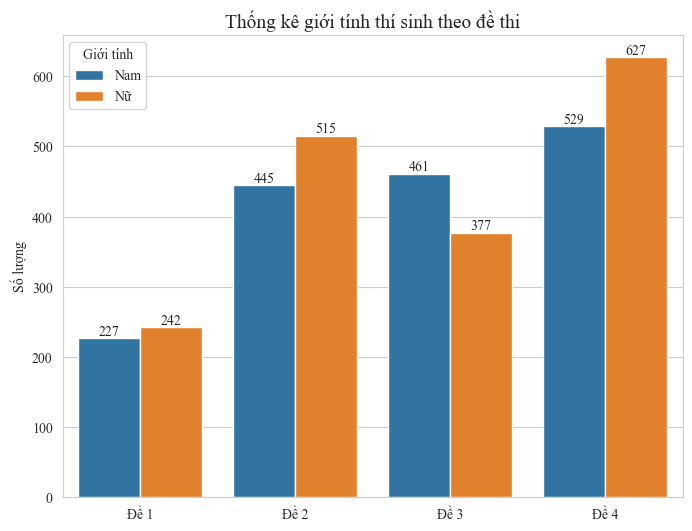

In [9]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.figure(figsize=(8, 6))
sns.countplot(data=gioi.melt(var_name='Đề', value_name='Giới tính'), x='Đề', hue='Giới tính')
plt.title('Thống kê giới tính thí sinh theo đề thi', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')
#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [ ]:
# lập thành bảng thống kê
gioi_counts = gioi.apply(pd.Series.value_counts).astype(int)
gioi_counts

,Đề 1,Đề 2,Đề 3,Đề 4
Nam,227,445,461,529
Nữ,242,515,377,627


### Thực hiện chấm điểm thô (số câu đúng)

Chấm đáp án

In [10]:
df_chamdiem_1 = ip.ketQuaCham(df_dot1, da_1)
print('Đã chấm điểm xong đề 1')
df_chamdiem_2 = ip.ketQuaCham(df_dot2, da_2)
print('Đã chấm điểm xong đề 2')
df_chamdiem_3 = ip.ketQuaCham(df_dot3, da_3)
print('Đã chấm điểm xong đề 3')

Đã chấm điểm xong đề 1
Đã chấm điểm xong đề 2
Đã chấm điểm xong đề 3


In [ ]:
df_dot4

,SBD,Timestamp,Email,Name,Gioi,MaDe,Cau1,Cau2,Cau3,Cau4,...,Cau111,Cau112,Cau113,Cau114,Cau115,Cau116,Cau117,Cau118,Cau119,Cau120
0,140001,2026/05/22 12:03:28 AM GMT+7,07vudinhchien8a2@gmail.com,Vũ Đình Chiến,Nam,345,A,C,D,B,...,D,NaN,NaN,NaN,B,B,A,D,B,D
1,140002,2026/05/19 6:06:09 PM GMT+7,0962449145mai@gmail.com,Nguyễn Gia Bảo Thịnh,Nam,345,A,C,B,B,...,A,C,C,D,A,B,A,C,B,C
2,140003,2026/05/20 10:37:50 PM GMT+7,11042008nhuquynh@gmail.com,Vitamin Trump,Nữ,202,D,B,D,B,...,B,D,B,A,A,C,C,B,B,C
3,140004,2026/05/21 10:02:44 PM GMT+7,12a4.2.vuquanganh@gmail.com,Vũ Quang Anh,Nam,188,A,A,A,A,...,C,A,B,B,A,A,A,A,B,B
4,140005,2026/05/17 5:19:26 PM GMT+7,2000ngophat@gmail.com,Ngô Tấn Phát,Nam,345,A,D,C,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,141152,2026/05/21 6:16:10 PM GMT+7,yentrang4957@gmail.com,Lê Thị Yến Trang,Nữ,345,A,D,B,B,...,D,C,A,A,A,B,A,B,B,D
1152,141153,2026/05/20 9:30:35 PM GMT+7,yphungnguyenmy@gmail.com,Nguyễn Mỹ Y Phụng,Nữ,423,B,B,D,C,...,A,B,C,B,A,A,C,D,C,A
1153,141154,2026/05/21 12:37:44 AM GMT+7,zanamykim1990@gmail.com,nguyen vo my kim,Nữ,188,A,B,A,D,...,C,D,D,C,B,C,B,A,D,C
1154,141155,2026/05/19 6:01:58 PM GMT+7,zphucizme@gmail.com,Vinh Phuc,Nam,202,D,B,C,B,...,B,D,D,A,A,B,D,D,B,C


In [11]:
df_chamdiem_4 = pd.read_csv('df_chamdiem_4.csv').merge(df_dot4[['SBD', 'Email', 'Name', 'Gioi']], on='SBD', how='left')
df_chamdiem_4

,SBD,MaDe,Cau1,Cau2,Cau3,Cau4,Cau5,Cau6,Cau7,Cau8,...,Cau114,Cau115,Cau116,Cau117,Cau118,Cau119,Cau120,Email,Name,Gioi
0,140001,345,1,0,1,0,1,1,1,0,...,-1,1,0,0,0,1,1,07vudinhchien8a2@gmail.com,Vũ Đình Chiến,Nam
1,140002,345,1,0,1,0,0,1,1,0,...,1,0,0,1,1,1,0,0962449145mai@gmail.com,Nguyễn Gia Bảo Thịnh,Nam
2,140003,202,1,0,1,1,0,1,0,0,...,1,0,1,1,1,0,1,11042008nhuquynh@gmail.com,Vitamin Trump,Nữ
3,140004,188,1,0,1,0,0,0,1,0,...,1,0,1,0,0,0,0,12a4.2.vuquanganh@gmail.com,Vũ Quang Anh,Nam
4,140005,345,1,0,1,1,1,1,1,0,...,-1,-1,-1,-1,-1,-1,-1,2000ngophat@gmail.com,Ngô Tấn Phát,Nam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,141152,345,1,0,1,0,1,1,1,0,...,0,0,1,0,0,1,1,yentrang4957@gmail.com,Lê Thị Yến Trang,Nữ
1152,141153,423,1,0,1,1,0,1,1,0,...,0,0,0,0,1,1,1,yphungnguyenmy@gmail.com,Nguyễn Mỹ Y Phụng,Nữ
1153,141154,188,1,0,1,1,0,0,1,1,...,0,1,1,0,0,1,1,zanamykim1990@gmail.com,nguyen vo my kim,Nữ
1154,141155,202,1,0,0,1,1,1,1,0,...,1,0,1,1,1,1,1,zphucizme@gmail.com,Vinh Phuc,Nam


In [12]:
order_kho = ['Rất dễ', 'Dễ', 'Tương đối dễ', 'Bình thường', 'Tương đối khó', 'Khó','Rất khó']
order_pb  = ['Kém', 'Chưa tốt', 'Chấp nhận được', 'Tương đối tốt', 'Tốt', 'Rất tốt','Quá tốt']
order_nhieu = ["Kém", "Yếu", "Bình thường", "Tốt"]

In [13]:
df_chamdiem_4[['Cau71', 'Cau72', 'Cau95']] =1

Thực hiện tính điểm thô

In [14]:
df_TV1, df_TA1, df_TO1, df_KH1 = ip.tach_phan(df_chamdiem_1)
df_TV2, df_TA2, df_TO2, df_KH2 = ip.tach_phan(df_chamdiem_2)
df_TV3, df_TA3, df_TO3, df_KH3 = ip.tach_phan(df_chamdiem_3)
df_TV4, df_TA4, df_TO4, df_KH4 = ip.tach_phan(df_chamdiem_4)



for data in [df_TV1, df_TA1, df_TO1, df_KH1, df_TV2, df_TA2, df_TO2, df_KH2, df_TV3, df_TA3, df_TO3, df_KH3, df_TV4, df_TA4, df_TO4, df_KH4]:
    data = ip.tinh_diem(data)

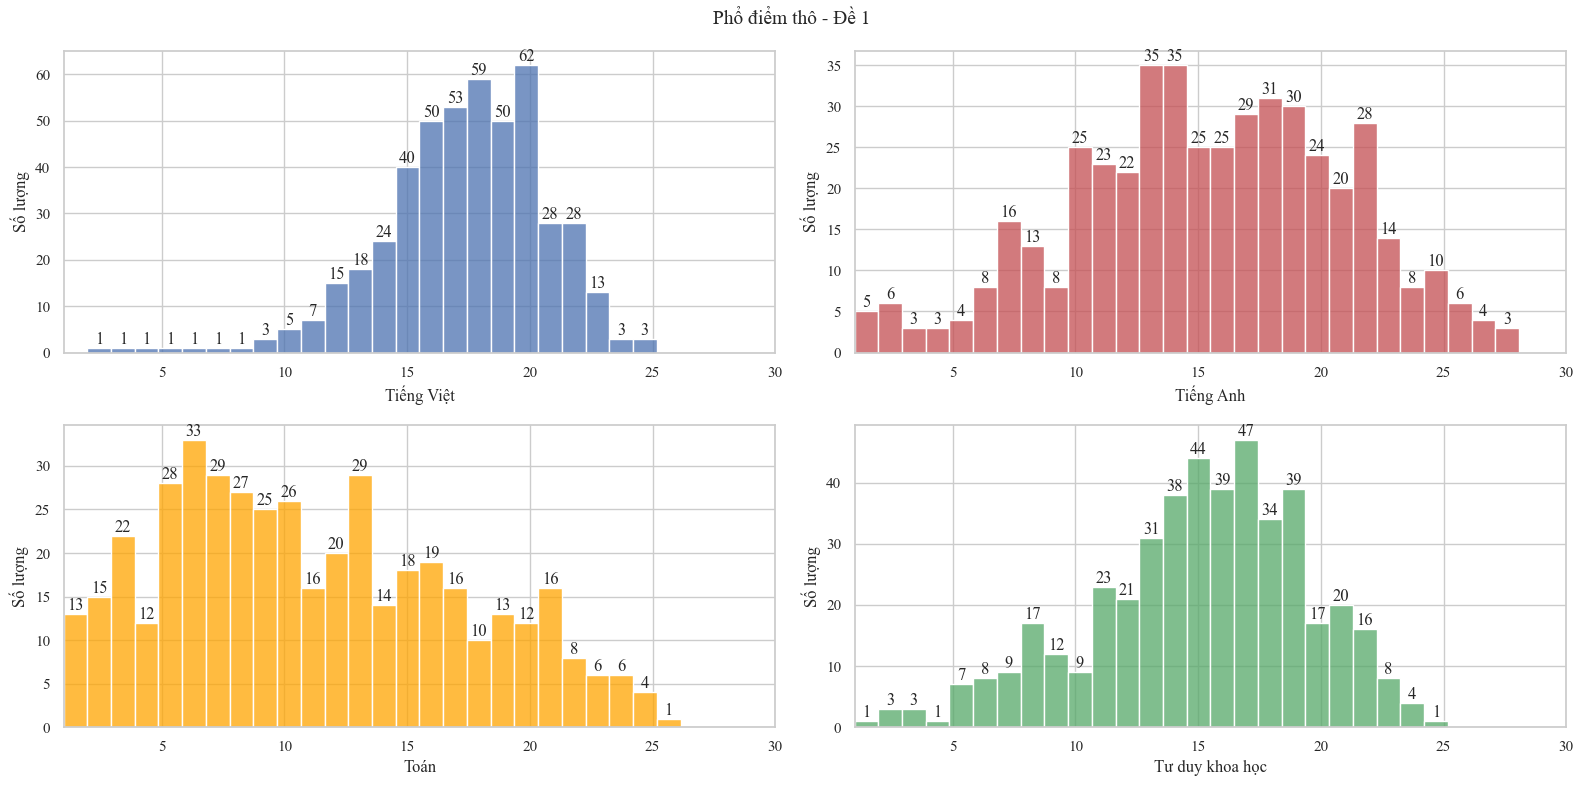

In [15]:
df_raw_1 = df_TV1[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw_1 = df_raw_1.merge(df_TA1[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_1 = df_raw_1.merge(df_TO1[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_1 = df_raw_1.merge(df_KH1[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw_1, col_name='Raw', title='Phổ điểm thô - Đề 1', range=(1,30))

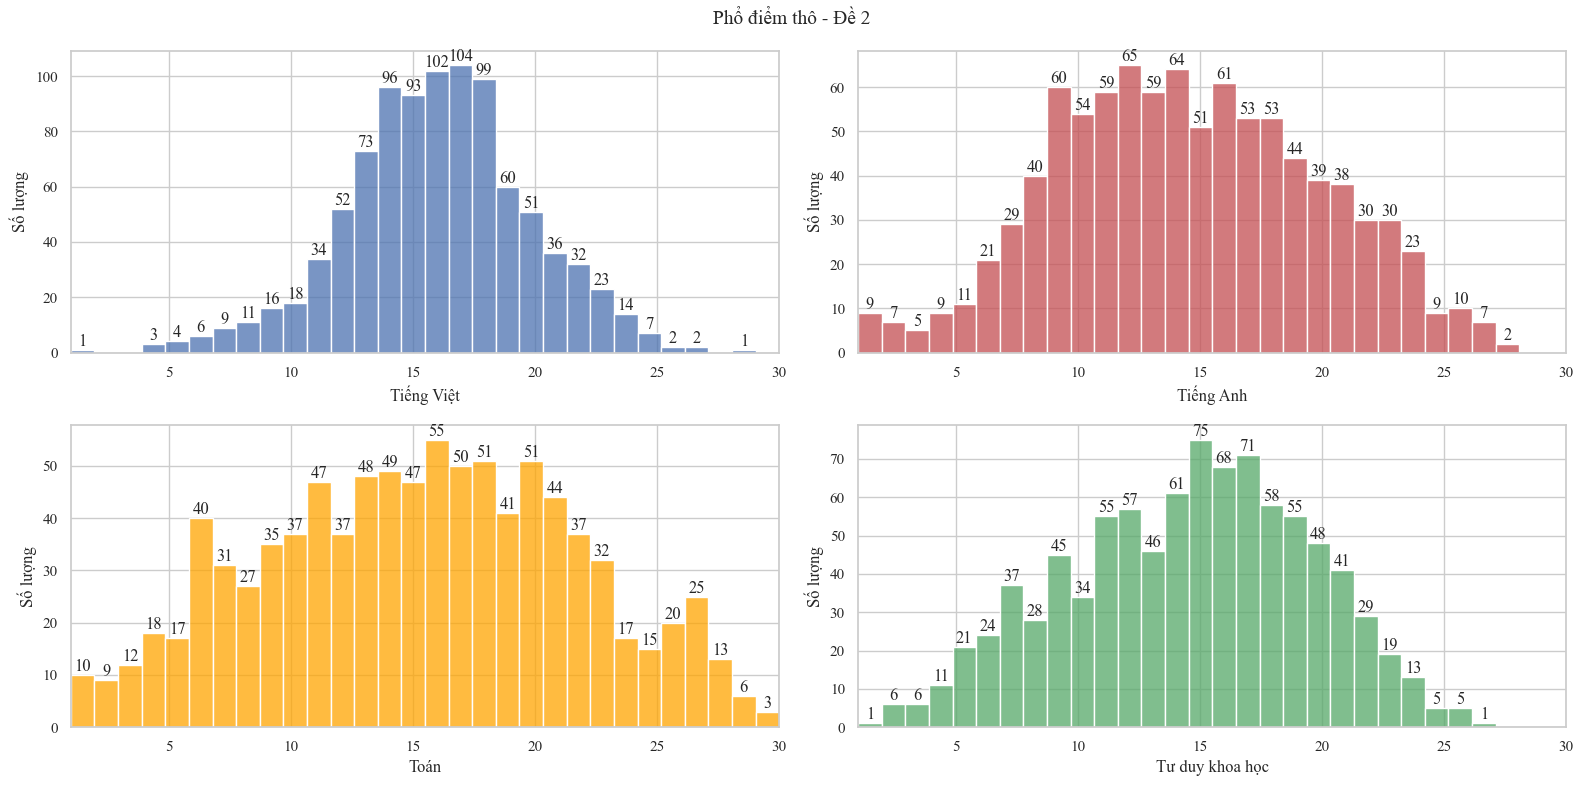

In [16]:
df_raw_2 = df_TV2[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw_2 = df_raw_2.merge(df_TA2[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_2 = df_raw_2.merge(df_TO2[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_2 = df_raw_2.merge(df_KH2[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw_2, col_name='Raw', title='Phổ điểm thô - Đề 2', range=(1,30))

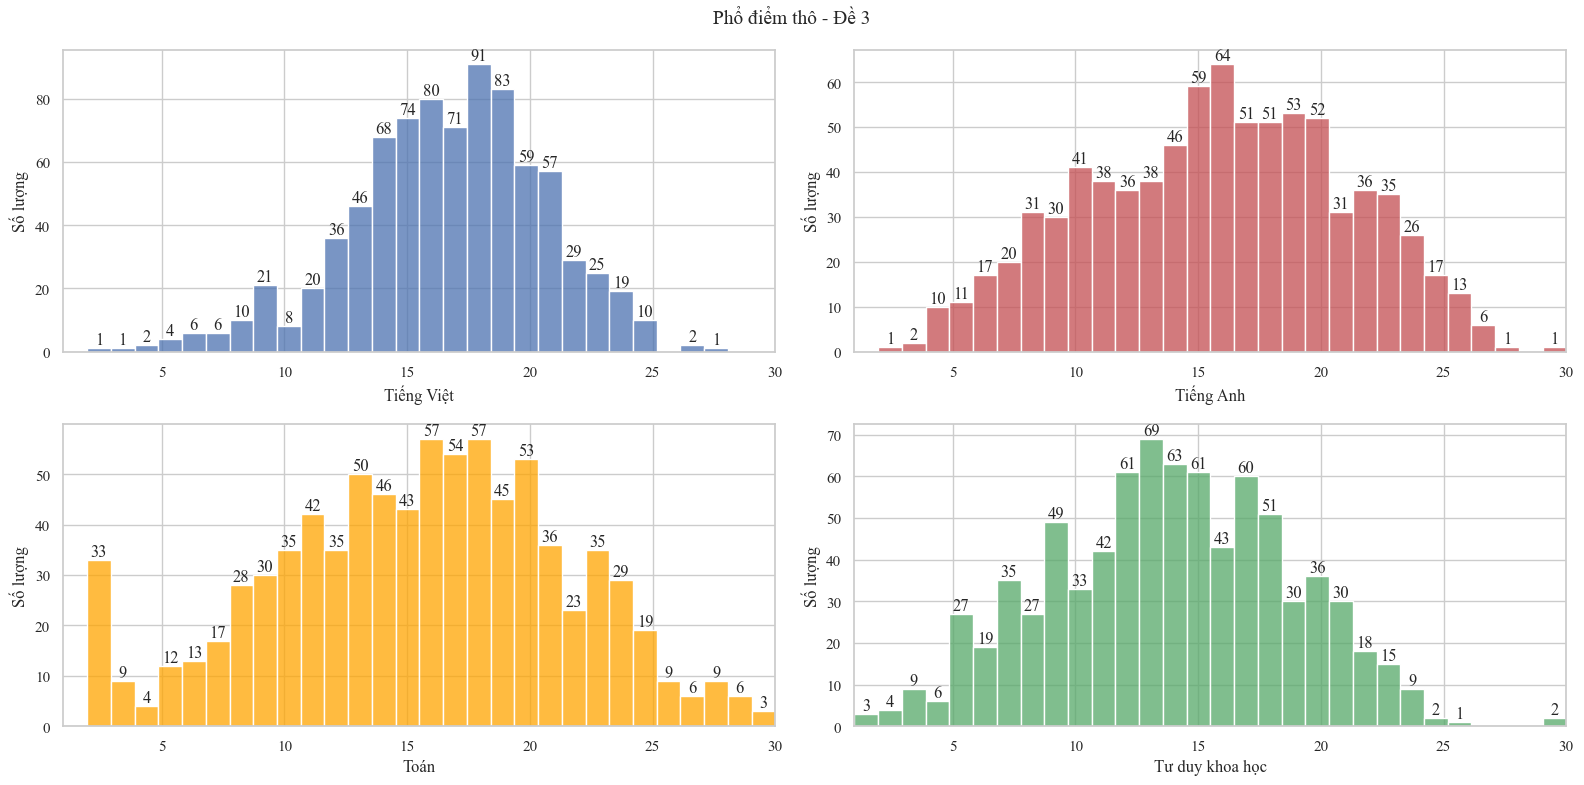

In [17]:
df_raw_3 = df_TV3[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw_3 = df_raw_3.merge(df_TA3[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_3 = df_raw_3.merge(df_TO3[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_3 = df_raw_3.merge(df_KH3[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')

ip.draw_plot(df_raw_3, col_name='Raw', title='Phổ điểm thô - Đề 3', range=(1,30))

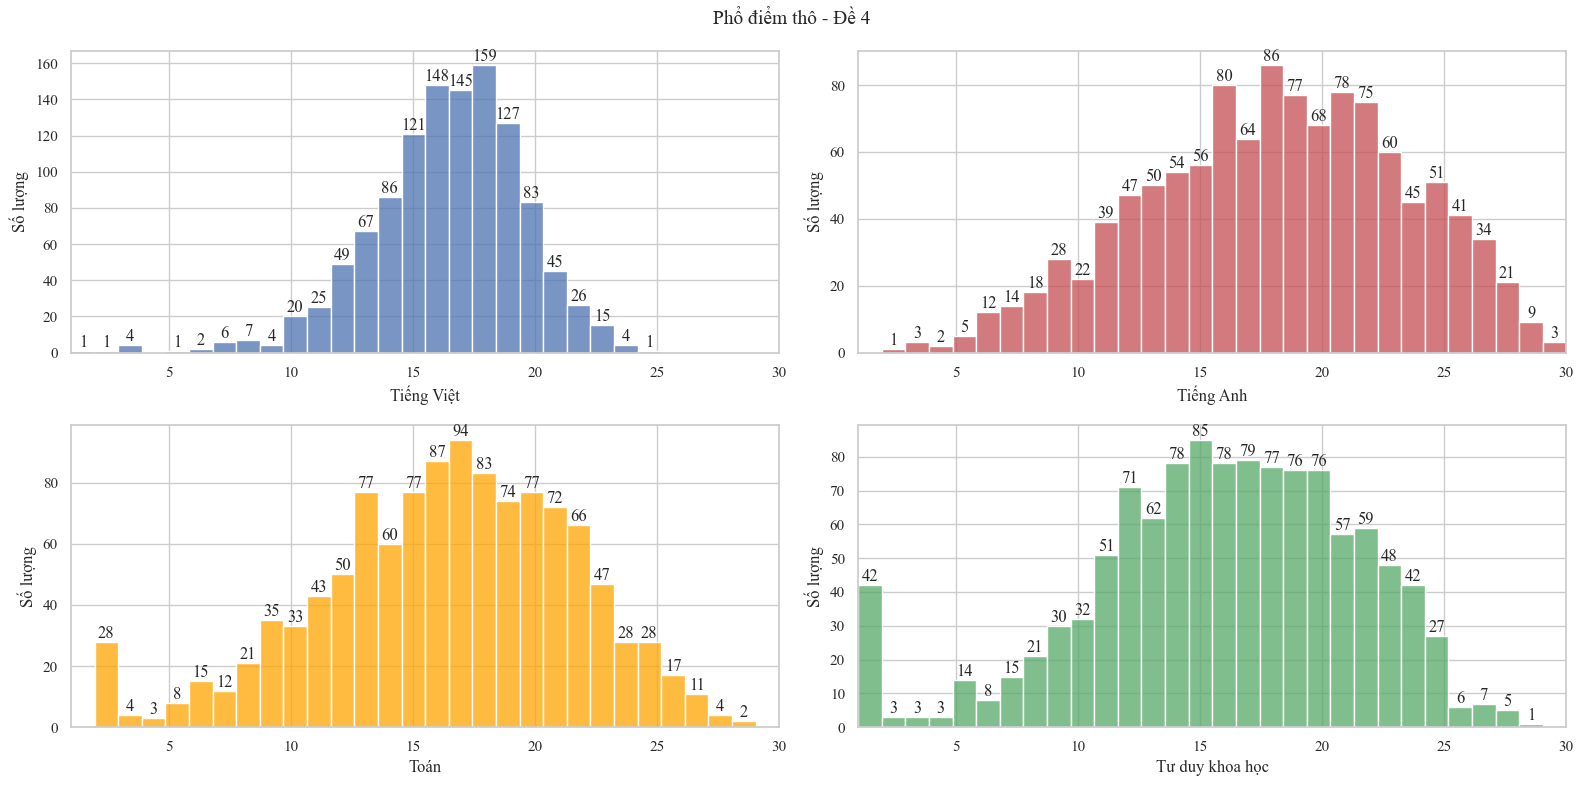

In [18]:
df_raw_4 = df_TV4[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw_4 = df_raw_4.merge(df_TA4[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_4 = df_raw_4.merge(df_TO4[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_4 = df_raw_4.merge(df_KH4[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')

ip.draw_plot(df_raw_4, col_name='Raw', title='Phổ điểm thô - Đề 4', range=(1,30))

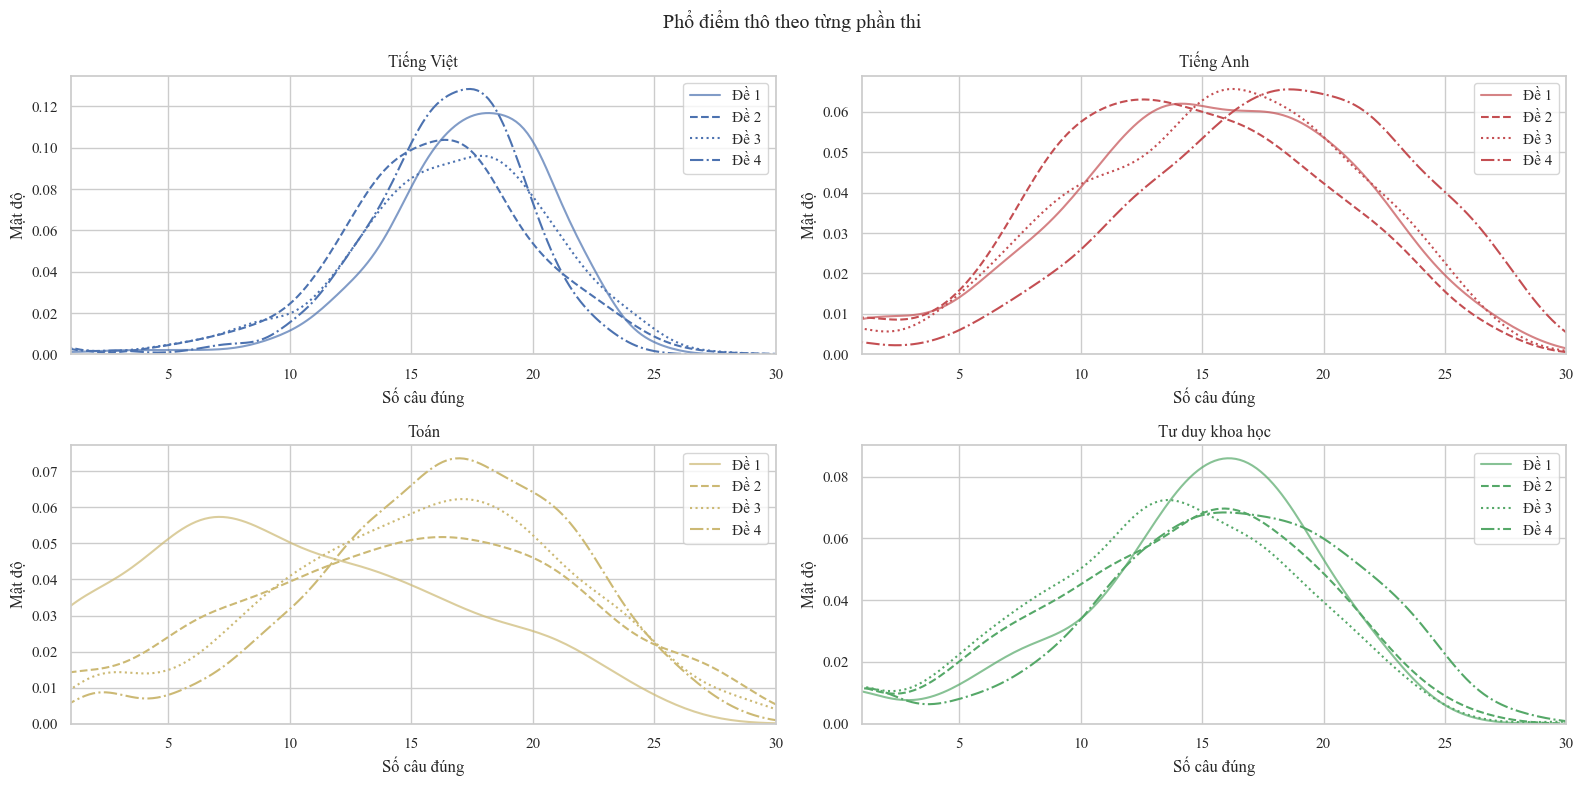

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

def plot_kde(ax, de_1, de_2, de_3, de_4, title, color):
        sns.kdeplot(
            x=de_1,
            color=color, fill=False, alpha=0.7, label="Đề 1", ax=ax
        )
        sns.kdeplot(
            x=de_2,
            color=color, fill=False, alpha=1.0, linestyle="--", label="Đề 2", ax=ax
        )
        sns.kdeplot(
            x=de_3,
            color=color, fill=False, alpha=1.0, linestyle=":", label="Đề 3", ax=ax
        )
        sns.kdeplot(
            x=de_4,
            color=color, fill=False, alpha=1.0, linestyle="-.", label="Đề 4", ax=ax
        )

        ax.set_xlabel('Số câu đúng')
        ax.set_xlim(1, 30)
        ax.set_ylabel("Mật độ")
        ax.set_title(f"{title}")
        ax.legend()

plot_kde(axes[0], df_TV1["Raw"], df_TV2["Raw"], df_TV3["Raw"], df_TV4["Raw"], "Tiếng Việt", color='b')
plot_kde(axes[1], df_TA1["Raw"], df_TA2["Raw"], df_TA3["Raw"], df_TA4["Raw"], "Tiếng Anh", color='r')
plot_kde(axes[2], df_TO1["Raw"], df_TO2["Raw"], df_TO3["Raw"], df_TO4["Raw"], "Toán", color='y')
plot_kde(axes[3], df_KH1["Raw"], df_KH2["Raw"], df_KH3["Raw"], df_KH4["Raw"], "Tư duy khoa học", color='g')

plt.suptitle('Phổ điểm thô theo từng phần thi', y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
df_raw_1[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,469.000000,469.000000,469.000000,469.000000
mean,17.360341,15.202559,10.279318,14.484009
std,3.524670,5.924698,6.542826,5.292942
min,0.000000,0.000000,0.000000,0.000000
25%,15.000000,11.000000,5.000000,12.000000
50%,18.000000,15.000000,9.000000,15.000000
75%,20.000000,19.000000,15.000000,18.000000
max,25.000000,28.000000,26.000000,25.000000


In [ ]:
df_raw_2[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,960.000000,960.000000,960.000000,960.000000
mean,15.840625,14.158333,14.668750,13.845833
std,4.250083,5.829336,7.087614,5.811353
min,0.000000,0.000000,0.000000,0.000000
25%,14.000000,10.000000,10.000000,10.000000
50%,16.000000,14.000000,15.000000,15.000000
75%,18.000000,18.000000,20.000000,18.000000
max,29.000000,28.000000,30.000000,27.000000


In [ ]:
df_raw_3[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,838.000000,838.000000,838.000000,838.000000
mean,16.529833,15.342482,15.455847,13.210024
std,4.380465,5.930371,6.197840,5.629016
min,0.000000,0.000000,2.000000,0.000000
25%,14.000000,11.000000,11.000000,9.000000
50%,17.000000,16.000000,16.000000,14.000000
75%,19.000000,20.000000,20.000000,17.000000
max,28.000000,30.000000,30.000000,30.000000


In [ ]:
df_raw_4[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,1156.000000,1156.000000,1156.000000,1156.000000
mean,16.323529,17.953287,16.377163,15.640138
std,3.520257,5.792178,5.410552,5.539961
min,0.000000,0.000000,2.000000,1.000000
25%,15.000000,14.000000,13.000000,12.000000
50%,17.000000,18.000000,17.000000,16.000000
75%,19.000000,22.000000,20.000000,20.000000
max,25.000000,30.000000,29.000000,28.000000


In [ ]:
rawtotal_1 = pd.Series(df_TV1['Raw'] + df_TA1['Raw'] + df_TO1['Raw'] + df_KH1['Raw'])
rawtotal_2 = pd.Series(df_TV2['Raw'] + df_TA2['Raw'] + df_TO2['Raw'] + df_KH2['Raw'])
rawtotal_3 = pd.Series(df_TV3['Raw'] + df_TA3['Raw'] + df_TO3['Raw'] + df_KH3['Raw'])
rawtotal_4 = pd.Series(df_TV4['Raw'] + df_TA4['Raw'] + df_TO4['Raw'] + df_KH4['Raw'])

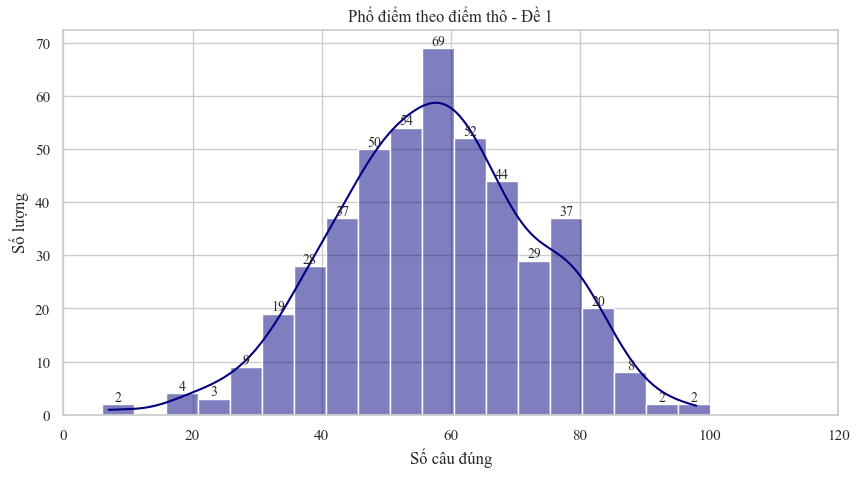

In [ ]:
ip.plot_total(rawtotal_1, title='Phổ điểm theo điểm thô - Đề 1', range=(1,120), color='navy', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

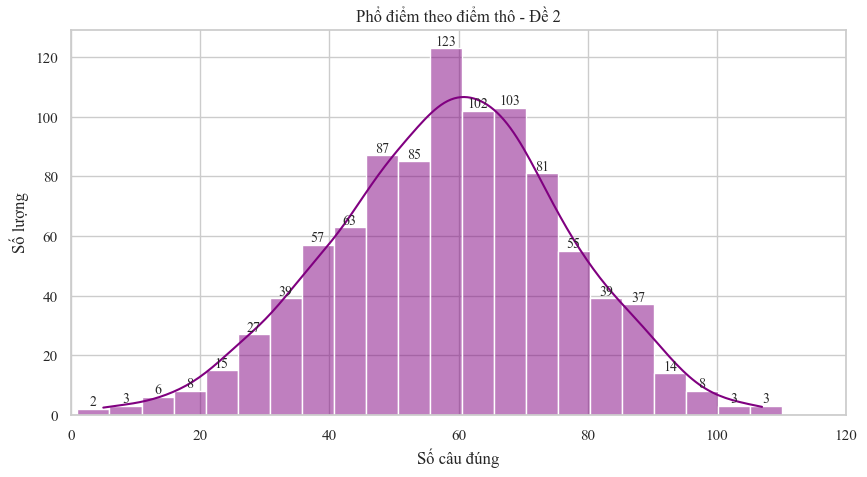

In [ ]:
ip.plot_total(rawtotal_2, title='Phổ điểm theo điểm thô - Đề 2', range=(1,120), color='purple', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

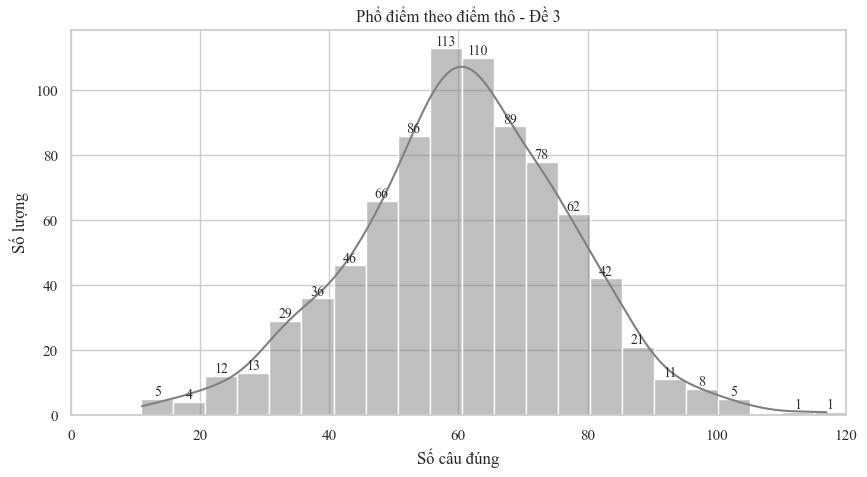

In [ ]:
ip.plot_total(rawtotal_3, title='Phổ điểm theo điểm thô - Đề 3', range=(1,120), color='grey', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

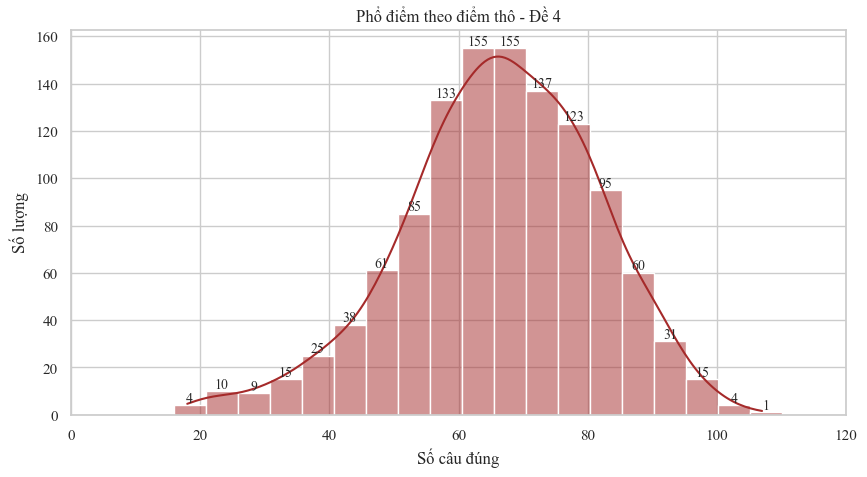

In [ ]:
ip.plot_total(rawtotal_4, title='Phổ điểm theo điểm thô - Đề 4', range=(1,120), color='brown', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

### Phân tích điểm TBHK các môn học

NameError: name 'df_survey' is not defined

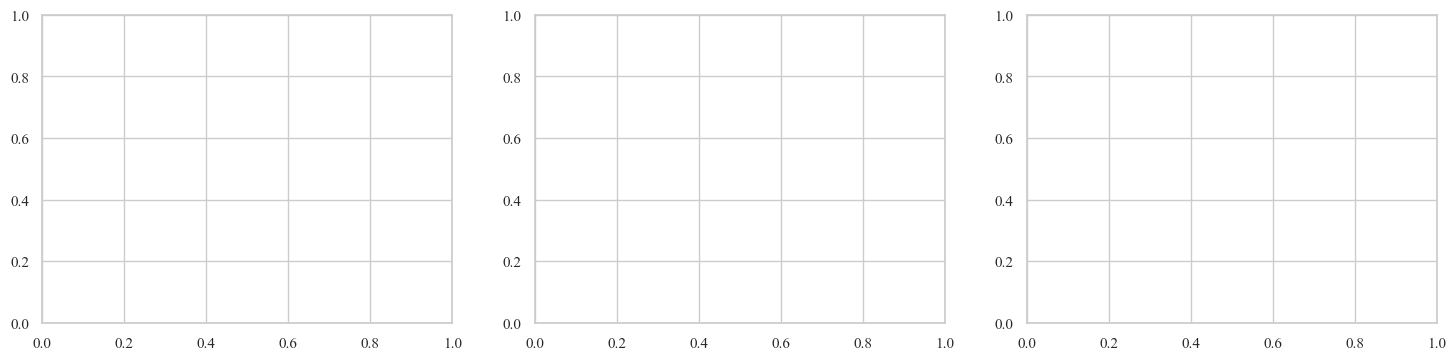

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 4))

parts = ['TV', 'TA', 'TO']

for i, part in enumerate(parts):
    sns.kdeplot(
        df_survey[f'{part}10_1'],
        ax=axes[i],
        label='HK1 - L10'
    )
    sns.kdeplot(
        df_survey[f'{part}10_2'],
        ax=axes[i],
        label='HK2 - L10'
    )
    sns.kdeplot(
        df_survey[f'{part}11_1'],
        ax=axes[i],
        label='HK1 - L11'
    )
    sns.kdeplot(
        df_survey[f'{part}11_2'],
        ax=axes[i],
        label='HK2 - L11'
    )

    axes[i].set_xlim(1, 10)
    axes[i].set_xlabel(f'TBHK - {part}')
    axes[i].set_ylabel('Mật độ')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Thống kê kết quả học tập của những học sinh có tham gia khảo sát', y=1.02)
plt.show()


In [ ]:
df_survey.describe()

NameError: name 'df_survey' is not defined

## Phân tích theo lý thuyết khảo thí cổ điển

#### Độ khó

In [20]:
diff_1, diff_2, diff_3, diff_4 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

# Đề 1
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    b = ctt.cal_diff(data[data['Null'] < 30])
    diff_1 = pd.concat([diff_1, b], axis=0)

# Đề 2
for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    b = ctt.cal_diff(data[data['Null'] < 30])
    diff_2 = pd.concat([diff_2, b], axis=0)

# Đề 3
for data in [df_TV3, df_TA3, df_TO3, df_KH3]:
    b = ctt.cal_diff(data[data['Null'] < 30])
    diff_3 = pd.concat([diff_3, b], axis=0)

# Đề 4
for data in [df_TV4, df_TA4, df_TO4, df_KH4]:
     b = ctt.cal_diff(data[data['Null'] < 30])
     diff_4 = pd.concat([diff_4, b], axis=0)

# Đổi tên cột
diff_1 = diff_1.rename({0: 'CTT'}, axis=1)
diff_2 = diff_2.rename({0: 'CTT'}, axis=1)
diff_3 = diff_3.rename({0: 'CTT'}, axis=1)
diff_4 = diff_4.rename({0: 'CTT'}, axis=1)

In [21]:
def b_category(diff):
    if diff > 0.9:
        return 'Rất dễ'
    elif diff > 0.75:
        return 'Dễ'
    elif diff > 0.6:
        return 'Tương đối dễ'
    elif diff > 0.4:
        return 'Bình thường'
    elif diff > 0.25:
        return 'Tương đối khó'
    elif diff > 0.1:
        return 'Khó'
    else:
        return 'Rất khó'

diff_1['Phân loại'] = diff_1['CTT'].apply(b_category)
diff_2['Phân loại'] = diff_2['CTT'].apply(b_category)
diff_3['Phân loại'] = diff_3['CTT'].apply(b_category)
diff_4['Phân loại'] = diff_4['CTT'].apply(b_category)

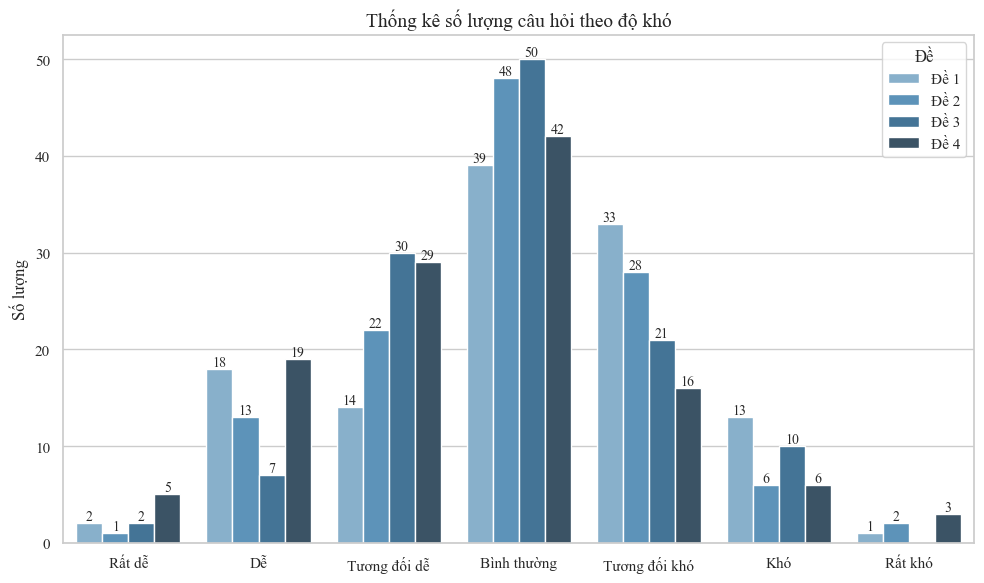

In [22]:
ip.plot_item(diff_1, diff_2, diff_3, diff_4, title='Thống kê số lượng câu hỏi theo độ khó', order=order_kho, palette='Blues_d', size=(10,6))

In [23]:
diff_1['Phần thi'] = (
    diff_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_2['Phần thi'] = (
    diff_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_3['Phần thi'] = (
    diff_3.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_4['Phần thi'] = (
    diff_4.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

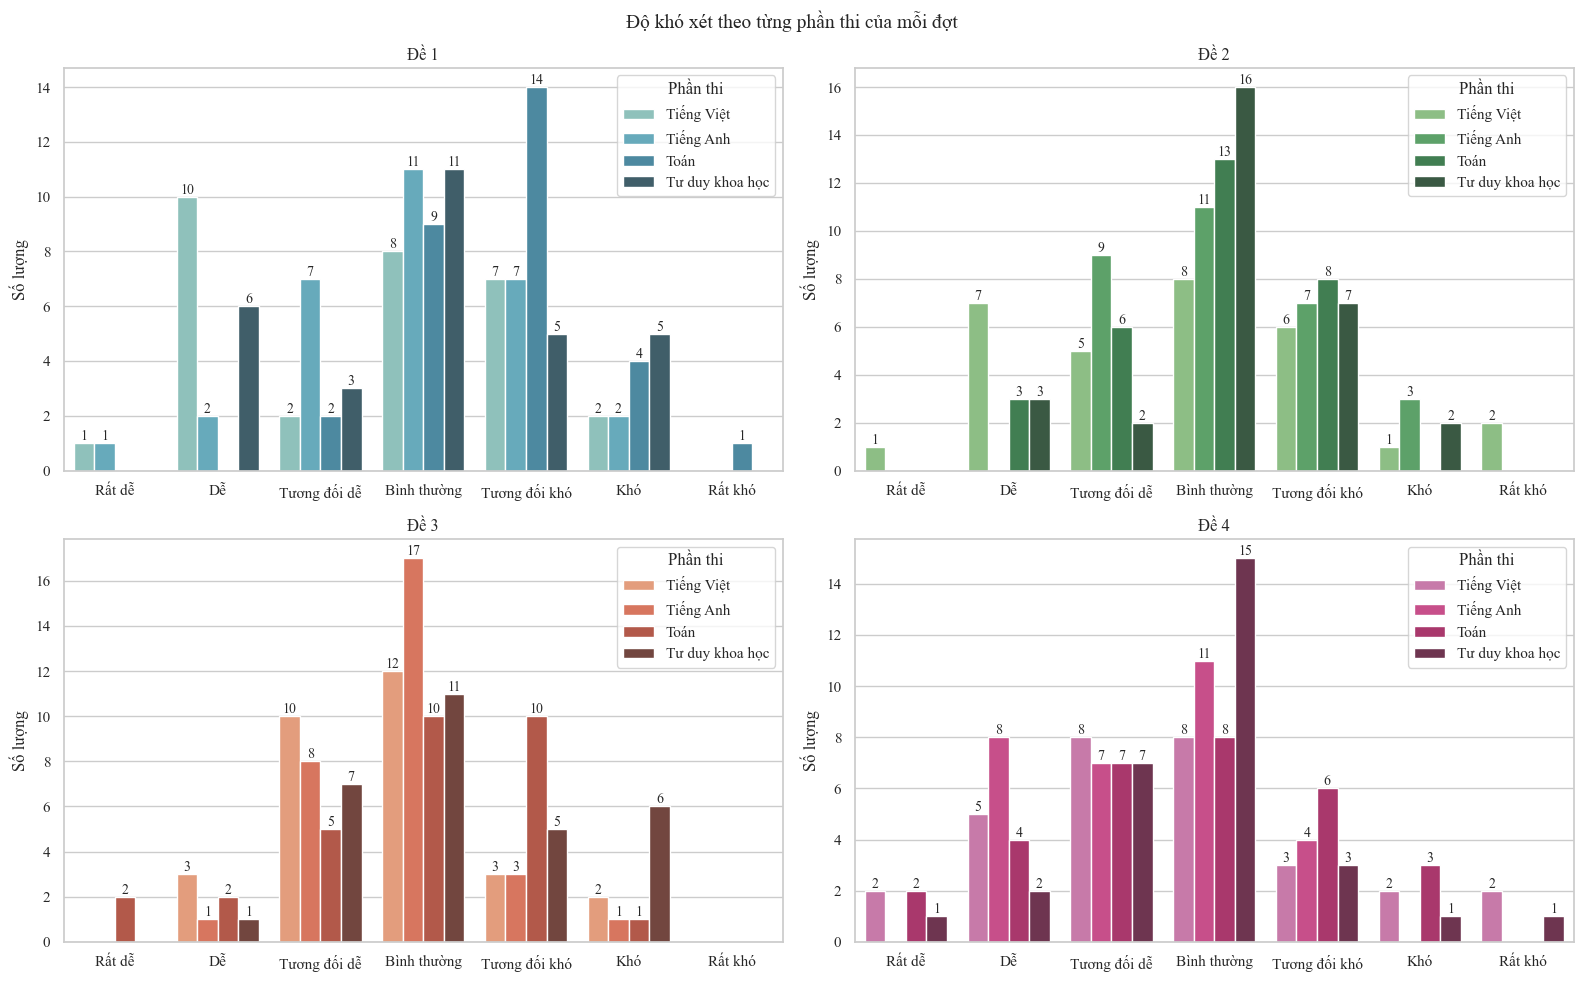

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# =========================
# HÀM VẼ CHUNG
# =========================
def draw_countplot(ax, data, palette, title, order):
    sns.countplot(
        data=data,
        x='Phân loại',
        palette=palette,
        ax=ax,
        hue='Phần thi',
        order=order
    )

    ax.set_title(title)
    ax.set_ylabel('Số lượng')
    ax.set_xlabel(None)

    # Hiển thị số trên cột
    for p in ax.patches:
        height = p.get_height()

        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (
                    p.get_x() + p.get_width() / 2,
                    height
                ),
                ha='center',
                va='bottom',
                fontsize=10
            )

    # Tự động ticks trục Y
    max_y = int(max([p.get_height() for p in ax.patches] or [0]))

    if max_y <= 10:
        step = 1
    elif max_y <= 30:
        step = 2
    else:
        step = 5

    ax.set_yticks(range(0, max_y + 1, step))


# =========================
# ĐỀ 1
# =========================
draw_countplot(
    axes[0],
    diff_1,
    'GnBu_d',
    'Đề 1',
    order=order_kho
)

# =========================
# ĐỀ 2
# =========================
draw_countplot(
    axes[1],
    diff_2,
    'YlGn_d',
    'Đề 2',
    order=order_kho
)

# =========================
# ĐỀ 3
# =========================
draw_countplot(
    axes[2],
    diff_3,
    'OrRd_d',
    'Đề 3',
    order=order_kho
)

# =========================
# ĐỀ 4
# =========================
draw_countplot(
    axes[3],
    diff_4,
    'PuRd_d',
    'Đề 4',
    order=order_kho
)

plt.suptitle(
    'Độ khó xét theo từng phần thi của mỗi đợt',
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

/content/item_plot.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:368: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


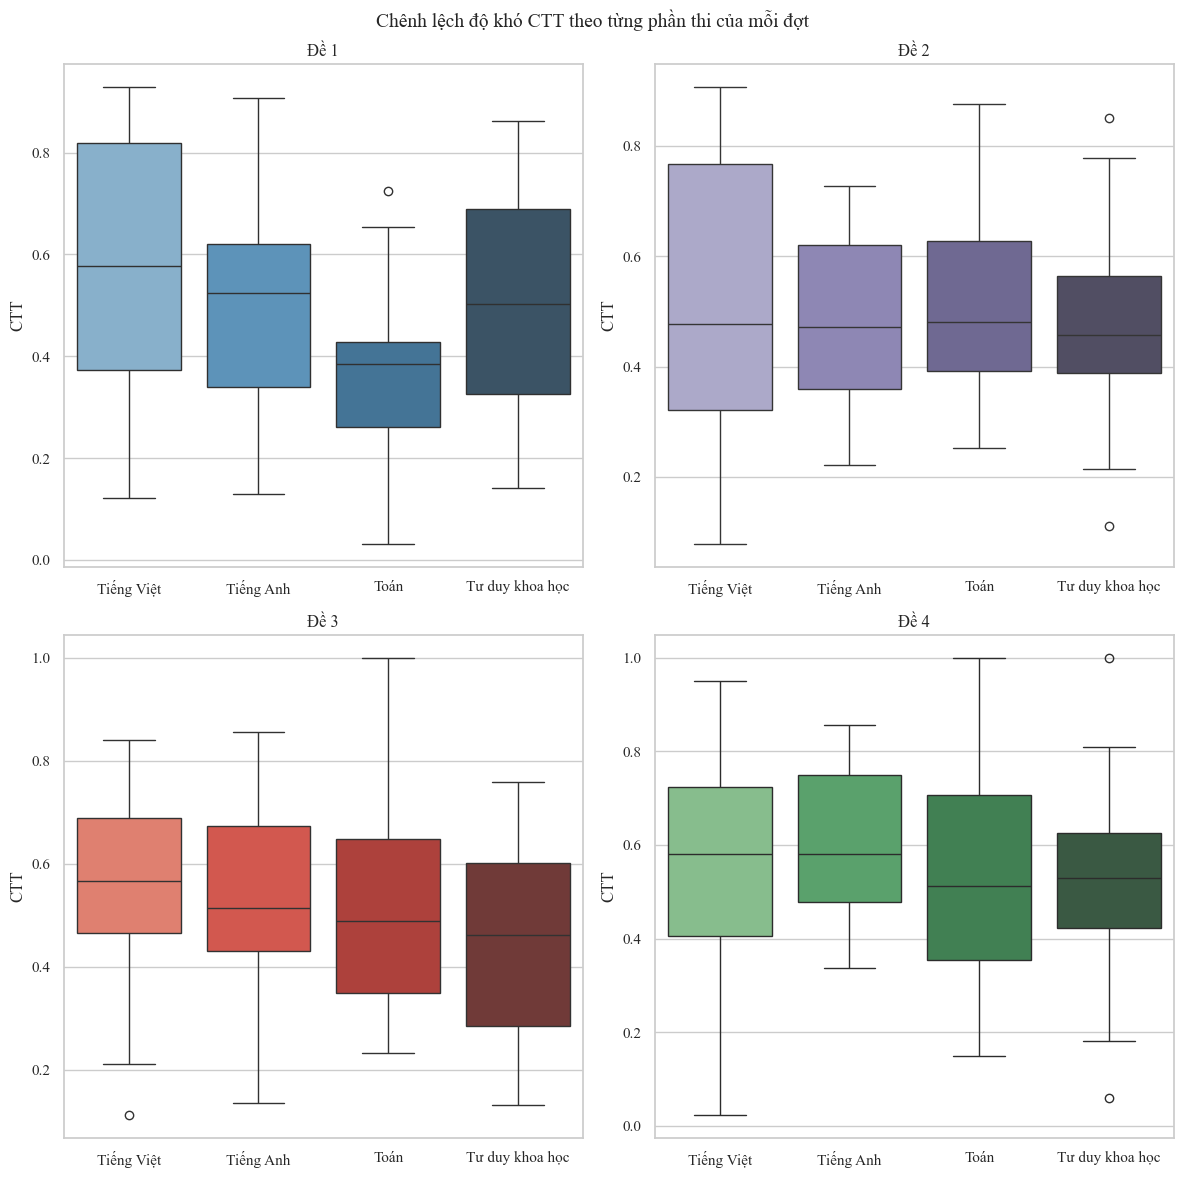

In [25]:
ip.draw_box_plot(
    diff_1,
    diff_2,
    diff_3,
    diff_4,
    'Phần thi',
    'CTT',
    'Blues_d',
    'Purples_d',
    'Reds_d',
    'Greens_d',
    'Chênh lệch độ khó CTT theo từng phần thi của mỗi đợt'
)


#### Độ phân biệt

In [26]:
disc_1, disc_2, disc_3, disc_4 =  pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_1 = pd.concat([disc_1, a], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_2 = pd.concat([disc_2, a], axis=0)

for data in [df_TV3, df_TA3, df_TO3, df_KH3]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_3 = pd.concat([disc_3, a], axis=0)

for data in [df_TV4, df_TA4, df_TO4, df_KH4]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_4 = pd.concat([disc_4, a], axis=0)

disc_1 = disc_1.rename({0: 'D-Index'}, axis=1)
disc_2 = disc_2.rename({0: 'D-Index'}, axis=1)
disc_3 = disc_3.rename({0: 'D-Index'}, axis=1)
disc_4 = disc_4.rename({0: 'D-Index'}, axis=1)


In [27]:
def a_category(disc):
    if disc <= 0:
        return 'Kém'
    elif disc <= 0.20:
        return 'Chưa tốt'
    elif disc <= 0.40:
        return 'Chấp nhận được'
    elif disc <= 0.60:
        return 'Tương đối tốt'
    elif disc <= 0.80:
        return 'Tốt'
    elif disc <= 1.0:
        return 'Rất tốt'
    else:
        return 'Quá tốt'

disc_1['Phân loại'] = disc_1['D-Index'].apply(a_category)
disc_2['Phân loại'] = disc_2['D-Index'].apply(a_category)
disc_3['Phân loại'] = disc_3['D-Index'].apply(a_category)
disc_4['Phân loại'] = disc_4['D-Index'].apply(a_category)

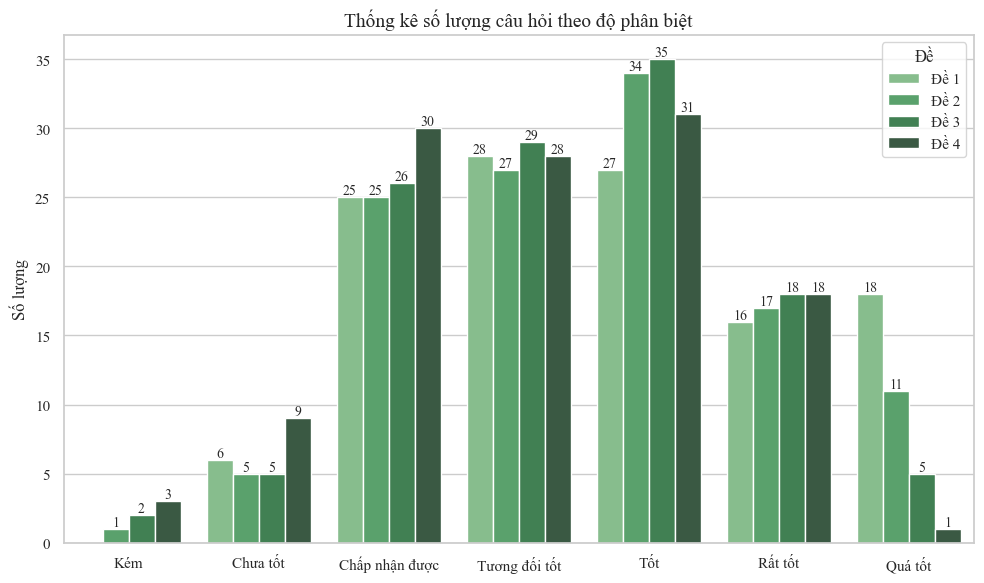

In [28]:
ip.plot_item(disc_1, disc_2, disc_3, disc_4, title='Thống kê số lượng câu hỏi theo độ phân biệt', order=order_pb, palette='Greens_d', size=(10,6))

In [29]:
disc_1['Phần thi'] = (
    disc_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_2['Phần thi'] = (
    disc_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_3['Phần thi'] = (
    disc_3.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_4['Phần thi'] = (
    disc_4.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

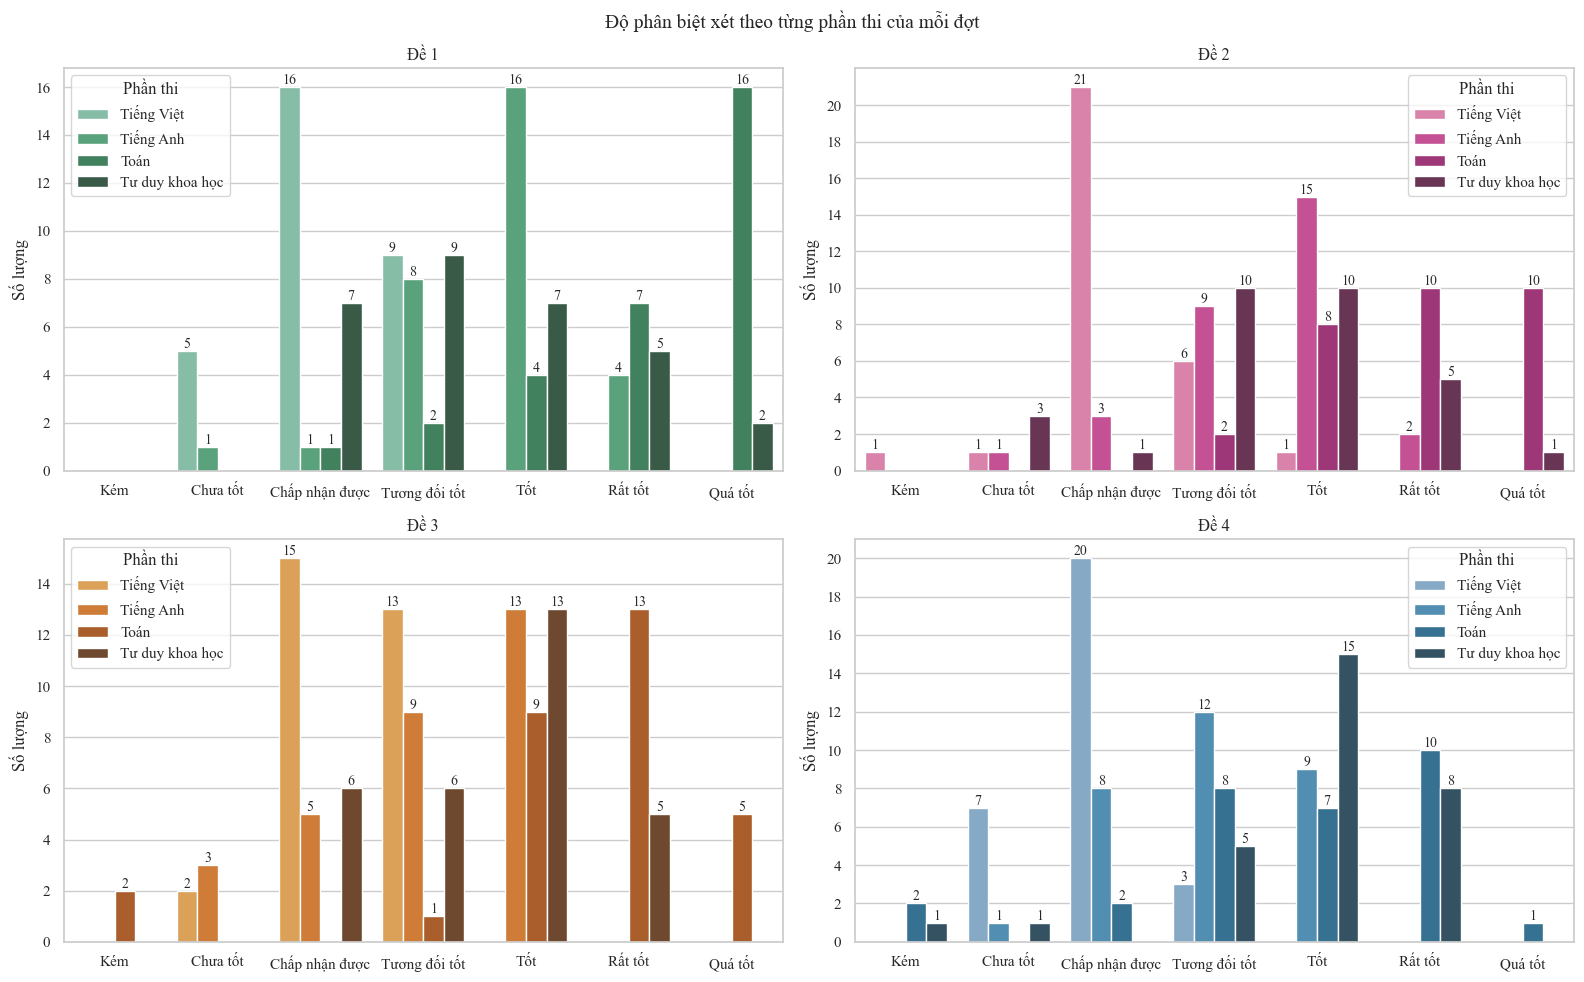

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# =========================
# ĐỀ 1
# =========================
draw_countplot(
    axes[0],
    disc_1,
    'BuGn_d',
    'Đề 1',
    order=order_pb
)

# =========================
# ĐỀ 2
# =========================
draw_countplot(
    axes[1],
    disc_2,
    'RdPu_d',
    'Đề 2',
    order=order_pb
)

# =========================
# ĐỀ 3
# =========================
draw_countplot(
    axes[2],
    disc_3,
    'YlOrBr_d',
    'Đề 3',
    order=order_pb
)

# =========================
# ĐỀ 4
# =========================
draw_countplot(
    axes[3],
    disc_4,
    'PuBu_d',
    'Đề 4',
    order=order_pb
)

plt.suptitle(
    'Độ phân biệt xét theo từng phần thi của mỗi đợt',
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

/content/item_plot.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:368: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


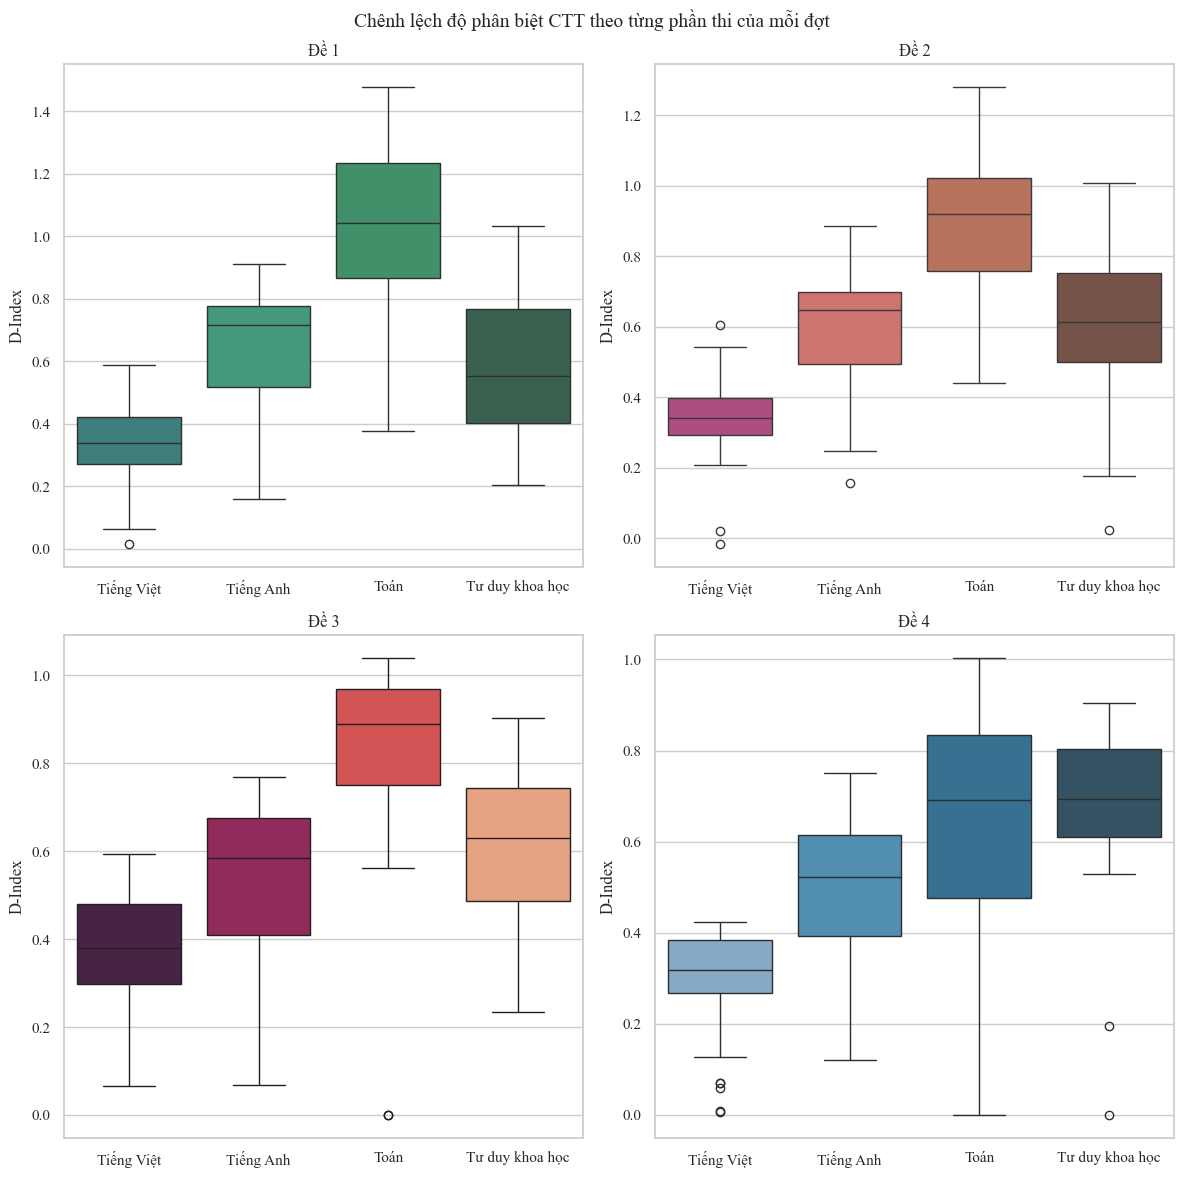

In [31]:
ip.draw_box_plot(disc_1, disc_2, disc_3, disc_4, 'Phần thi', 'D-Index', 'viridis_d', 'plasma_d', 'rocket', 'PuBu_d', 'Chênh lệch độ phân biệt CTT theo từng phần thi của mỗi đợt')

#### Độ nhiễu

In [32]:
def do_nhieu(data: pd.DataFrame, chamdiem, answer: pd.DataFrame, start, end):
    # Merge 1 lần
    data = data.merge(chamdiem[['SBD', 'Raw', 'Null']], on='SBD', how='left')
    ans_row = answer.iloc[0]

    # Kiểm tra định dạng multi (có dấu '-' trong ô đáp án)
    is_multi_format = any(
        '-' in str(ans_row.get(f'Cau{i}', ''))
        for i in range(1, 121)
        if '-' in str(ans_row.get(f'Cau{i}', ''))
    )

    # Nếu là multi-format, build bảng map: {stt_goc: dap_an_dung}
    if is_multi_format:
        correct_map = {}  # {stt_goc: dap_an}
        for i in range(1, 121):
            cell_val = str(ans_row.get(f'Cau{i}', '')).strip()
            if '-' in cell_val:
                parts = cell_val.split('-', 1)
                try:
                    stt_goc = int(parts[0].strip())
                    dap_an = parts[1].strip().upper()
                    correct_map[stt_goc] = dap_an
                except (ValueError, IndexError):
                    correct_map[i] = ''
            elif cell_val and cell_val.upper() != 'NAN':
                correct_map[i] = cell_val.upper()

    # DataFrame lưu kết quả tổng hợp
    df_all = pd.DataFrame(columns=["A", "B", "C", "D", "Null", "Ans"])

    # Lọc thí sinh hợp lệ
    valid = data[data['Null'] < 30]

    for stt in range(start, end + 1):
        std = valid['Raw'].std()
        cau_col = f"Cau{stt}"

        # Lấy đáp án đúng theo định dạng
        if is_multi_format:
            correct = correct_map.get(stt, '')
        else:
            correct = str(ans_row.get(cau_col, '')).strip().upper()

        n_total = valid.shape[0]
        pbcc_dict = {}

        for opt in ["A", "B", "C", "D"]:
            true_group  = valid.loc[valid[cau_col] == opt, 'Raw']
            false_group = valid.loc[valid[cau_col] != opt, 'Raw']
            if true_group.shape[0] == 0 or false_group.shape[0] == 0:
                pb = np.nan
            else:
                p = true_group.shape[0] / valid[cau_col].shape[0]
                pb = ctt.cal_pbcc(true_group, false_group, std, p)

            pbcc_dict[opt] = pb

        true_group = valid.loc[valid[cau_col].isna(), 'Raw']
        false_group = valid.loc[valid[cau_col].notna(), 'Raw']
        count = true_group.shape[0]
        percent = count / n_total if n_total > 0 else 0
        pbcc_dict["Null"] = ctt.cal_pbcc(true_group, false_group, std, percent) if count > 0 and false_group.shape[0] > 0 else np.nan

        # PBCC của đáp án đúng
        pbcc_ans = pbcc_dict.get(correct, np.nan)

        df_all.loc[f'Cau{stt}'] = [
            pbcc_dict["A"],
            pbcc_dict["B"],
            pbcc_dict["C"],
            pbcc_dict["D"],
            pbcc_dict["Null"],
            pbcc_ans
        ]

    return df_all

In [33]:
nhieu_1 = pd.concat([do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TV1, start=1, end=30),
                     do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TA1, start=31, end=60),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TO1, start=61, end=90),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_KH1, start=91, end=120),], axis=0)

In [34]:
nhieu_1

,A,B,C,D,Null,Ans
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029
...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710


In [35]:
nhieu_2 = pd.concat([
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TV2, start=1, end=30),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TA2, start=31, end=60),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TO2, start=61, end=90),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_KH2, start=91, end=120),
], axis=0)


In [36]:
nhieu_2

,A,B,C,D,Null,Ans
Cau1,-0.152678,-0.123517,-0.209147,0.378794,-0.093672,0.378794
Cau2,-0.153667,-0.226340,-0.062574,0.292727,0.052369,0.292727
Cau3,-0.067871,-0.180144,0.246688,-0.114061,-0.153309,0.246688
Cau4,0.235328,0.005219,-0.087234,-0.117352,-0.200777,0.235328
Cau5,-0.049794,-0.209088,-0.156999,0.307156,-0.219060,0.307156
...,...,...,...,...,...,...
Cau116,-0.131594,0.382895,-0.187552,-0.082131,-0.255466,0.382895
Cau117,-0.168627,-0.051673,-0.176895,0.347986,-0.253137,0.347986
Cau118,-0.135239,-0.208441,-0.158354,0.528762,-0.366208,0.528762
Cau119,0.505382,-0.136130,-0.159017,-0.087497,-0.357051,0.505382


In [37]:
nhieu_3 = pd.concat([
    do_nhieu(data=df_dot3, answer=da_3, chamdiem=df_TV3, start=1, end=30),
    do_nhieu(data=df_dot3, answer=da_3, chamdiem=df_TA3, start=31, end=60),
    do_nhieu(data=df_dot3, answer=da_3, chamdiem=df_TO3, start=61, end=90),
    do_nhieu(data=df_dot3, answer=da_3, chamdiem=df_KH3, start=91, end=120),
], axis=0)
nhieu_3

,A,B,C,D,Null,Ans
Cau1,-0.196316,0.307020,-0.085670,-0.178515,-0.186797,0.307020
Cau2,-0.192512,-0.124757,-0.084541,0.249887,-0.170355,0.249887
Cau3,0.272424,-0.185324,-0.185131,-0.136322,-0.179731,0.272424
Cau4,0.253174,-0.160328,-0.137738,-0.074371,-0.269166,0.253174
Cau5,0.352984,-0.233736,-0.165422,-0.140534,-0.314263,0.352984
...,...,...,...,...,...,...
Cau116,-0.143115,0.435365,-0.222817,-0.037640,-0.381078,0.435365
Cau117,0.470173,-0.161048,-0.176441,-0.142224,-0.385002,0.470173
Cau118,-0.117210,0.403751,-0.210651,-0.091507,-0.348858,0.403751
Cau119,-0.022251,-0.068934,0.000698,0.268878,-0.363660,0.268878


In [ ]:
nhieu_4 = pd.concat([
    do_nhieu(data=df_dot4, answer=da_4, chamdiem=df_TV4, start=1, end=30),
    do_nhieu(data=df_dot4, answer=da_4, chamdiem=df_TA4, start=31, end=60),
    do_nhieu(data=df_dot4, answer=da_4, chamdiem=df_TO4, start=61, end=90),
    do_nhieu(data=df_dot4, answer=da_4, chamdiem=df_KH4, start=91, end=120),
], axis=0)
nhieu_4

,A,B,C,D,Null,Ans
Cau1,0.031992,-0.004629,-0.027832,-0.014305,-0.261325,0.031992
Cau2,0.000891,0.041553,-0.016760,-0.015943,-0.369787,-0.016760
Cau3,0.012614,-0.148388,0.016747,0.119090,-0.310744,0.012614
Cau4,-0.195719,0.111884,0.009794,0.022703,-0.453969,0.022703
Cau5,-0.099216,-0.118398,0.144674,0.014527,-0.741943,0.144674
...,...,...,...,...,...,...
Cau116,-0.062497,0.334140,-0.095576,0.066268,-0.556279,-0.095576
Cau117,0.264461,0.101642,-0.044221,-0.025965,-0.563793,0.101642
Cau118,-0.045119,-0.048772,0.140381,0.193798,-0.531836,0.140381
Cau119,-0.072654,0.155601,0.089641,0.071586,-0.519828,0.071586


In [38]:
# hàm phân loại độ nhiễu câu hỏi
def label_distract(data):
    scale = 0
    for col in data.drop(columns='Ans').index:  # bỏ qua cột đáp án đúng
        if data[col] == data['Ans']:
            continue
        else:
            scale += (data[col]<0)
    if scale == 4:
        return "Tốt"
    elif scale == 3:
        return "Bình thường"
    elif scale == 2:
        return "Yếu"
    else:
        return "Kém"

In [39]:
nhieu_1['Phân loại'] = nhieu_1.apply(label_distract, axis=1)
nhieu_1

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350,Tốt
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580,Tốt
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622,Yếu
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808,Bình thường
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029,Bình thường
...,...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577,Kém
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123,Tốt
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703,Bình thường
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710,Tốt


In [40]:
nhieu_2['Phân loại'] = nhieu_2.apply(label_distract, axis=1)
nhieu_2

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.152678,-0.123517,-0.209147,0.378794,-0.093672,0.378794,Tốt
Cau2,-0.153667,-0.226340,-0.062574,0.292727,0.052369,0.292727,Bình thường
Cau3,-0.067871,-0.180144,0.246688,-0.114061,-0.153309,0.246688,Tốt
Cau4,0.235328,0.005219,-0.087234,-0.117352,-0.200777,0.235328,Bình thường
Cau5,-0.049794,-0.209088,-0.156999,0.307156,-0.219060,0.307156,Tốt
...,...,...,...,...,...,...,...
Cau116,-0.131594,0.382895,-0.187552,-0.082131,-0.255466,0.382895,Tốt
Cau117,-0.168627,-0.051673,-0.176895,0.347986,-0.253137,0.347986,Tốt
Cau118,-0.135239,-0.208441,-0.158354,0.528762,-0.366208,0.528762,Tốt
Cau119,0.505382,-0.136130,-0.159017,-0.087497,-0.357051,0.505382,Tốt


In [41]:
nhieu_3['Phân loại'] = nhieu_3.apply(label_distract, axis=1)
nhieu_3

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.196316,0.307020,-0.085670,-0.178515,-0.186797,0.307020,Tốt
Cau2,-0.192512,-0.124757,-0.084541,0.249887,-0.170355,0.249887,Tốt
Cau3,0.272424,-0.185324,-0.185131,-0.136322,-0.179731,0.272424,Tốt
Cau4,0.253174,-0.160328,-0.137738,-0.074371,-0.269166,0.253174,Tốt
Cau5,0.352984,-0.233736,-0.165422,-0.140534,-0.314263,0.352984,Tốt
...,...,...,...,...,...,...,...
Cau116,-0.143115,0.435365,-0.222817,-0.037640,-0.381078,0.435365,Tốt
Cau117,0.470173,-0.161048,-0.176441,-0.142224,-0.385002,0.470173,Tốt
Cau118,-0.117210,0.403751,-0.210651,-0.091507,-0.348858,0.403751,Tốt
Cau119,-0.022251,-0.068934,0.000698,0.268878,-0.363660,0.268878,Bình thường


In [ ]:
nhieu_4['Phân loại'] = nhieu_4.apply(label_distract, axis=1)
nhieu_4

,A,B,C,D,Null,Ans,Phân loại
Cau1,0.277341,-0.156641,-0.068462,-0.161697,-0.145890,0.277341,Tốt
Cau2,-0.075558,-0.009999,-0.031085,0.113787,-0.268799,-0.031085,Bình thường
Cau3,0.446327,-0.054615,-0.213529,-0.160360,-0.252415,0.446327,Tốt
Cau4,0.071450,-0.233399,-0.025141,0.263881,-0.395417,0.263881,Bình thường
Cau5,-0.077929,-0.065028,0.206203,-0.109468,-0.544581,0.206203,Tốt
...,...,...,...,...,...,...,...
Cau116,0.115660,-0.071394,0.273937,-0.070435,-0.481074,0.273937,Bình thường
Cau117,0.038293,0.141016,0.150043,-0.089941,-0.483495,0.141016,Yếu
Cau118,0.039089,-0.242039,0.361038,0.037942,-0.480150,0.361038,Yếu
Cau119,-0.028290,-0.068785,0.057788,0.326055,-0.476855,0.326055,Bình thường


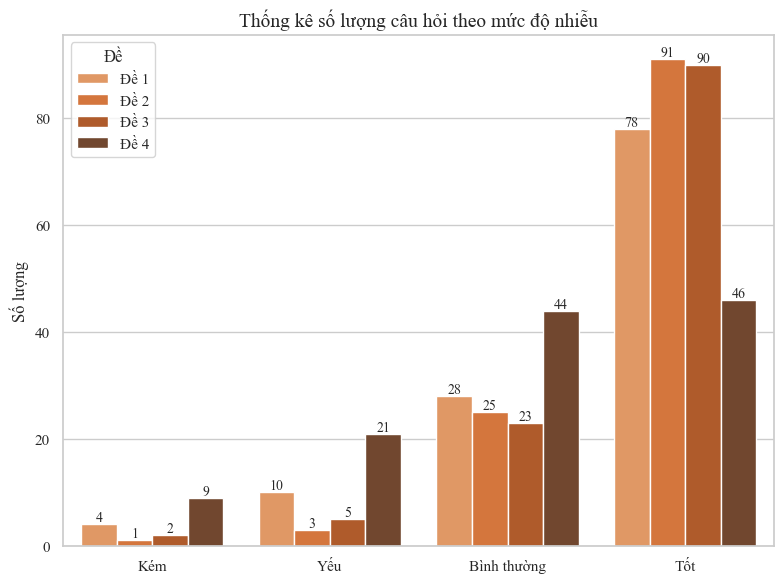

In [ ]:
ip.plot_item(nhieu_1, nhieu_2, nhieu_3, nhieu_4, title='Thống kê số lượng câu hỏi theo mức độ nhiễu', order=order_nhieu, palette='Oranges_d', size=(8,6))

In [42]:
nhieu_1['Phần thi'] = (
    nhieu_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

nhieu_2['Phần thi'] = (
    nhieu_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

nhieu_3['Phần thi'] = (
    nhieu_3.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

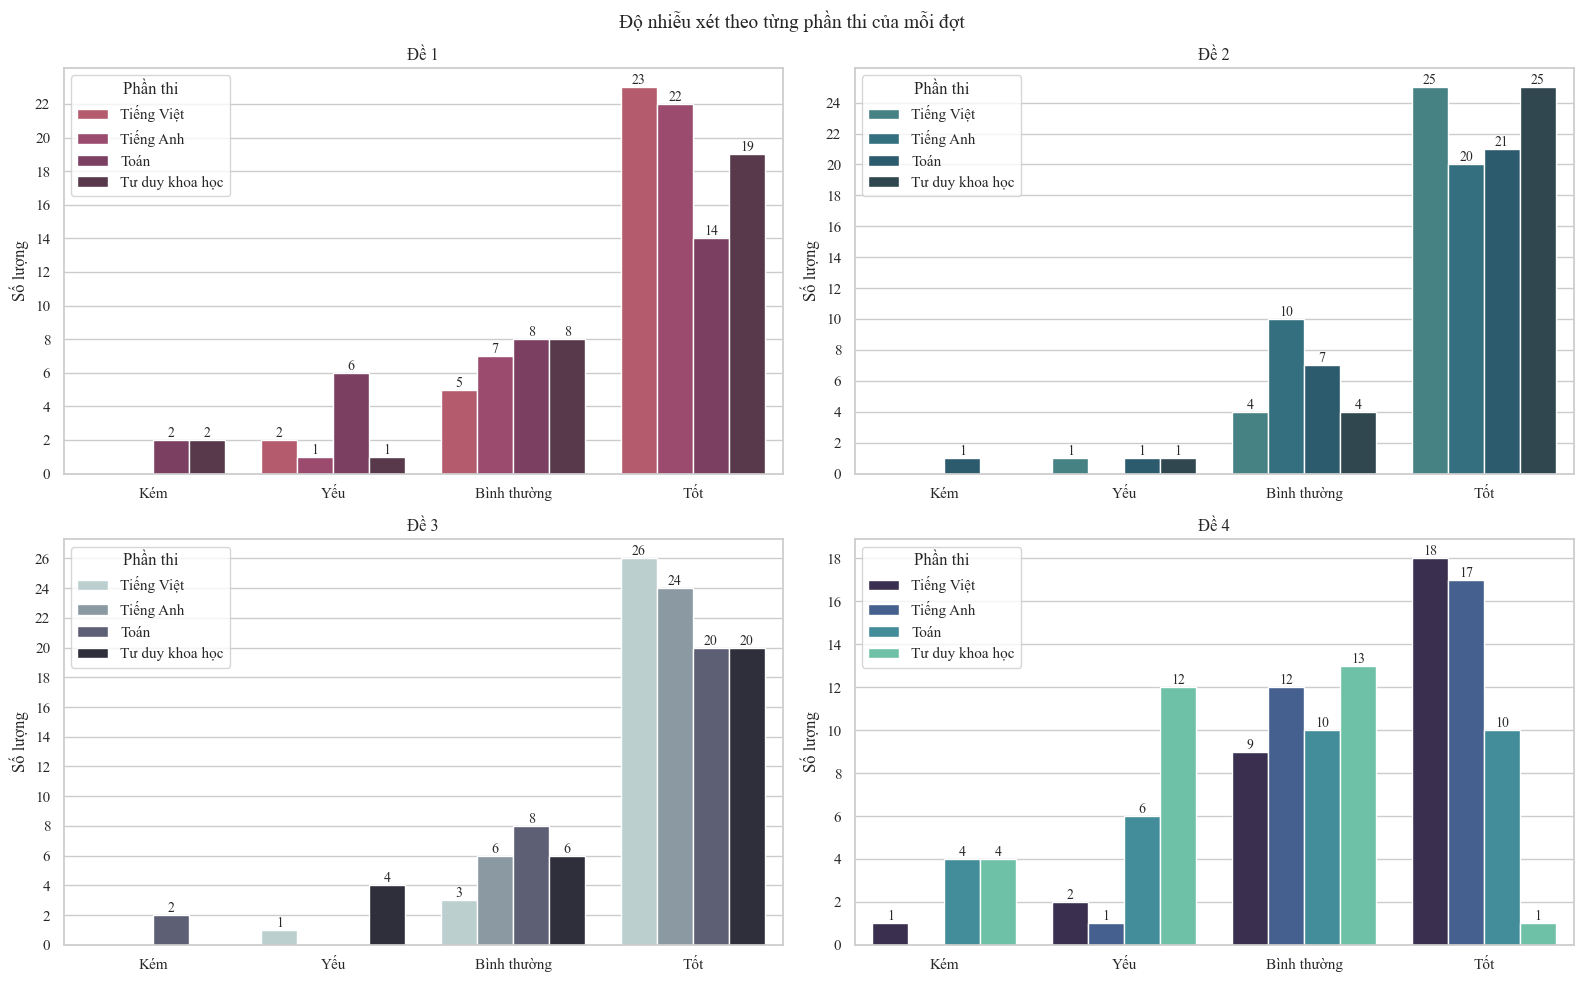

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# =========================
# ĐỀ 1
# =========================
draw_countplot(
    axes[0],
    nhieu_1,
    'flare_d',
    'Đề 1',
    order=order_nhieu
)

# =========================
# ĐỀ 2
# =========================
draw_countplot(
    axes[1],
    nhieu_2,
    'crest_d',
    'Đề 2',
    order=order_nhieu
)

# =========================
# ĐỀ 3
# =========================
draw_countplot(
    axes[2],
    nhieu_3,
    'bone_r',
    'Đề 3',
    order=order_nhieu
)

# =========================
# ĐỀ 4
# =========================
draw_countplot(
    axes[3],
    nhieu_4,
    'mako',
    'Đề 4',
    order=order_nhieu
)

plt.suptitle(
    'Độ nhiễu xét theo từng phần thi của mỗi đợt',
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

In [ ]:
item_ctt_1 = pd.concat([
    diff_1.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_1.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_1.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_2 = pd.concat([
    diff_2.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_2.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_2.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_3 = pd.concat([
    diff_3.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_3.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_3.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_4 = pd.concat([
    diff_4.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_4.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_4.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

In [ ]:
item_ctt_1, item_ctt_2, item_ctt_3, item_ctt_4

(             CTT         Độ khó   D-Index   Độ phân biệt         A         B  \
 Cau1    0.784188             Dễ  0.190476       Chưa tốt -0.090698 -0.077724   
 Cau2    0.882479             Dễ  0.182540       Chưa tốt -0.077654 -0.164355   
 Cau3    0.831197             Dễ  0.015873       Chưa tốt  0.023497  0.010622   
 Cau4    0.121795            Khó  0.063492       Chưa tốt  0.098663  0.055808   
 Cau5    0.314103  Tương đối khó  0.198413       Chưa tốt -0.137573  0.120029   
 ...          ...            ...       ...            ...       ...       ...   
 Cau116  0.263274  Tương đối khó  0.655738            Tốt  0.093254  0.231577   
 Cau117  0.508850    Bình thường  1.032787        Quá tốt -0.146751 -0.147345   
 Cau118  0.165929            Khó  0.557377  Tương đối tốt -0.185613 -0.029800   
 Cau119  0.579646    Bình thường  0.983607        Rất tốt -0.087406  0.508710   
 Cau120  0.422566    Bình thường  0.868852        Rất tốt -0.105607  0.394653   
 
                C         

### Phân tích ma trận nhiệt giữa các yếu tố

In [ ]:
import textwrap

def wrap_labels(ax, width=10):
    ax.set_xticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_xticklabels()]
    )
    ax.set_yticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_yticklabels()]
    )

def heatmap_pair(df, col1, col2, title, cmap, order1=None, order2=None, ax=None):
    if order1 is not None:
        df[col1] = pd.Categorical(df[col1], categories=order1, ordered=True)
    if order2 is not None:
        df[col2] = pd.Categorical(df[col2], categories=order2, ordered=True)

    ct = pd.crosstab(df[col1], df[col2])

    #plt.figure(figsize=(6, 6))
    ax = sns.heatmap(ct, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)

    ax.set_title(title)
    plt.xlabel(col2)
    plt.ylabel(col1)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    # Tự động xuống dòng
    wrap_labels(ax, width=8)

    plt.tight_layout()

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 1')

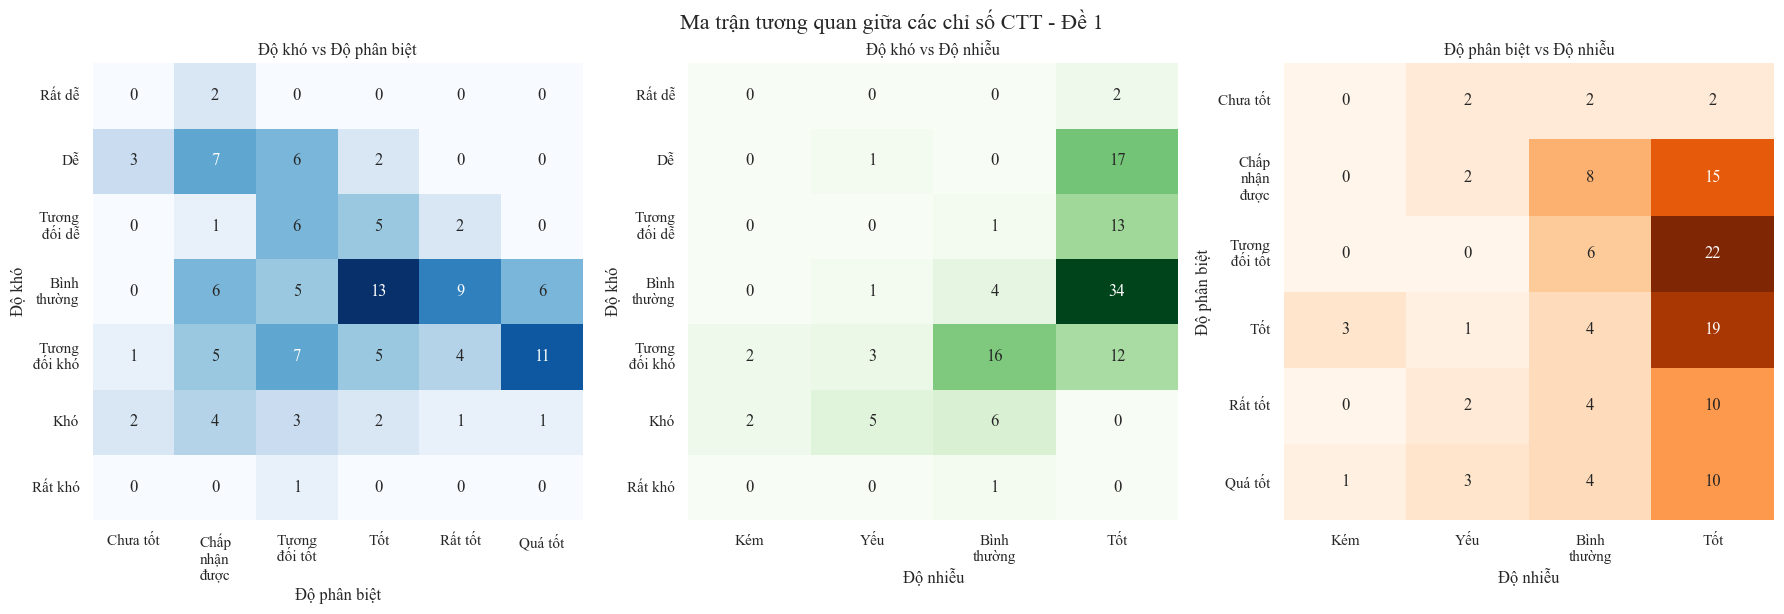

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_1, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_1, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_1, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 1', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 2')

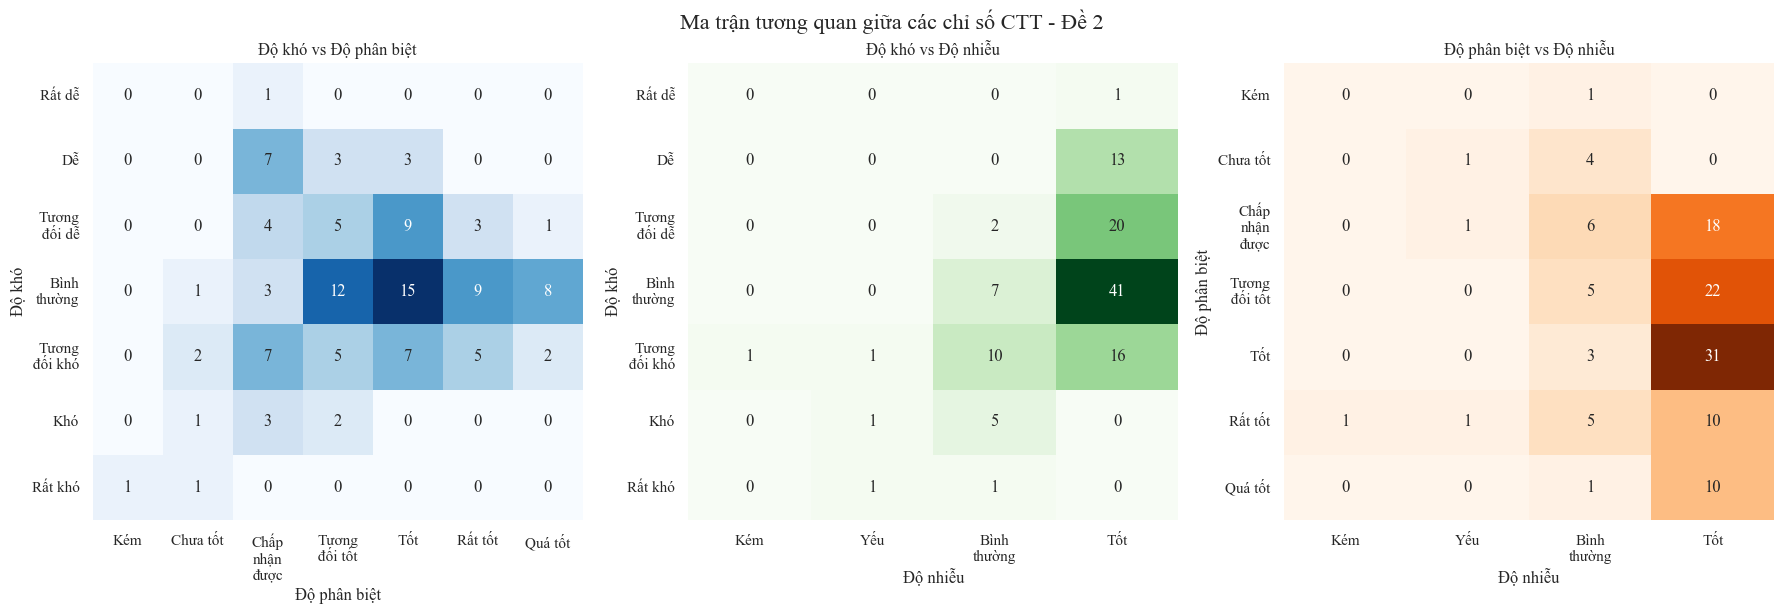

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_2, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_2, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_2, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 2', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 3')

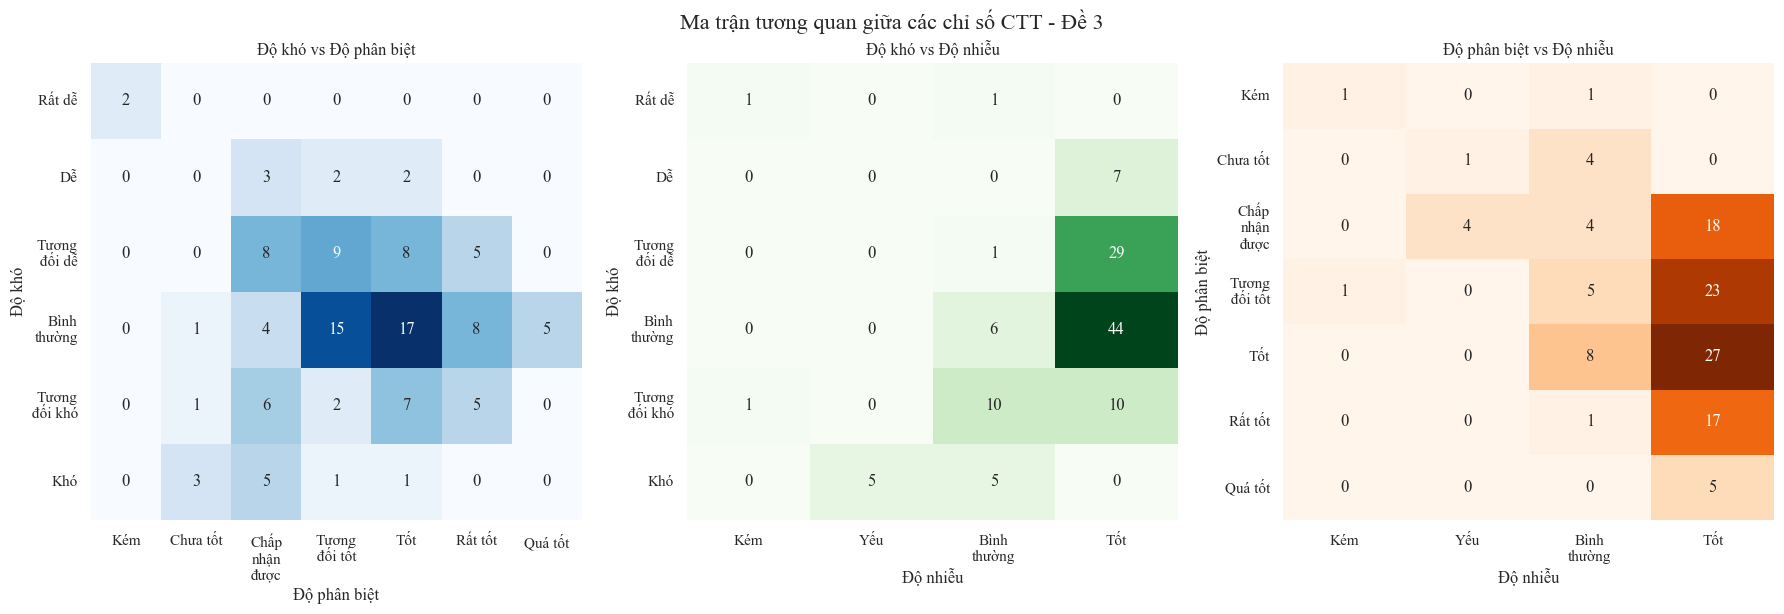

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_3, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_3, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_3, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 3', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 4')

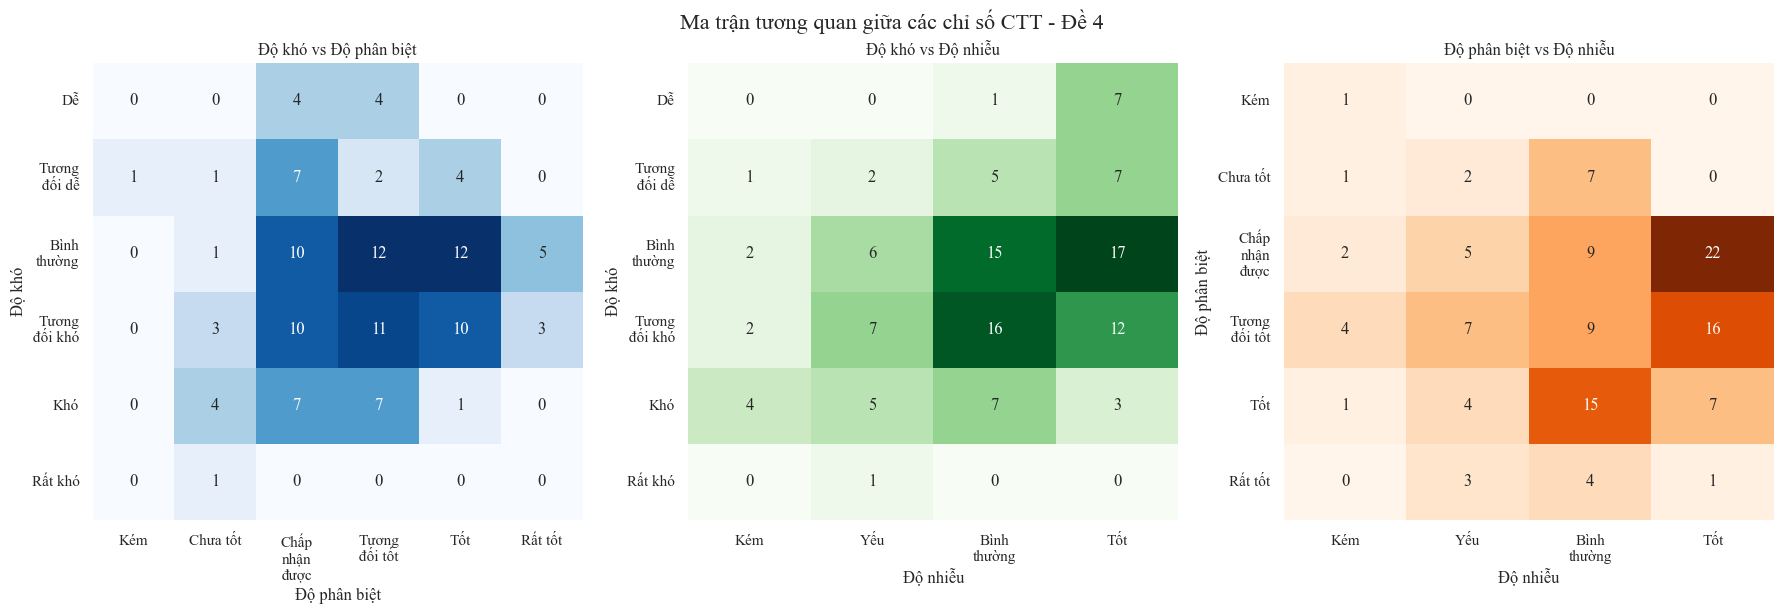

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_4, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_4, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_4, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 4', fontsize=16, y=1.02)

## Phân tích chẩn đoán theo lý thuyết IRT

#### Thực hiện ước lượng tham số a,b

In [43]:
def calc_a_init(
    dfs: list,
    irt,
    min_null: int = 30
):

    import numpy as np
    import pandas as pd

    result = {}

    # =====================================================
    # duyệt từng block
    # =====================================================

    for df in dfs:

        # =================================================
        # lọc thí sinh hợp lệ
        # =================================================

        valid = df[
            df['Null'] < min_null
        ].copy()

        # =================================================
        # std điểm tổng
        # =================================================

        std = valid['Raw'].std()

        # =================================================
        # lấy danh sách câu
        # =================================================

        question_cols = [
            c for c in valid.columns
            if c.startswith('Cau')
        ]

        question_cols = sorted(
            question_cols,
            key=lambda x: int(x.replace('Cau', ''))
        )

        # =================================================
        # tính discrimination
        # =================================================

        for cau_col in question_cols:

            # bỏ câu trống
            item_data = valid[
                valid[cau_col] != -1
            ]

            # không đủ dữ liệu
            if (
                item_data.shape[0] == 0
                or std == 0
                or np.isnan(std)
            ):

                result[cau_col] = np.nan
                continue

            # =============================================
            # corrected total score
            # =============================================

            corrected_total = (
                item_data['Raw']
                - item_data[cau_col]
            )

            # nhóm đúng
            true_group = corrected_total[
                item_data[cau_col] == 1
            ]

            # nhóm sai
            false_group = corrected_total[
                item_data[cau_col] == 0
            ]

            # thiếu dữ liệu
            if (
                true_group.shape[0] == 0
                or false_group.shape[0] == 0
            ):

                result[cau_col] = np.nan
                continue

            # =============================================
            # tỷ lệ đúng
            # =============================================

            p = (
                true_group.shape[0]
                / item_data.shape[0]
            )

            # =============================================
            # PBCC
            # =============================================

            pbcc = ctt.cal_pbcc(
                true_group,
                false_group,
                std,
                p
            )

            # =============================================
            # discrimination
            # =============================================

            try:
                a = ctt.cal_disc(pbcc)
            except:
                a = np.nan

            result[cau_col] = a

    # =====================================================
    # convert thành DataFrame
    # =====================================================

    df_result = pd.DataFrame.from_dict(
        result,
        orient='index',
        columns=['Ans']
    )

    df_result.index.name = 'Cau'

    # sort index
    df_result = df_result.sort_index(
        key=lambda x: x.str.replace('Cau', '').astype(int)
    )

    return df_result

In [44]:
a_init_1 = nhieu_1['Ans'].apply(irt.cal_disc)
a_init_2 = nhieu_2['Ans'].apply(irt.cal_disc)
a_init_3 = nhieu_3['Ans'].apply(irt.cal_disc)
a_init_4  = calc_a_init(
    [df_TV4, df_TA4, df_TO4, df_KH4],
    irt)
b_init_1 = diff_1['CTT'].apply(irt.cal_diff)
b_init_2 = diff_2['CTT'].apply(irt.cal_diff)
b_init_3 = diff_3['CTT'].apply(irt.cal_diff)
b_init_4 = diff_4['CTT'].apply(irt.cal_diff)

In [46]:
def run_irt_series(series_list):
    a_est_all, b_est_all = [], []

    for df_original, end_idx, name in series_list:

        df = df_original.copy()
        valid_mask = (df["Raw"] > 0) & (df["Raw"] < 30)

        # Chỉ lấy dữ liệu hợp lệ để chạy IRT (bỏ qua các trường hợp đúng/sai hết)
        df_valid = df[valid_mask]
        U = df_valid.drop(columns=['SBD', 'MaDe', 'Gioi', 'Raw', 'Null']).to_numpy()

        # a_init = a_init_all.iloc[end_idx-30:end_idx]
        # b_init = b_init_all.iloc[end_idx-30:end_idx]

        # MMLE
        a_est, b_est = irt.mmle(U=U, name=name, max_iter=200)

        # Tính theta cho dữ liệu hợp lệ
        item_params = list(zip(a_est, b_est))
        theta_valid = irt.theta_estimate(U, item_params=item_params)

        # Tạo mảng theta cuối cùng cho toàn bộ học sinh
        theta = np.empty(len(df))

        # Gán theta tính bằng IRT cho nhóm hợp lệ
        theta[valid_mask.to_numpy()] = theta_valid

        # các trường hợp đúng hoặc sai hết
        theta[df["Raw"] == 0] = -6
        theta[df["Raw"] == 30] = 6

        # Gán theta vào DataFrame
        df_original["Theta"] = theta

        a_est_all.extend(a_est)
        b_est_all.extend(b_est)

    return a_est_all, b_est_all


# --- Chạy cho bộ đề 1 ---
series_1 = [[df_TV1, 30, 'TV'], [df_TA1, 60, 'TA'], [df_TO1, 90, 'TO'], [df_KH1, 120, 'KH']]
a_est_1, b_est_1 = run_irt_series(series_1)

# --- Chạy cho bộ đề 2 ---
series_2 = [[df_TV2, 30, 'TV'], [df_TA2, 60, 'TA'], [df_TO2, 90, 'TO'], [df_KH2, 120, 'KH']]
a_est_2, b_est_2 = run_irt_series(series_2)

# --- Chạy cho bộ đề 3 ---
series_3 = [[df_TV3, 30, 'TV'], [df_TA3, 60, 'TA'], [df_TO3, 90, 'TO'], [df_KH3, 120, 'KH']]
a_est_3, b_est_3 = run_irt_series(series_3)


Start TV: N=468, J=30, K=81
Iter 1: LL = -9697.12
Iter 2: LL = -8882.13
Iter 3: LL = -8351.71
Iter 4: LL = -8044.76
Iter 5: LL = -7898.36
Iter 6: LL = -7845.46
Iter 7: LL = -7818.86
Iter 8: LL = -7804.19
Iter 9: LL = -7804.19
Iter 10: LL = -7784.82
Iter 11: LL = -7774.94
Iter 12: LL = -7769.92
Iter 13: LL = -7761.94
Iter 14: LL = -7761.94
Iter 15: LL = -7756.77
Iter 16: LL = -7748.93
Iter 17: LL = -7747.51
Iter 18: LL = -7741.34
Iter 19: LL = -7740.72
Iter 20: LL = -7734.08
Iter 21: LL = -7734.08
Iter 22: LL = -7731.22
Iter 23: LL = -7726.68
Iter 24: LL = -7723.00
Iter 25: LL = -7718.93
Iter 26: LL = -7715.68
Iter 27: LL = -7711.85
Iter 28: LL = -7708.92
Iter 29: LL = -7705.25
Iter 30: LL = -7702.56
Iter 31: LL = -7699.06
Iter 32: LL = -7696.60
Iter 33: LL = -7693.23
Iter 34: LL = -7691.02
Iter 35: LL = -7687.81
Iter 36: LL = -7685.88
Iter 37: LL = -7682.77
Iter 38: LL = -7681.07
Iter 39: LL = -7678.09
Iter 40: LL = -7676.62
Iter 41: LL = -7673.80
Iter 42: LL = -7672.54
Iter 43: LL = -

In [47]:
# --- Chạy cho bộ đề 4 ---
series_4 = [[df_TV4, 30, 'TV'], [df_TA4, 60, 'TA'], [df_TO4, 90, 'TO'], [df_KH4, 120, 'KH']]
a_est_4, b_est_4 = run_irt_series(series_4)

Start TV: N=1147, J=30, K=81
Iter 1: LL = -24522.86
Iter 2: LL = -22664.35
Iter 3: LL = -21440.64
Iter 4: LL = -20608.71
Iter 5: LL = -20071.54
Iter 6: LL = -19770.73
Iter 7: LL = -19610.09
Iter 8: LL = -19561.34
Iter 9: LL = -19527.52
Iter 10: LL = -19517.94
Iter 11: LL = -19506.91
Iter 12: LL = -19506.91
Iter 13: LL = -19455.48
Iter 14: LL = -19448.12
Iter 15: LL = -19441.38
Iter 16: LL = -19435.97
Iter 17: LL = -19426.43
Iter 18: LL = -19423.00
Iter 19: LL = -19415.09
Iter 20: LL = -19415.09
Iter 21: LL = -19397.32
Iter 22: LL = -19383.37
Iter 23: LL = -19383.37
Iter 24: LL = -19380.11
Iter 25: LL = -19370.83
Iter 26: LL = -19368.52
Iter 27: LL = -19359.98
Iter 28: LL = -19358.18
Iter 29: LL = -19349.62
Iter 30: LL = -19348.04
Iter 31: LL = -19339.75
Iter 32: LL = -19338.10
Iter 33: LL = -19330.24
Iter 34: LL = -19328.86
Iter 35: LL = -19321.24
Iter 36: LL = -19319.86
Iter 37: LL = -19312.51
Iter 38: LL = -19311.12
Iter 39: LL = -19303.83
Iter 40: LL = -19302.30
Iter 41: LL = -19295

In [48]:
item_irt_1 = pd.DataFrame({
    'a': a_est_1,
    'b': b_est_1}, index=nhieu_1.index)
item_irt_2 = pd.DataFrame({
    'a': a_est_2,
    'b': b_est_2}, index=nhieu_1.index)
item_irt_3 = pd.DataFrame({
    'a': a_est_3,
    'b': b_est_3}, index=nhieu_1.index)
item_irt_4 = pd.DataFrame({
    'a': a_est_4,
    'b': b_est_4}, index=nhieu_1.index)

In [49]:
item_irt_1, item_irt_2, item_irt_3, item_irt_4

(               a         b
 Cau1    0.531901 -1.421533
 Cau2    0.877528 -1.550606
 Cau3    0.594955 -1.529341
 Cau4    0.670061  1.805557
 Cau5    0.280515  1.518544
 ...          ...       ...
 Cau116  0.233096  1.554217
 Cau117  0.870304 -0.443803
 Cau118  0.513808  1.644836
 Cau119  0.698612 -0.818528
 Cau120  0.500889 -0.048409
 
 [120 rows x 2 columns],
                a         b
 Cau1    0.511801  0.189429
 Cau2    0.363164 -0.799828
 Cau3    0.336583 -1.345792
 Cau4    0.532582  1.594404
 Cau5    0.376872  0.652713
 ...          ...       ...
 Cau116  0.426564 -0.119647
 Cau117  0.309782 -0.133687
 Cau118  0.875636 -0.633173
 Cau119  0.837224 -0.131001
 Cau120  0.538299  0.305089
 
 [120 rows x 2 columns],
                a         b
 Cau1    0.725002 -1.621773
 Cau2    0.274221 -0.934116
 Cau3    0.485036 -1.409711
 Cau4    0.221782  0.294281
 Cau5    0.548183 -1.228427
 ...          ...       ...
 Cau116  0.481481 -0.516420
 Cau117  0.753378 -1.025841
 Cau118  0.497144 -1.0

#### Tính toán điểm thực ở mỗi đề

In [50]:
def cal_true_score(series_list, item_irt):
    cau_cols = series_list.columns[series_list.columns.str.contains("^Cau", regex=True)]

    series_list["True"] = series_list.apply(
        lambda row: irt.true_score(
            theta=row["Theta"],
            raw=row['Raw'],
            data=row[cau_cols],
            item_params=item_irt.loc[cau_cols]  # lấy đúng parameters theo câu
        ),
        axis=1
    )

In [51]:
for df_list in [df_TV1, df_TA1, df_TO1, df_KH1]:
    cal_true_score(df_list, item_irt_1)


In [52]:
for df_list in [df_TV2, df_TA2, df_TO2, df_KH2]:
    cal_true_score(df_list, item_irt_2)



In [53]:
for df_list in [df_TV3, df_TA3, df_TO3, df_KH3]:
    cal_true_score(df_list, item_irt_3)

In [54]:
for df_list in [df_TV4, df_TA4, df_TO4, df_KH4]:
    cal_true_score(df_list, item_irt_4)

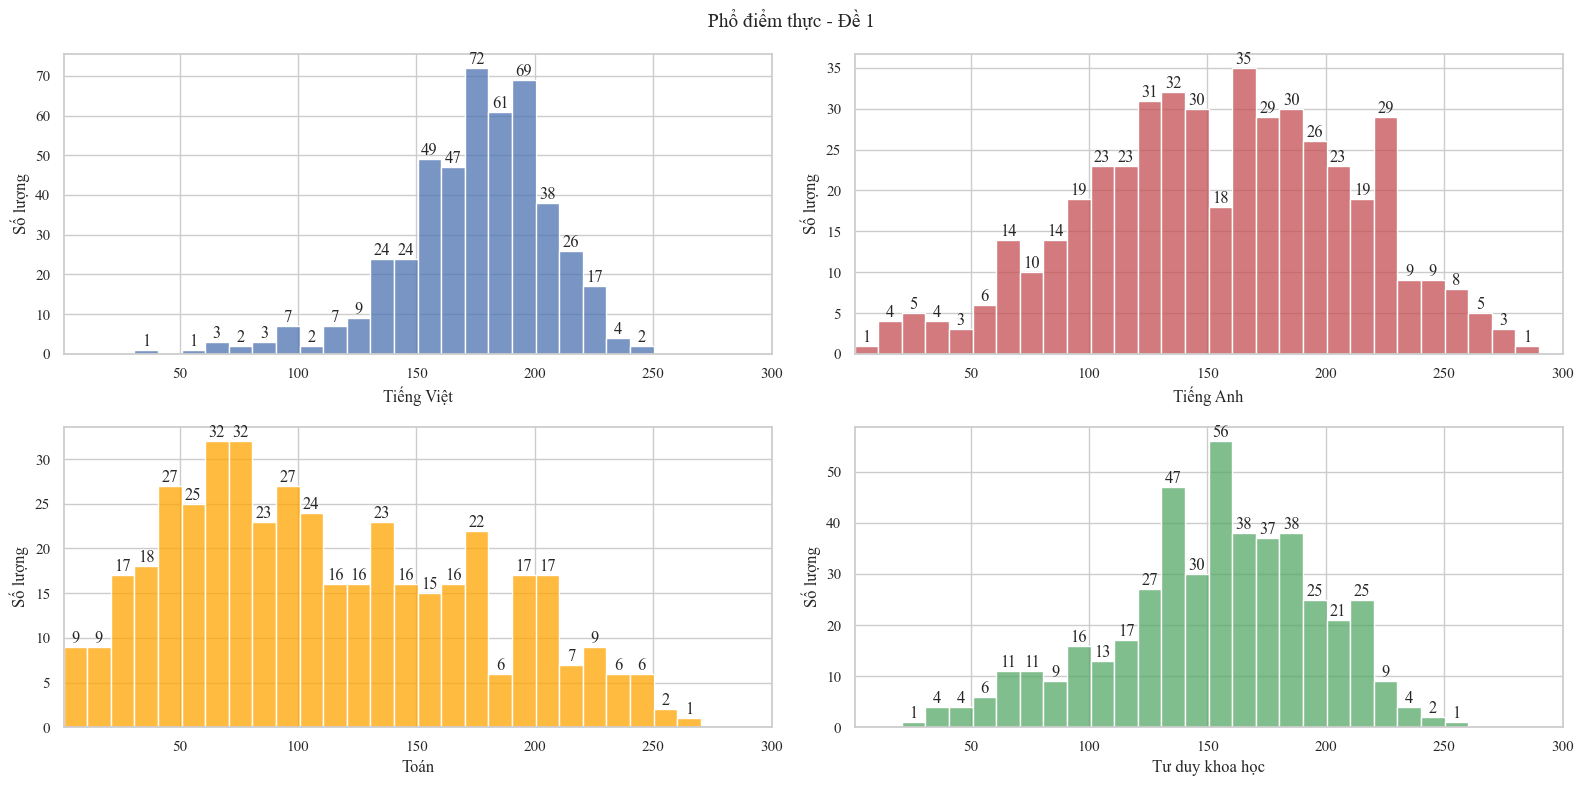

In [55]:
df_true_1 = df_TV1[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_1 = df_true_1.merge(df_TA1[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_1 = df_true_1.merge(df_TO1[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_1 = df_true_1.merge(df_KH1[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_1, col_name='True', title='Phổ điểm thực - Đề 1', range=(1,300))

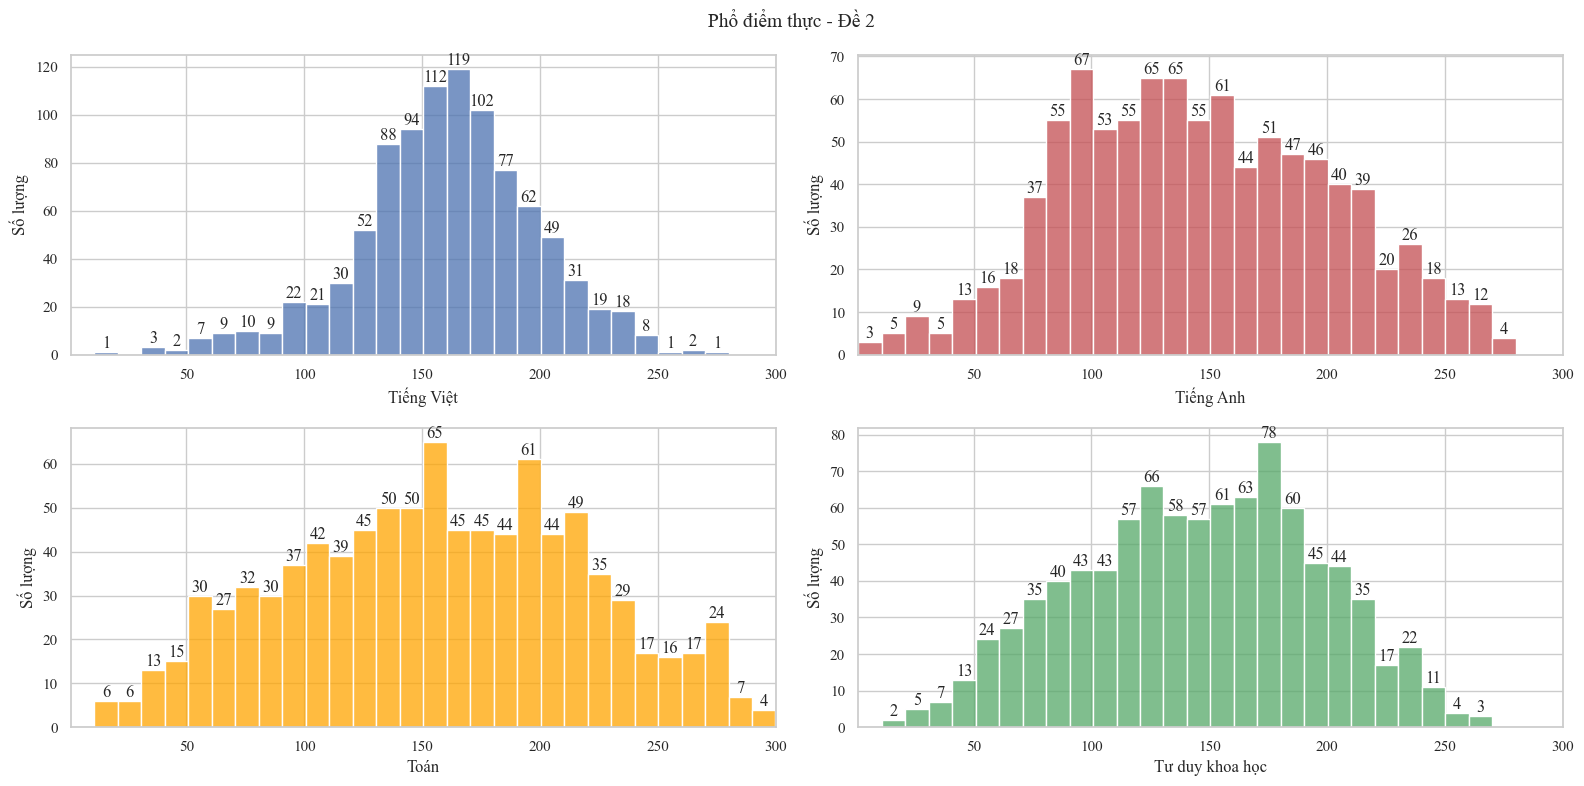

In [56]:
df_true_2 = df_TV2[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_2 = df_true_2.merge(df_TA2[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_2 = df_true_2.merge(df_TO2[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_2 = df_true_2.merge(df_KH2[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_2, col_name='True', title='Phổ điểm thực - Đề 2', range=(1,300))

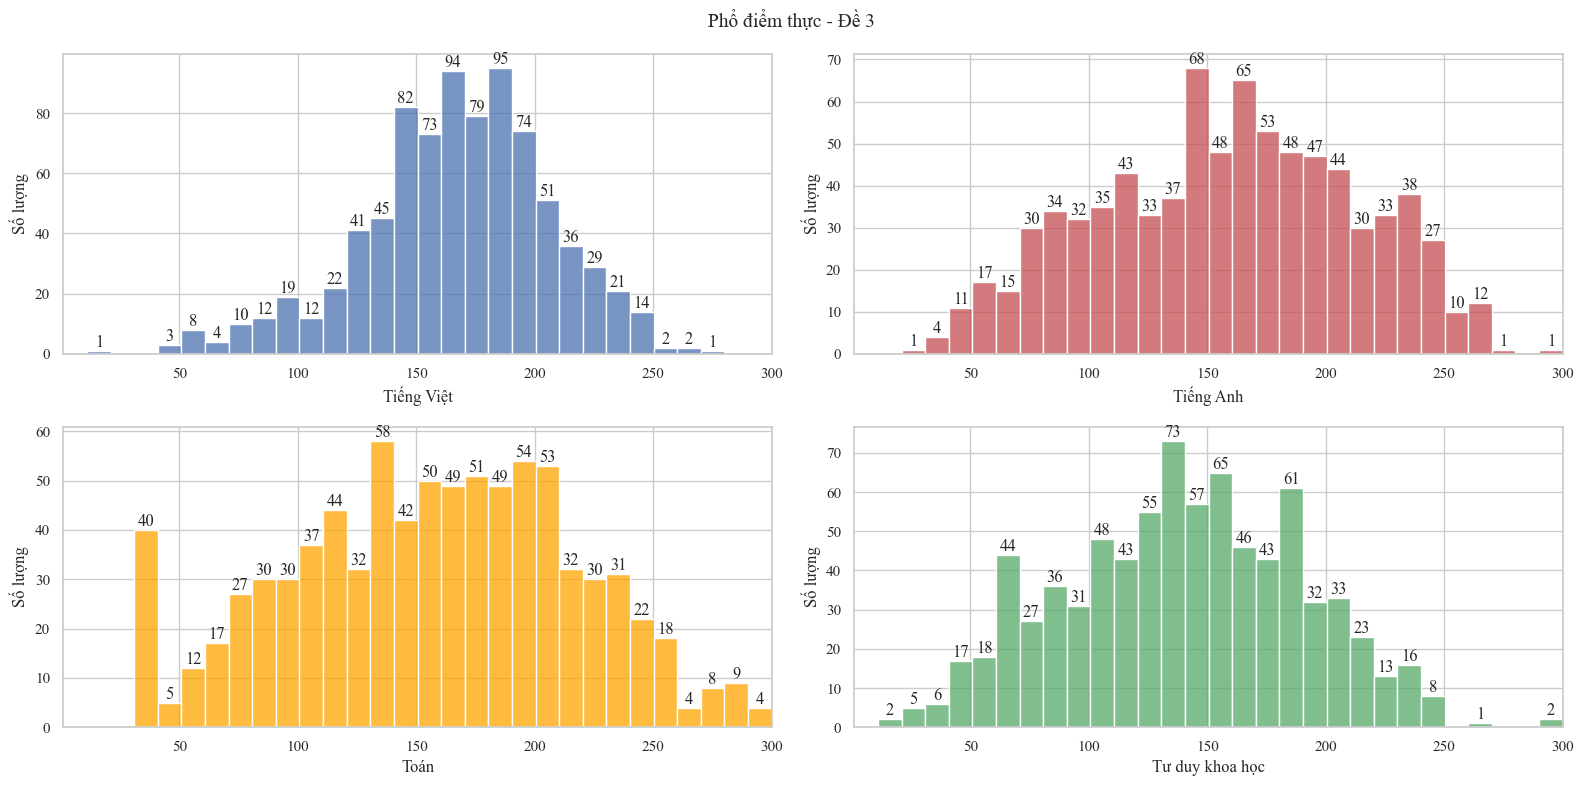

In [57]:
df_true_3 = df_TV3[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_3 = df_true_3.merge(df_TA3[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_3 = df_true_3.merge(df_TO3[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_3 = df_true_3.merge(df_KH3[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_3, col_name='True', title='Phổ điểm thực - Đề 3', range=(1,300))

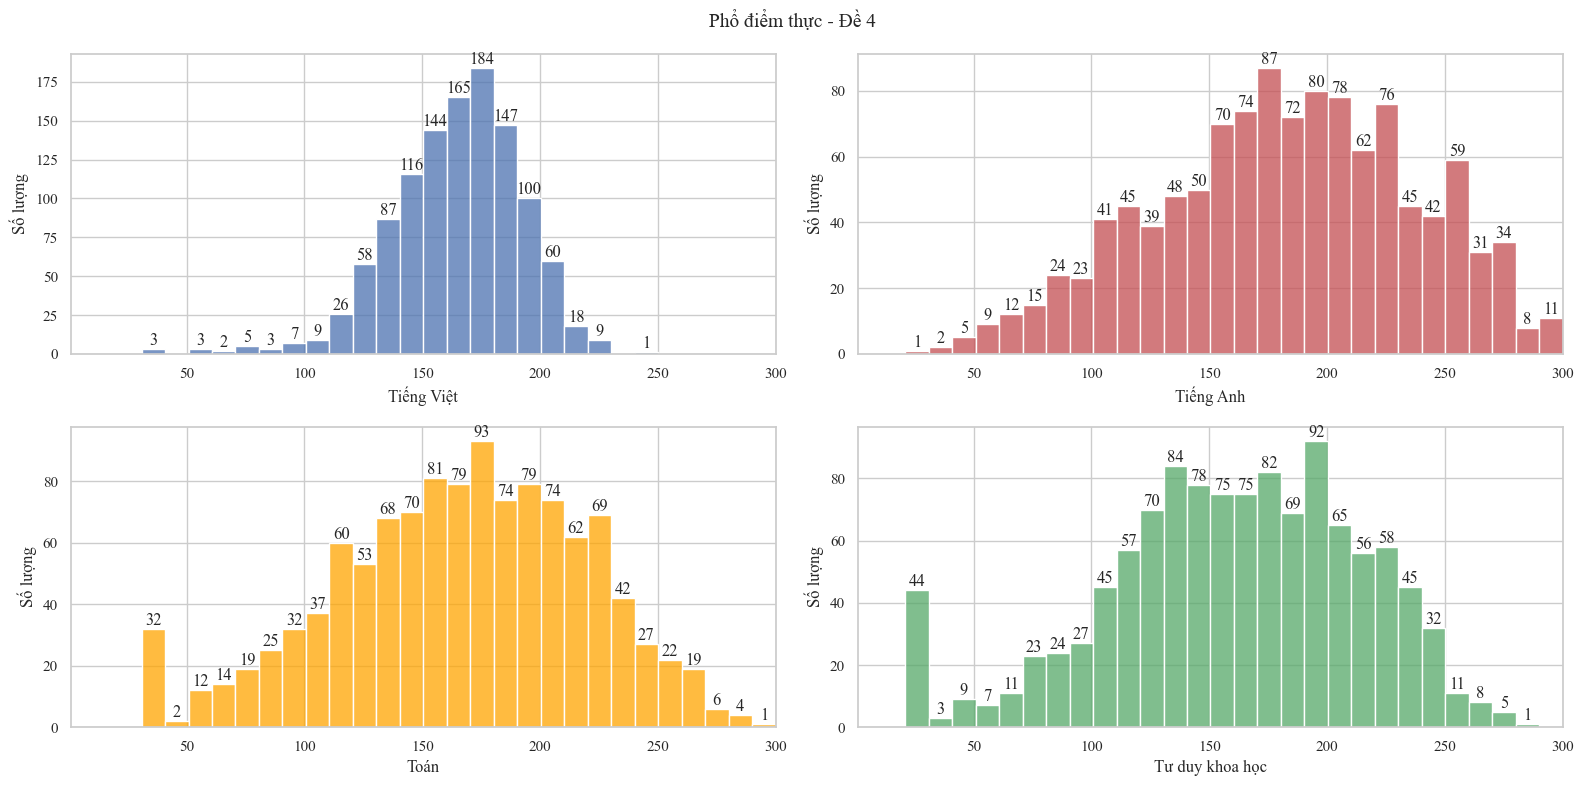

In [58]:
df_true_4 = df_TV4[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_4 = df_true_4.merge(df_TA4[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_4 = df_true_4.merge(df_TO4[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_4 = df_true_4.merge(df_KH4[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_4, col_name='True', title='Phổ điểm thực - Đề 4', range=(1,300))

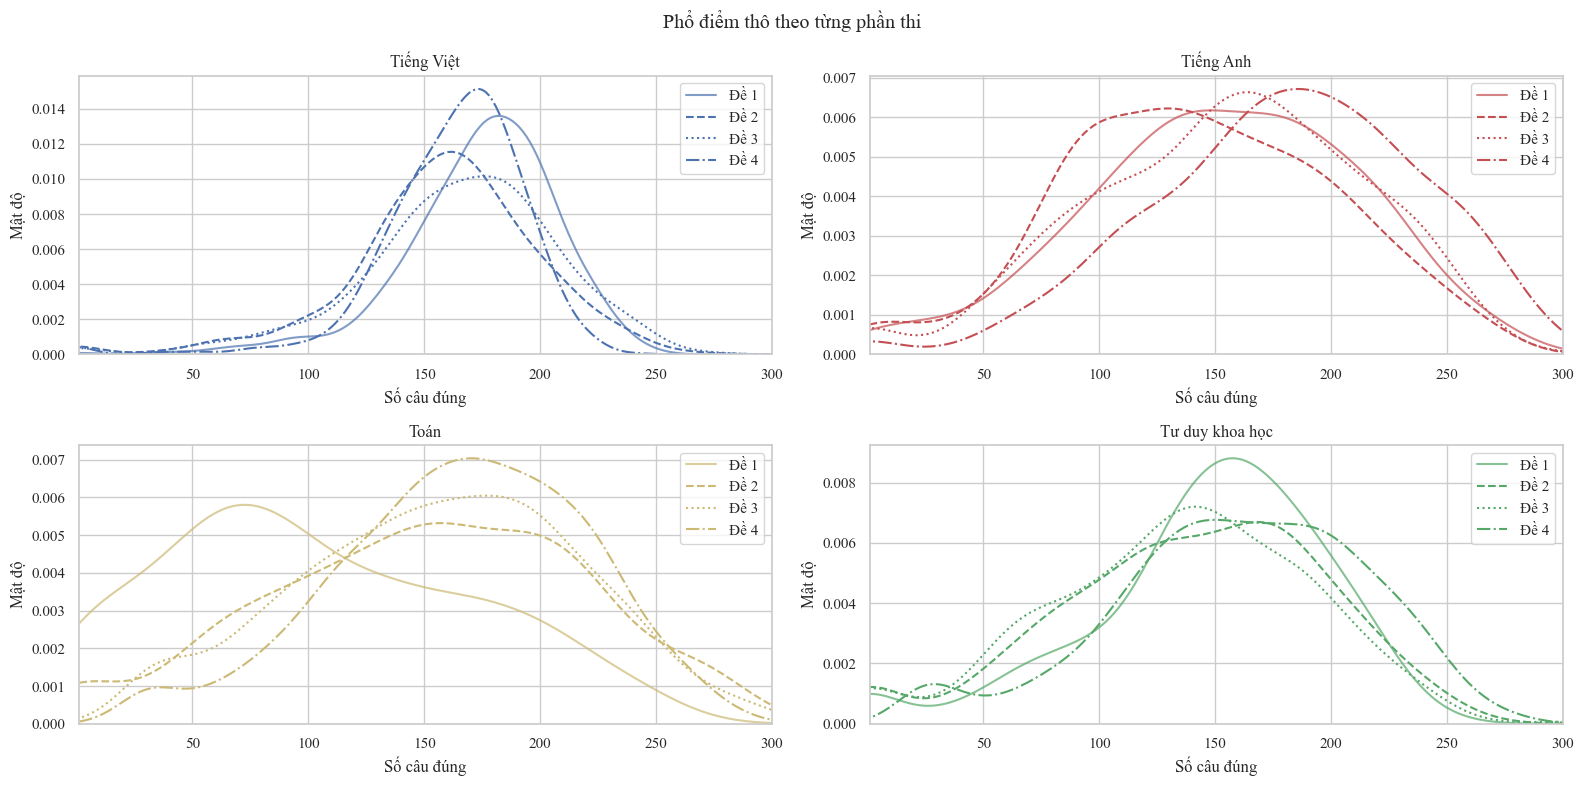

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

def plot_kde_thuc(ax, de_1, de_2, de_3, de_4, title, color):
        sns.kdeplot(
            x=de_1,
            color=color, fill=False, alpha=0.7, label="Đề 1", ax=ax
        )
        sns.kdeplot(
            x=de_2,
            color=color, fill=False, alpha=1.0, linestyle="--", label="Đề 2", ax=ax
        )
        sns.kdeplot(
            x=de_3,
            color=color, fill=False, alpha=1.0, linestyle=":", label="Đề 3", ax=ax
        )
        sns.kdeplot(
            x=de_4,
            color=color, fill=False, alpha=1.0, linestyle="-.", label="Đề 4", ax=ax
        )
        ax.set_xlabel('Số câu đúng')
        ax.set_xlim(1, 300)
        ax.set_ylabel("Mật độ")
        ax.set_title(f"{title}")
        ax.legend()

plot_kde_thuc(axes[0], df_true_1['TrueTV'], df_true_2['TrueTV'], df_true_3['TrueTV'], df_true_4['TrueTV'], "Tiếng Việt", color='b')
plot_kde_thuc(axes[1], df_true_1['TrueTA'], df_true_2['TrueTA'], df_true_3['TrueTA'], df_true_4['TrueTA'], "Tiếng Anh", color='r')
plot_kde_thuc(axes[2], df_true_1['TrueTO'], df_true_2['TrueTO'], df_true_3['TrueTO'], df_true_4['TrueTO'], "Toán", color='y')
plot_kde_thuc(axes[3], df_true_1['TrueKH'], df_true_2['TrueKH'], df_true_3['TrueKH'], df_true_4['TrueKH'], "Tư duy khoa học", color='g')

plt.suptitle('Phổ điểm thô theo từng phần thi', y=0.98)
plt.tight_layout()
plt.show()


In [60]:
cols = ['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']

desc = {}
for c in cols:
    desc[c] = df_true_1.loc[df_true_1[c] != 0, c].describe()

pd.DataFrame(desc)

,TrueTV,TrueTA,TrueTO,TrueKH
count,468.000000,463.000000,438.000000,452.000000
mean,174.944444,154.799136,111.301370,152.380531
std,32.108374,56.473614,62.371703,43.746056
min,36.000000,7.000000,8.000000,25.000000
25%,158.000000,117.000000,62.000000,128.000000
50%,178.500000,158.000000,100.500000,156.000000
75%,196.250000,197.000000,160.000000,183.000000
max,246.000000,281.000000,261.000000,253.000000


In [61]:
desc = {}
for c in cols:
    desc[c] = df_true_2.loc[df_true_2[c] != 0, c].describe()

pd.DataFrame(desc)

,TrueTV,TrueTA,TrueTO,TrueKH
count,949.000000,942.000000,924.000000,920.000000
mean,160.451001,145.205945,156.308442,145.104348
std,37.720840,55.619934,63.004885,50.871983
min,18.000000,8.000000,11.000000,19.000000
25%,139.000000,102.000000,108.750000,107.000000
50%,162.000000,142.000000,158.000000,148.000000
75%,184.000000,186.750000,203.000000,183.000000
max,278.000000,278.000000,300.000000,268.000000


In [62]:
desc = {}
for c in cols:
    desc[c] = df_true_3.loc[df_true_3[c] != 0, c].describe()

pd.DataFrame(desc)

,TrueTV,TrueTA,TrueTO,TrueKH
count,830.000000,817.000000,838.000000,805.000000
mean,167.145783,157.966952,156.374702,139.525466
std,39.957265,54.629906,60.247264,50.579069
min,17.000000,27.000000,33.000000,11.000000
25%,144.000000,116.000000,113.000000,103.000000
50%,170.000000,161.000000,159.500000,140.000000
75%,194.000000,198.000000,201.000000,178.000000
max,275.000000,300.000000,300.000000,300.000000


In [63]:
desc = {}
for c in cols:
    desc[c] = df_true_4.loc[df_true_4[c] != 0, c].describe()

pd.DataFrame(desc)

,TrueTV,TrueTA,TrueTO,TrueKH
count,1147.000000,1143.000000,1156.000000,1156.000000
mean,164.760244,182.196850,165.688581,159.890138
std,27.416652,55.055749,53.741419,54.546418
min,34.000000,21.000000,31.000000,26.000000
25%,148.000000,144.500000,131.000000,126.000000
50%,168.000000,185.000000,169.000000,163.000000
75%,183.000000,222.000000,205.000000,200.000000
max,242.000000,300.000000,291.000000,282.000000


In [64]:
df_true_1['Total_True'] = df_true_1[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)
df_true_2['Total_True'] = df_true_2[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)
df_true_3['Total_True'] = df_true_3[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)
df_true_4['Total_True'] = df_true_4[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)

In [65]:
def plot_total_with_stats(df_true, title, color):
    total = df_true.shape[0]
    max = df_true['Total_True'].max()
    min = df_true['Total_True'].min()
    mean = df_true['Total_True'].mean()
    std = df_true['Total_True'].std()
    median = df_true['Total_True'].median()

    ip.plot_total(
        df_true['Total_True'],
        title=title,
        range=(1,1200),
        color=color,
        xlabel='Điểm thực',
        ylabel='Số lượng',
        lim=(0, 1200)
    )
    stats_text = f"Tổng số thí sinh dự thi: {total}\nCao nhất: {max}\nThấp nhất: {min:.0f}\nTrung bình: {np.round(mean,2)}\nTrung vị: {np.round(median,2)}\nĐộ lệch chuẩn: {np.round(std,2)}"
    # Thêm một mục "giả" vào legend để hiển thị chú thích kết quả thống kê
    plt.plot([], ' ', label=stats_text)
    plt.legend(loc='upper left', fontsize=12)


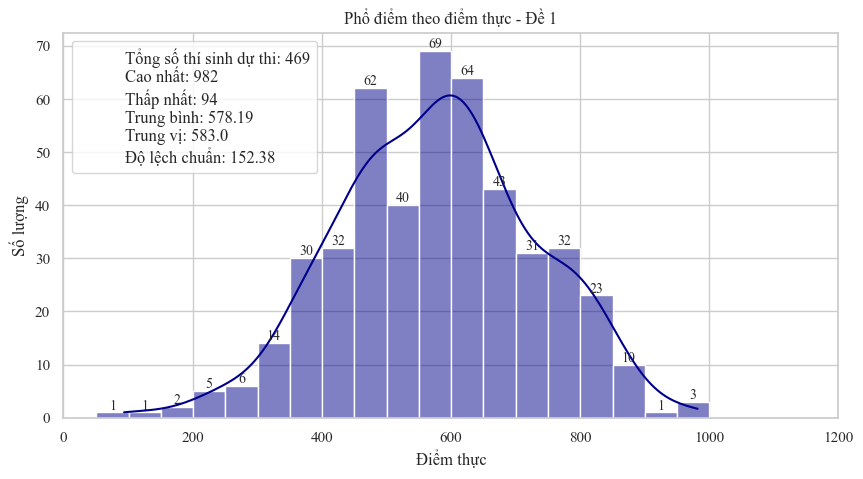

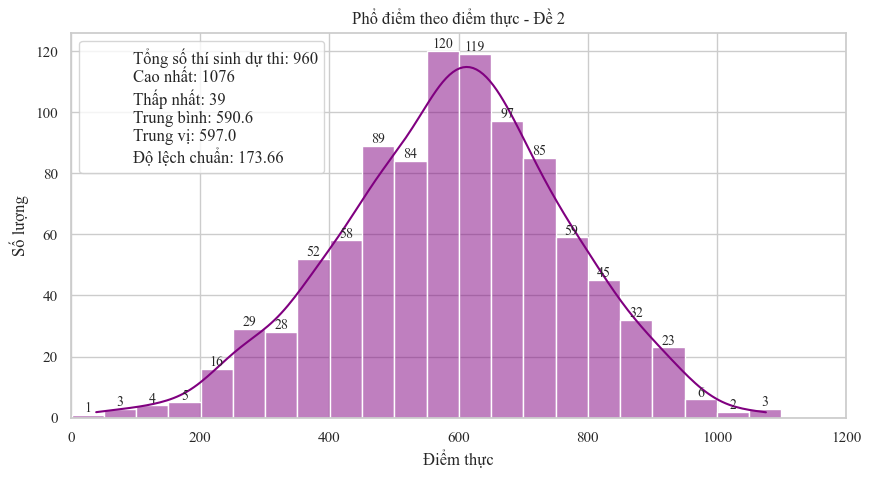

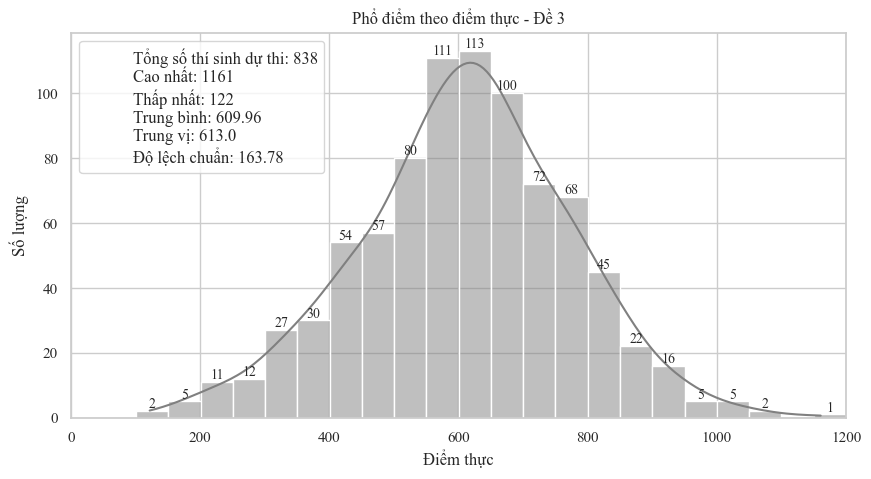

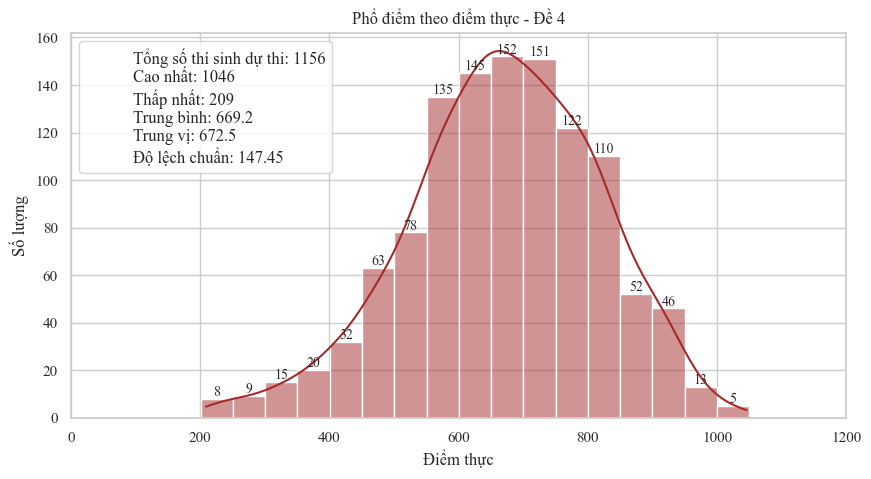

In [66]:
plot_total_with_stats(df_true_1, title='Phổ điểm theo điểm thực - Đề 1', color='darkblue')
plot_total_with_stats(df_true_2, title='Phổ điểm theo điểm thực - Đề 2', color='purple')
plot_total_with_stats(df_true_3, title='Phổ điểm theo điểm thực - Đề 3', color='grey')
plot_total_with_stats(df_true_4, title='Phổ điểm theo điểm thực - Đề 4', color='brown')

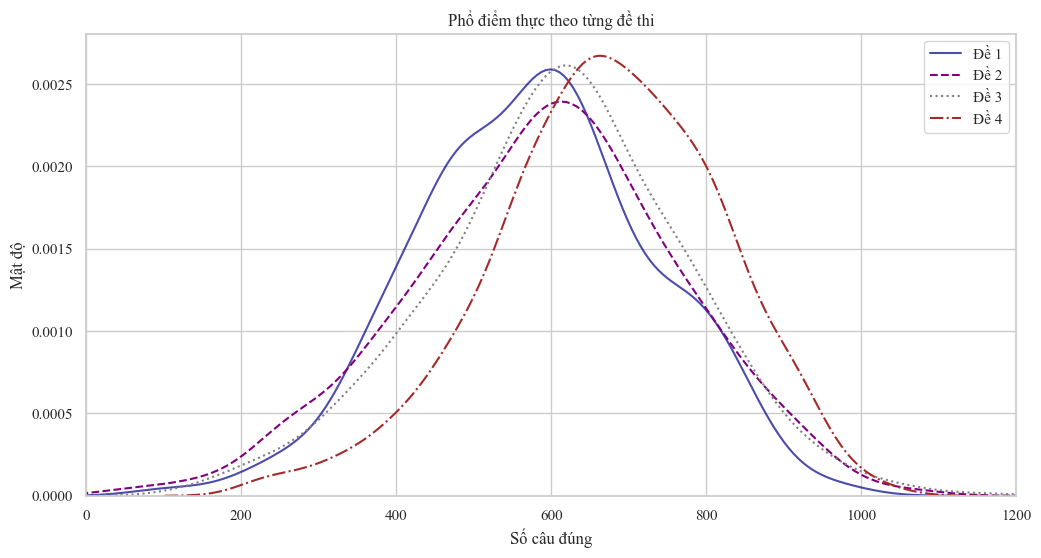

In [67]:
plt.figure(figsize=(12, 6))
sns.kdeplot(x=df_true_1['Total_True'],color='darkblue', fill=False, alpha=0.7, label="Đề 1")
sns.kdeplot(x=df_true_2['Total_True'],color='purple', fill=False, alpha=1.0, linestyle="--", label="Đề 2")
sns.kdeplot(x=df_true_3['Total_True'],color='gray', fill=False, alpha=1.0, linestyle=":", label="Đề 3")
sns.kdeplot(x=df_true_4['Total_True'],color='brown', fill=False, alpha=1.0, linestyle="-.", label="Đề 4")
plt.xlabel('Số câu đúng')
plt.ylabel("Mật độ")
plt.title("Phổ điểm thực theo từng đề thi")
plt.xlim(0,1200)
plt.legend()
plt.show()

In [ ]:
true_total_1 = df_true_1[['SBD', 'Total_True']].merge(df_dot1[['SBD', 'Gioi', 'Email']], left_on='SBD', right_on='SBD')
true_total_2 = df_true_2[['SBD', 'Total_True']].merge(df_dot2[['SBD', 'Gioi', 'Email']], left_on='SBD', right_on='SBD')
true_total_3 = df_true_3[['SBD', 'Total_True']].merge(df_dot3[['SBD', 'Gioi', 'Email']], left_on='SBD', right_on='SBD')
true_total_4 = df_true_4[['SBD', 'Total_True']].merge(df_dot4[['SBD', 'Gioi', 'Email']], left_on='SBD', right_on='SBD')

In [ ]:
true_total_4 = df_true_4.merge(df_dot4[['SBD', 'Gioi', 'Email']], left_on='SBD', right_on='SBD')

In [ ]:
true_total_4.to_excel('kq_dot4.xlsx', index=False)

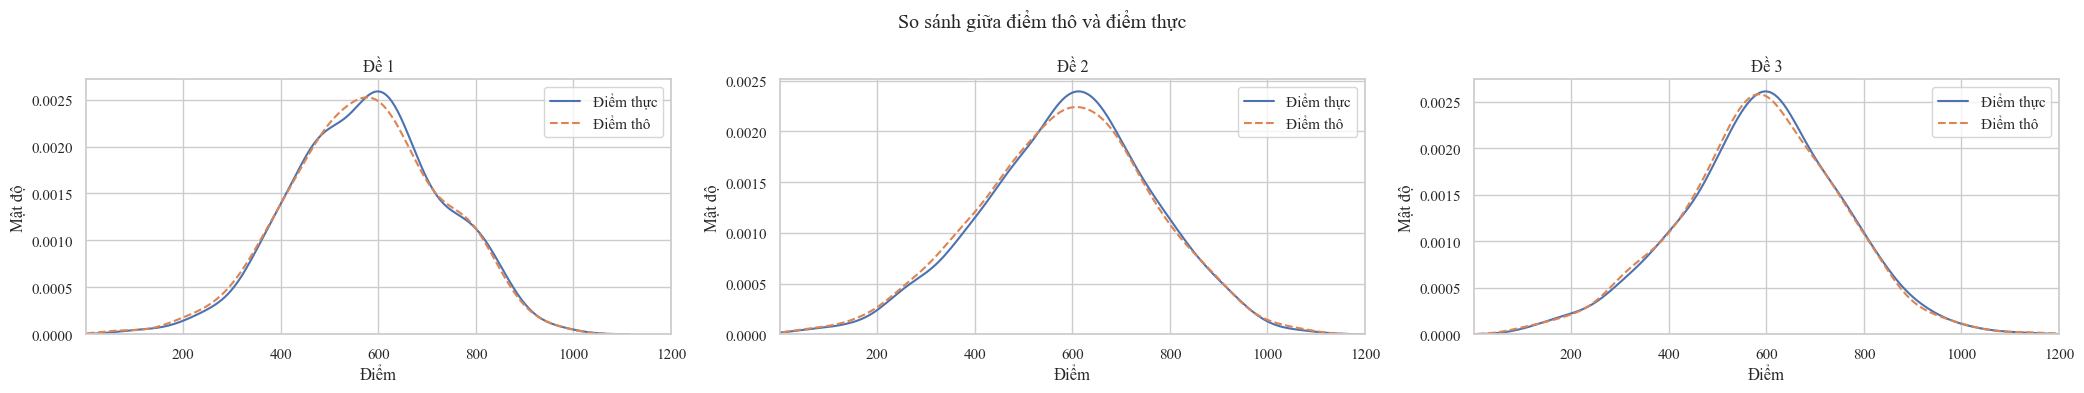

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# =========================
# HÀM KDE CHUNG
# =========================
def draw_score_kde(ax, true_total, raw_total, title):
    sns.kdeplot(
        data=true_total,
        x='Total_True',
        ax=ax,
        label='Điểm thực'
    )

    sns.kdeplot(
        raw_total * 10,
        linestyle='--',
        ax=ax,
        label='Điểm thô'
    )

    ax.set_xlim(1, 1200)
    ax.set_title(title)
    ax.set_xlabel('Điểm')
    ax.set_ylabel('Mật độ')
    ax.legend()


# =========================
# ĐỀ 1
# =========================
draw_score_kde(
    axes[0],
    true_total_1,
    rawtotal_1,
    'Đề 1'
)

# =========================
# ĐỀ 2
# =========================
draw_score_kde(
    axes[1],
    true_total_2,
    rawtotal_2,
    'Đề 2'
)

# =========================
# ĐỀ 3
# =========================
draw_score_kde(
    axes[2],
    true_total_3,
    rawtotal_3,
    'Đề 3'
)

# =========================
# ĐỀ 4
# =========================
draw_score_kde(
    axes[3],
    true_total_4,
    rawtotal_4,
    'Đề 4'
)

plt.suptitle(
    'So sánh giữa điểm thô và điểm thực',
    y=0.98
)

plt.tight_layout()
plt.show()

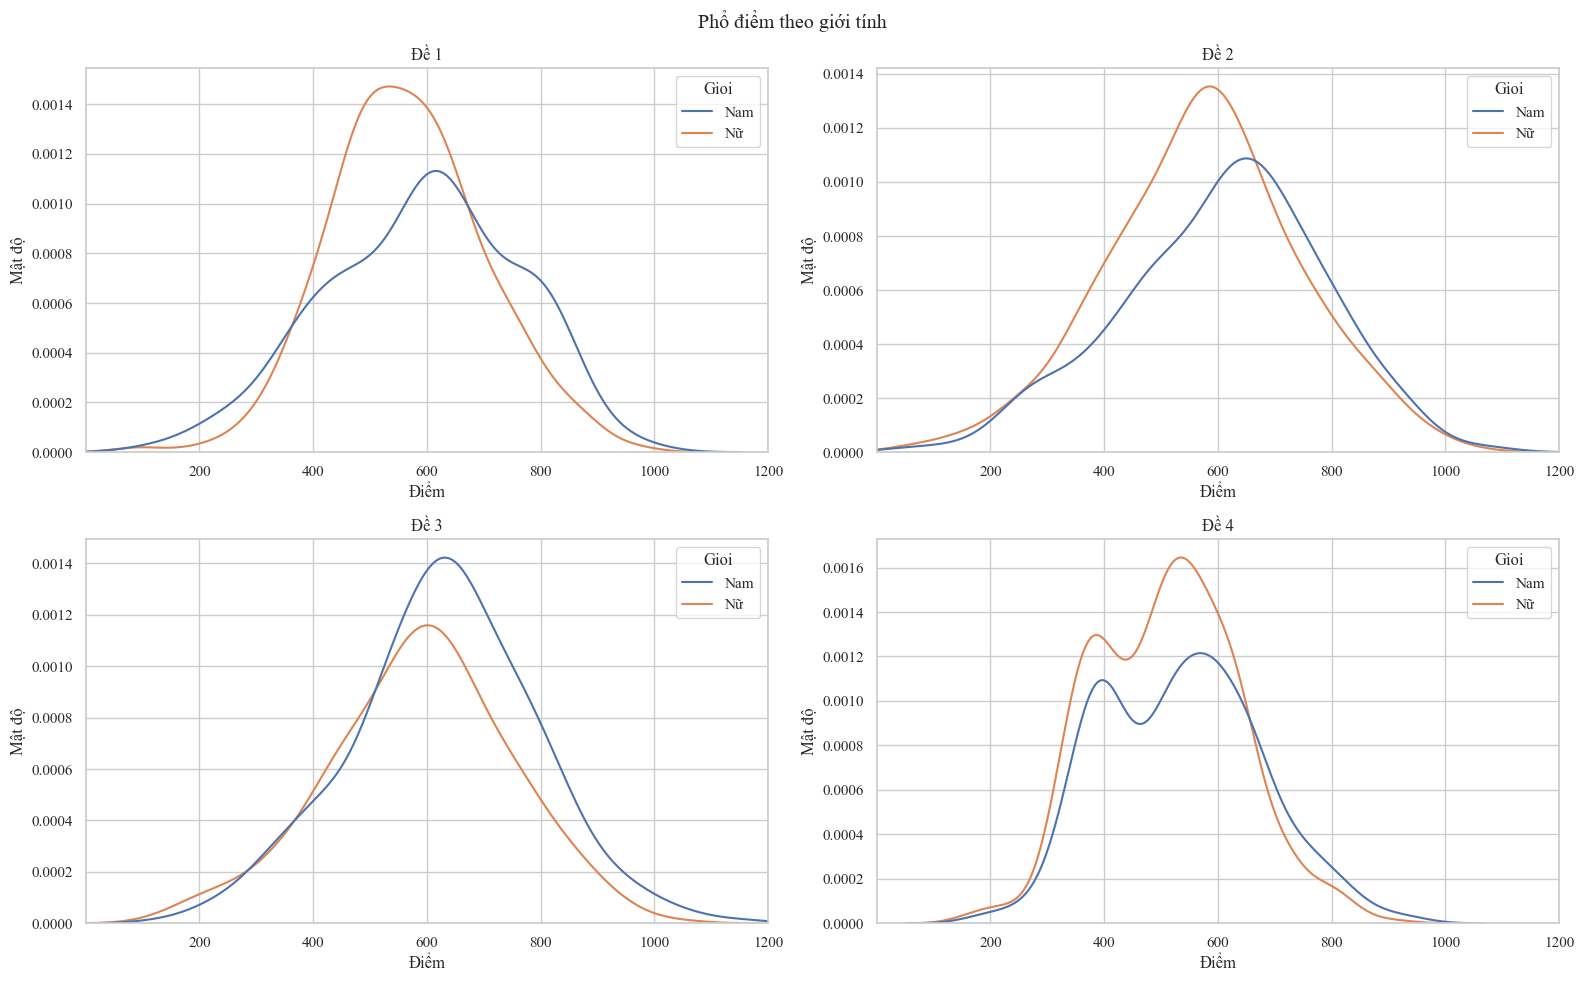

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# =========================
# HÀM KDE THEO GIỚI TÍNH
# =========================
def draw_gender_kde(ax, data, title):
    sns.kdeplot(
        data=data,
        x='Total_True',
        hue='Gioi',
        hue_order=['Nam', 'Nữ'],
        ax=ax
    )

    ax.set_xlim(1, 1200)
    ax.set_title(title)
    ax.set_xlabel('Điểm')
    ax.set_ylabel('Mật độ')


# =========================
# ĐỀ 1
# =========================
draw_gender_kde(
    axes[0],
    true_total_1,
    'Đề 1'
)

# =========================
# ĐỀ 2
# =========================
draw_gender_kde(
    axes[1],
    true_total_2,
    'Đề 2'
)

# =========================
# ĐỀ 3
# =========================
draw_gender_kde(
    axes[2],
    true_total_3,
    'Đề 3'
)

# =========================
# ĐỀ 4
# =========================
draw_gender_kde(
    axes[3],
    true_total_4,
    'Đề 4'
)

plt.suptitle(
    'Phổ điểm theo giới tính',
    y=0.98
)

plt.tight_layout()
plt.show()

#### Các phân tích sau khi ước lượng tham số

Mô hình hoá câu hỏi theo giá trị trên hệ trục

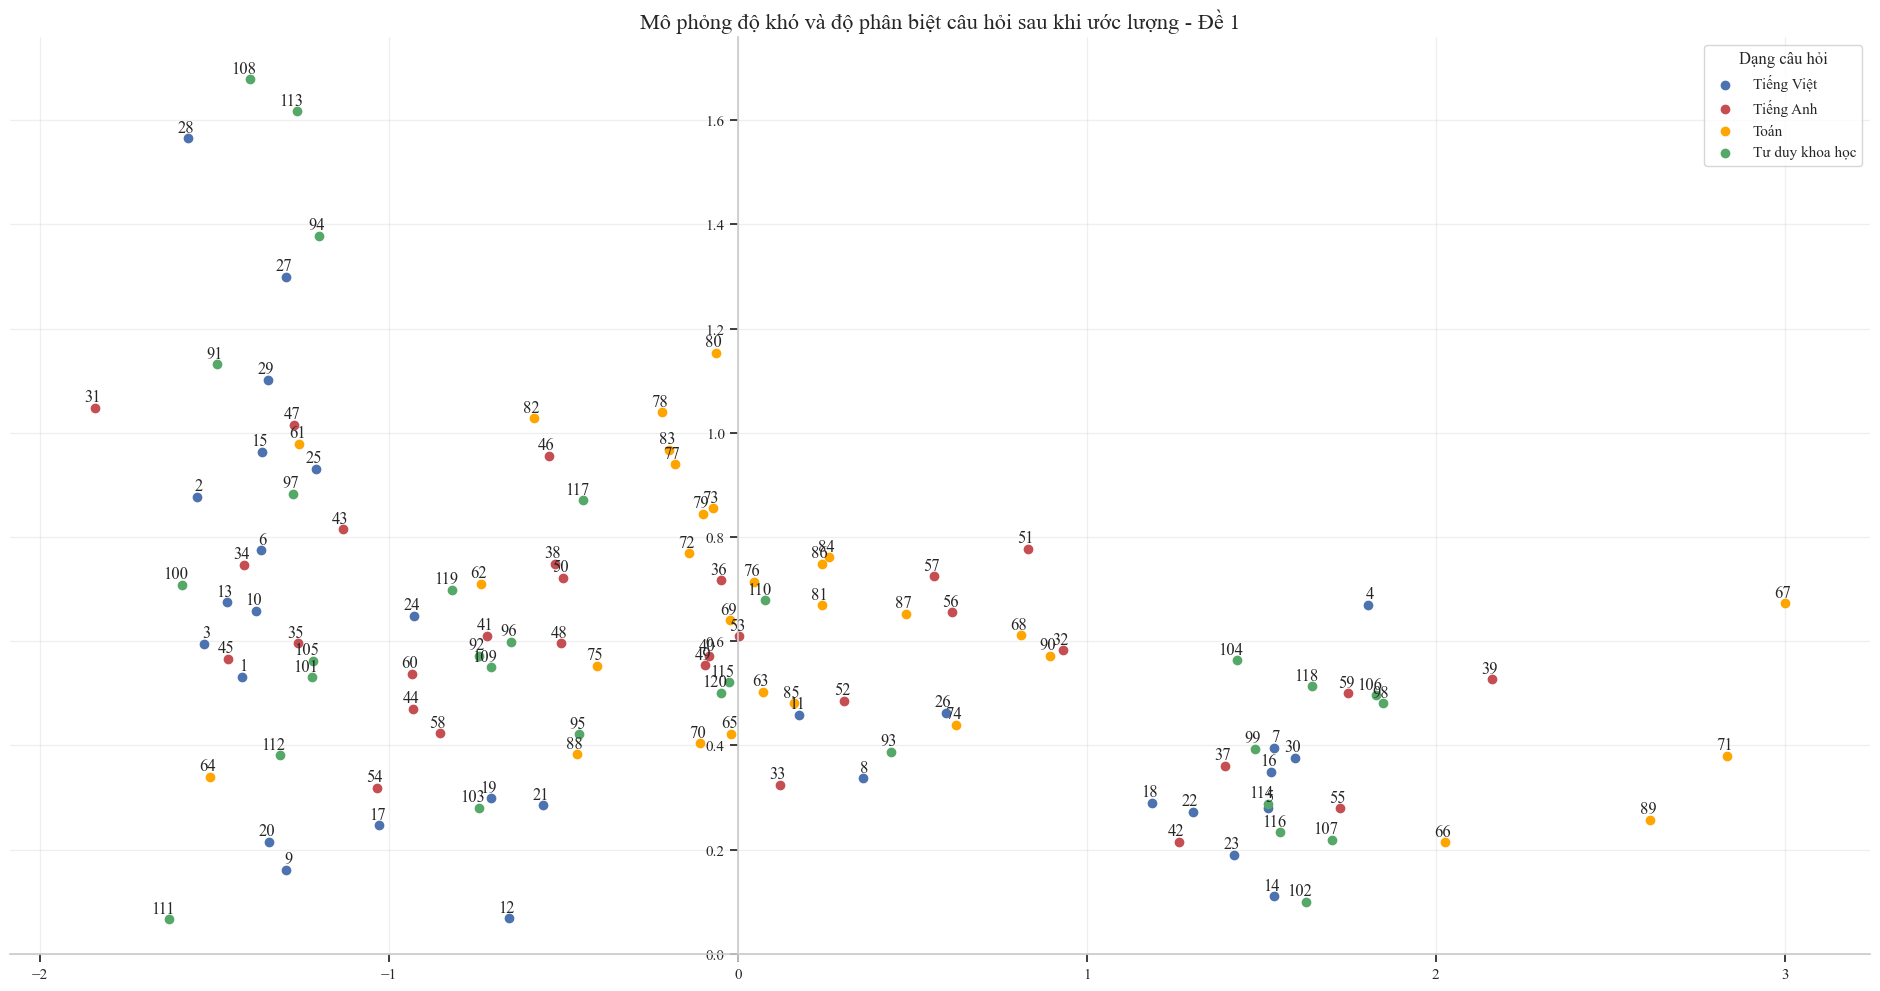

In [ ]:
ip.oxy_item(item_irt_1, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 1')

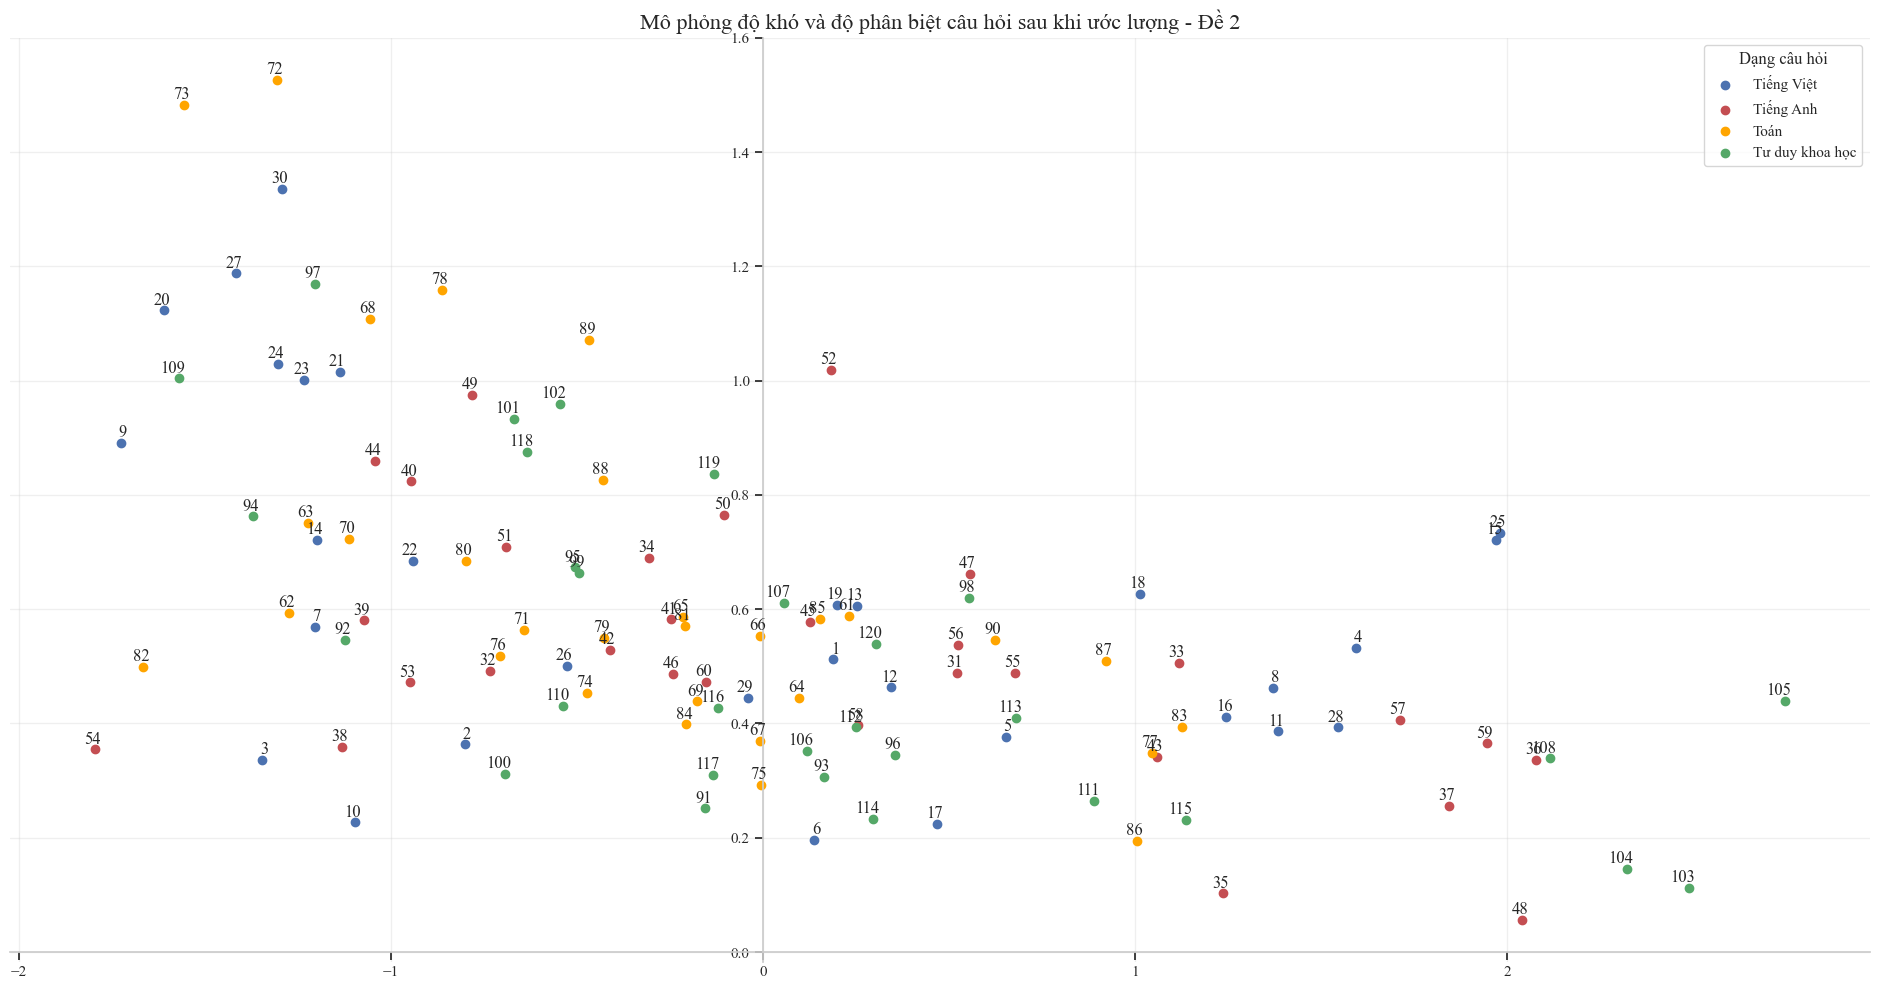

In [ ]:
ip.oxy_item(item_irt_2, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 2')

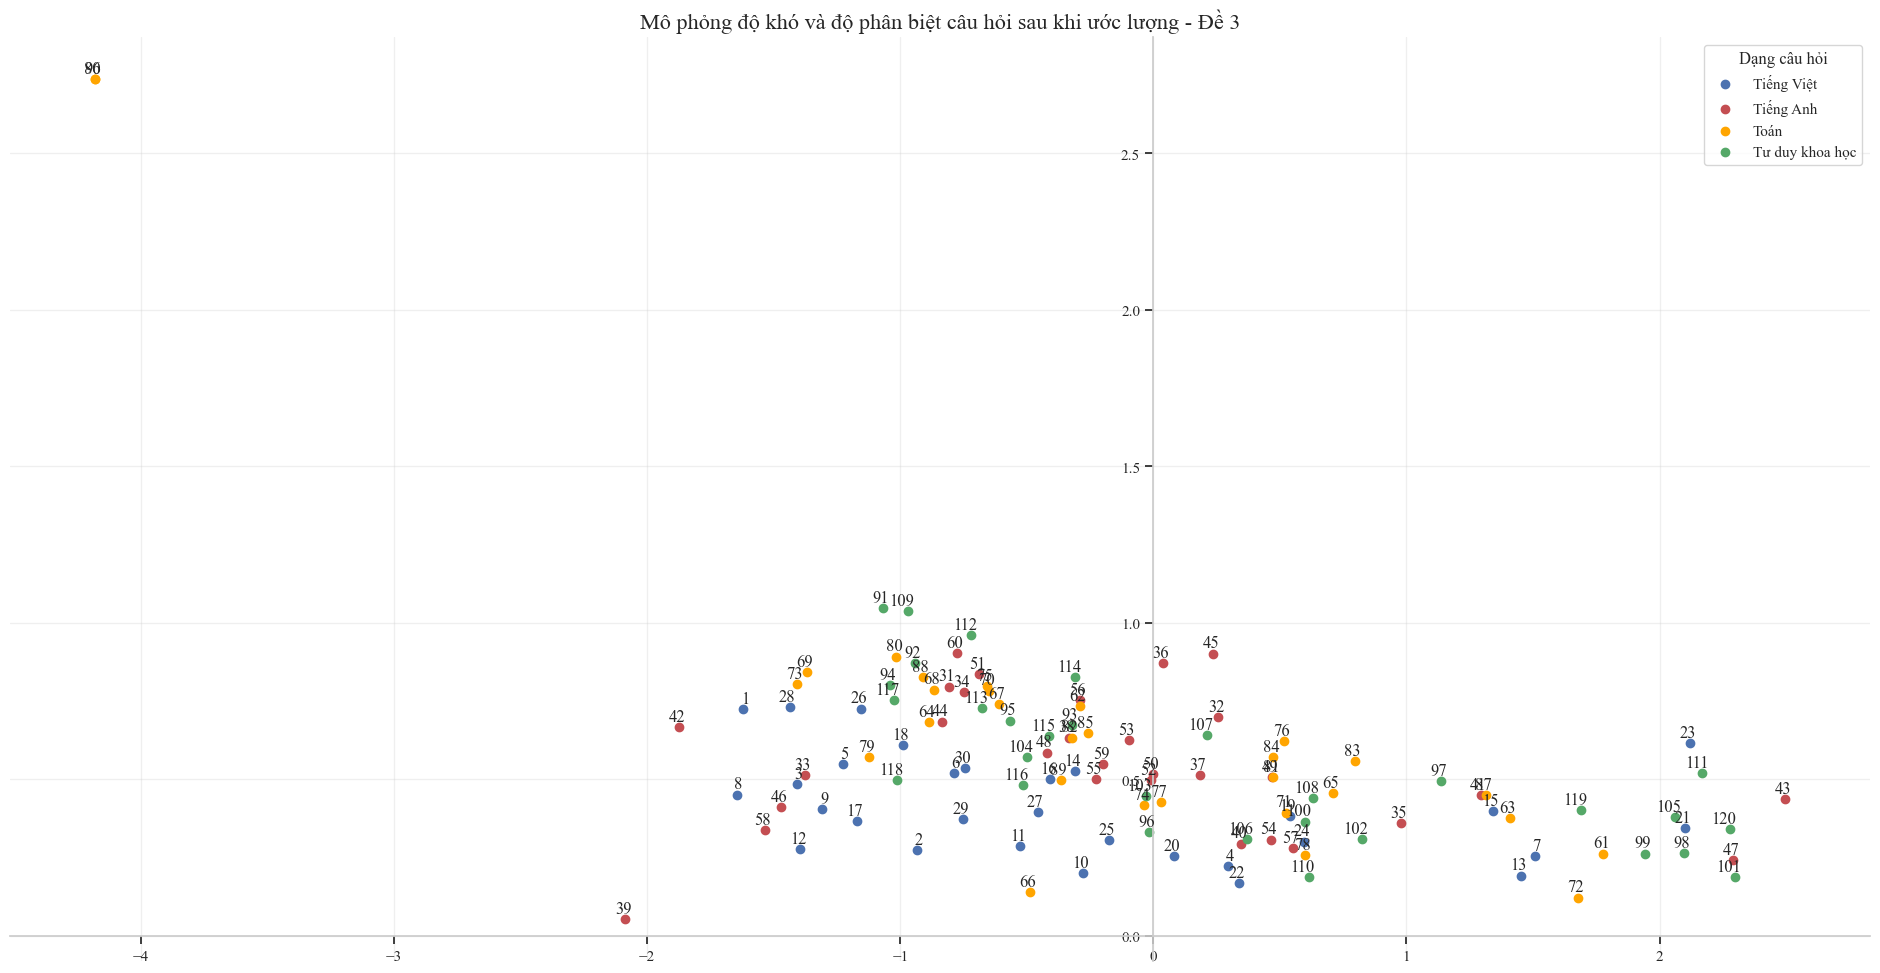

In [ ]:
ip.oxy_item(item_irt_3, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 3')

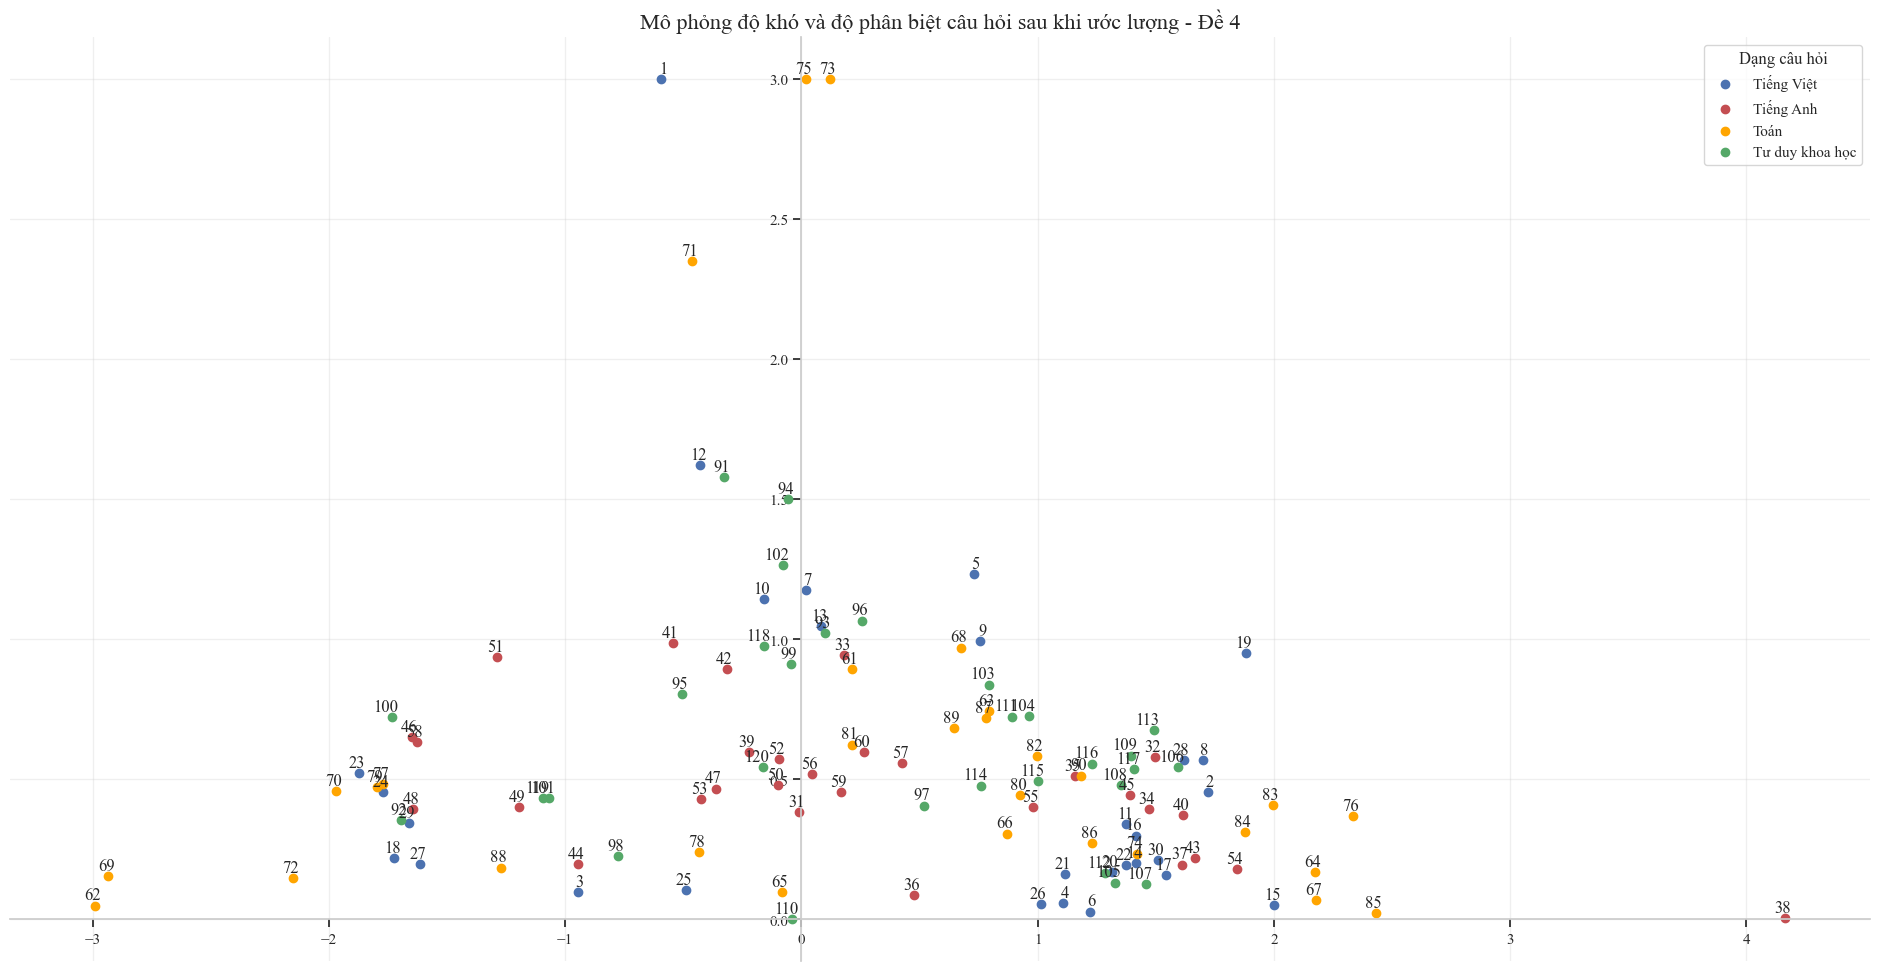

In [ ]:
ip.oxy_item(item_irt_4, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 4')

In [ ]:
item_irt_1['Phần thi'] = (
    item_irt_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

item_irt_2['Phần thi'] = (
    item_irt_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

item_irt_3['Phần thi'] = (
    item_irt_3.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

item_irt_4['Phần thi'] = (
    item_irt_4.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

/content/item_plot.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:368: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


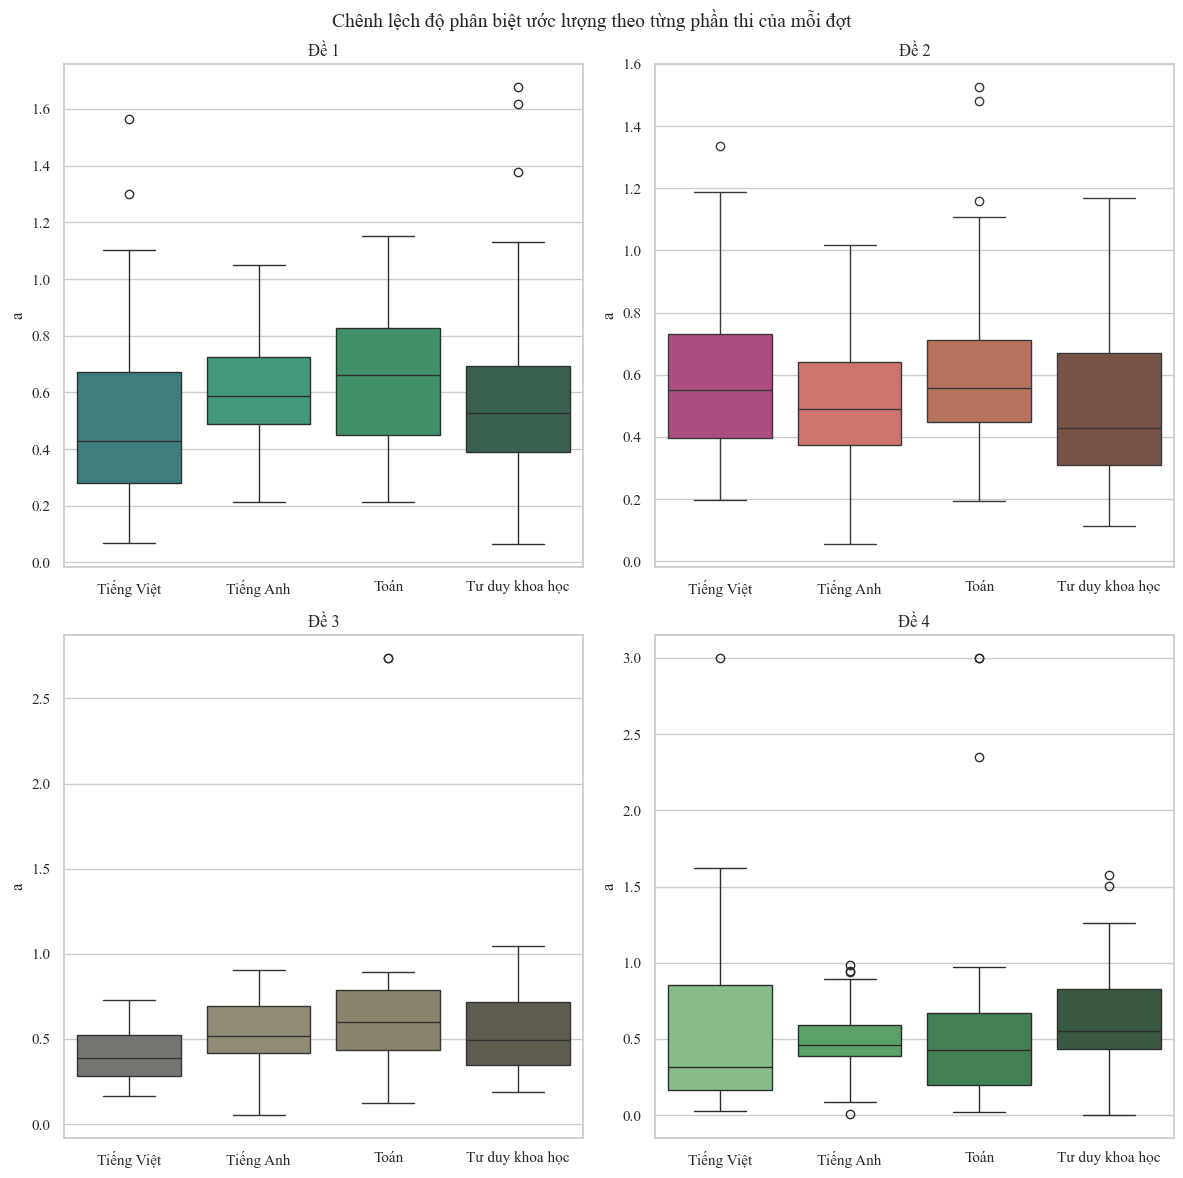

In [ ]:
ip.draw_box_plot(
    item_irt_1,
    item_irt_2,
    item_irt_3,
    item_irt_4,
    'Phần thi',
    'a',
    'viridis_d',
    'plasma_d',
    'cividis_d',
    'Greens_d',
    'Chênh lệch độ phân biệt ước lượng theo từng phần thi của mỗi đợt'
)


/content/item_plot.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:368: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/item_plot.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


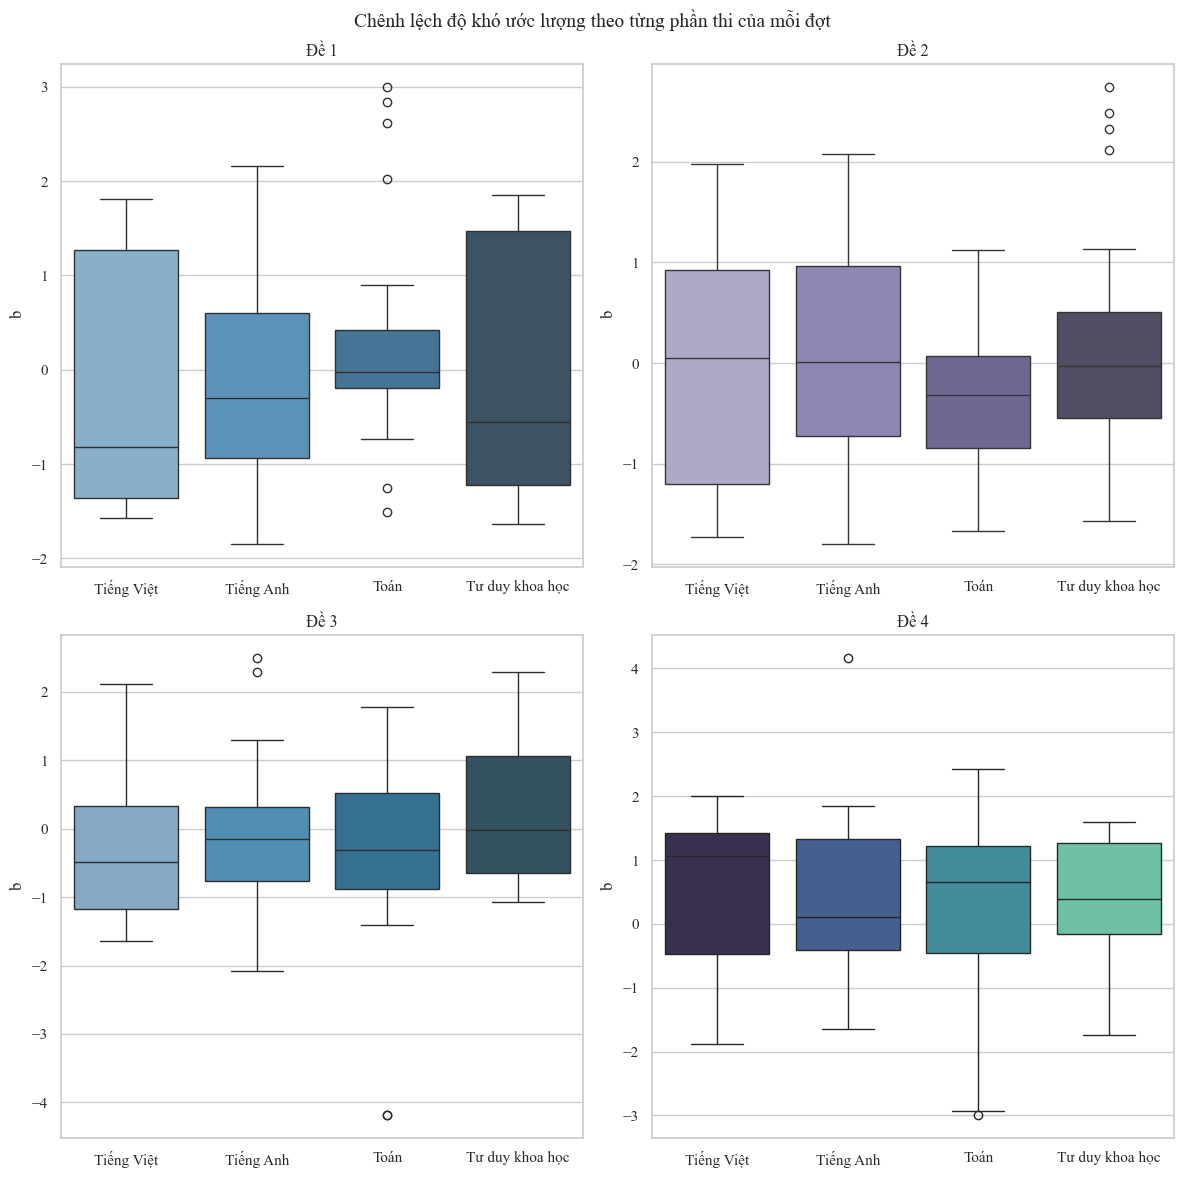

In [ ]:
ip.draw_box_plot(
    item_irt_1,
    item_irt_2,
    item_irt_3,
    item_irt_4,
    'Phần thi',
    'b',
    'Blues_d',
    'Purples_d',
    'PuBu_d',
    'mako',
    'Chênh lệch độ khó ước lượng theo từng phần thi của mỗi đợt'
)


Đường cong đặc tính bài thi (Test Characteristic Curve)

In [ ]:
def drawTTC(df_TV, df_TA, df_TO, df_KH, title: str):
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(16, 9))

    # ------------------------- chỉnh trục -------------------------
    for ax in axes.flat:
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')


    # ---------------------- gọi các subplot ----------------------
    ip.plot_one(axes[0][0], df_TV["Theta"], df_TV["Raw"], "Tiếng Việt", color='b', lim_low=-6, lim_high=6)
    ip.plot_one(axes[0][1], df_TA["Theta"], df_TA["Raw"], "Tiếng Anh", color='r', lim_low=-6, lim_high=6)
    ip.plot_one(axes[1][0], df_TO["Theta"], df_TO["Raw"], "Toán", color='y', lim_low=-6, lim_high=6)
    ip.plot_one(axes[1][1], df_KH["Theta"], df_KH["Raw"], "Tư duy khoa học", color='g', lim_low=-6, lim_high=6)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


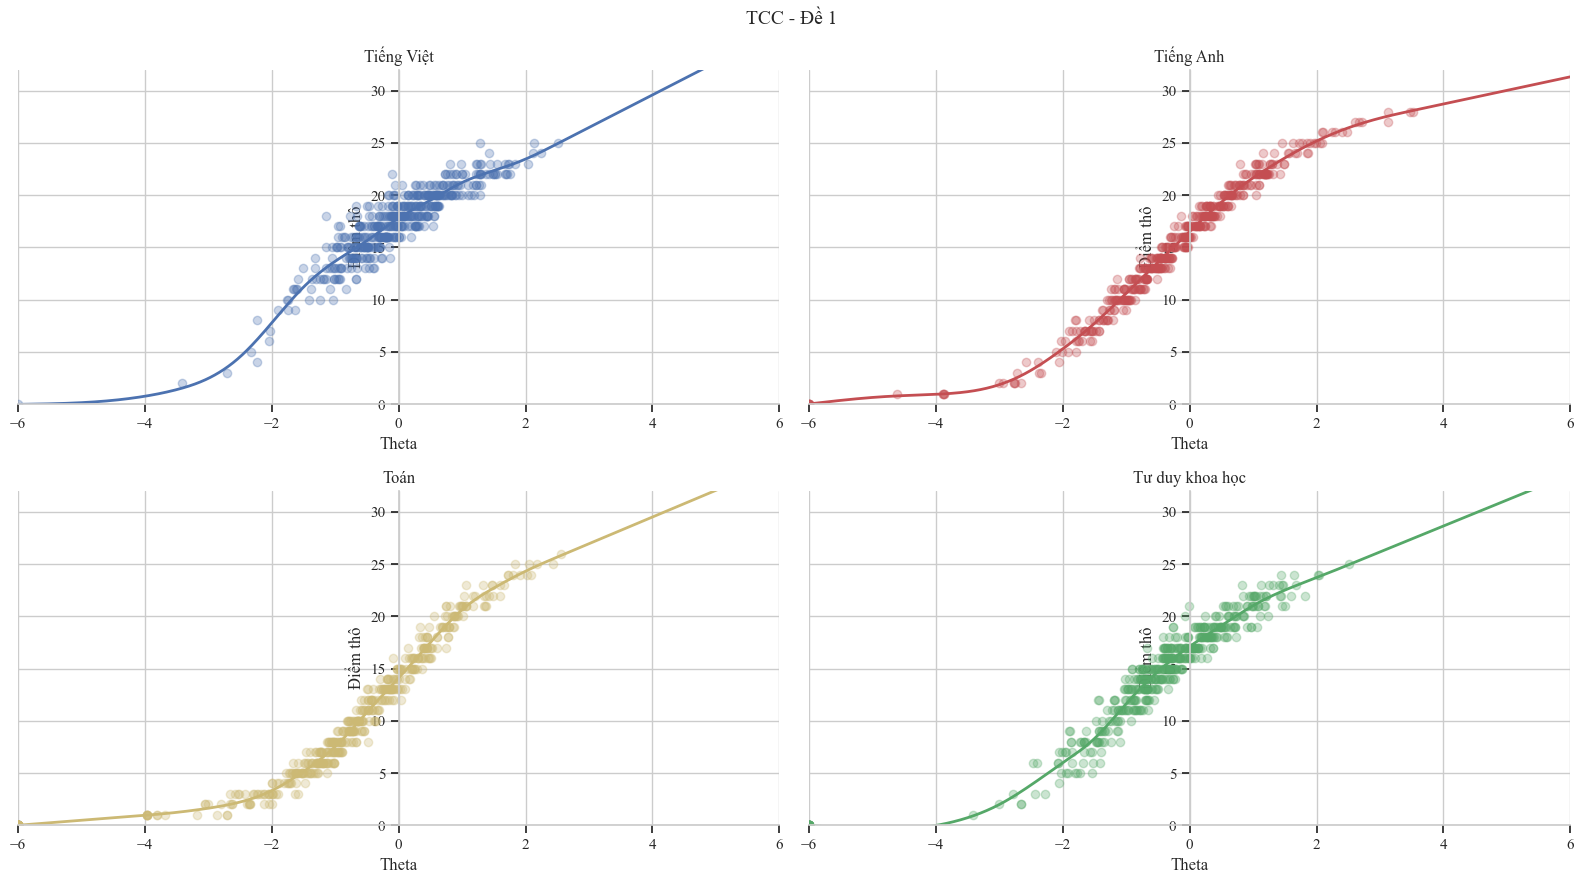

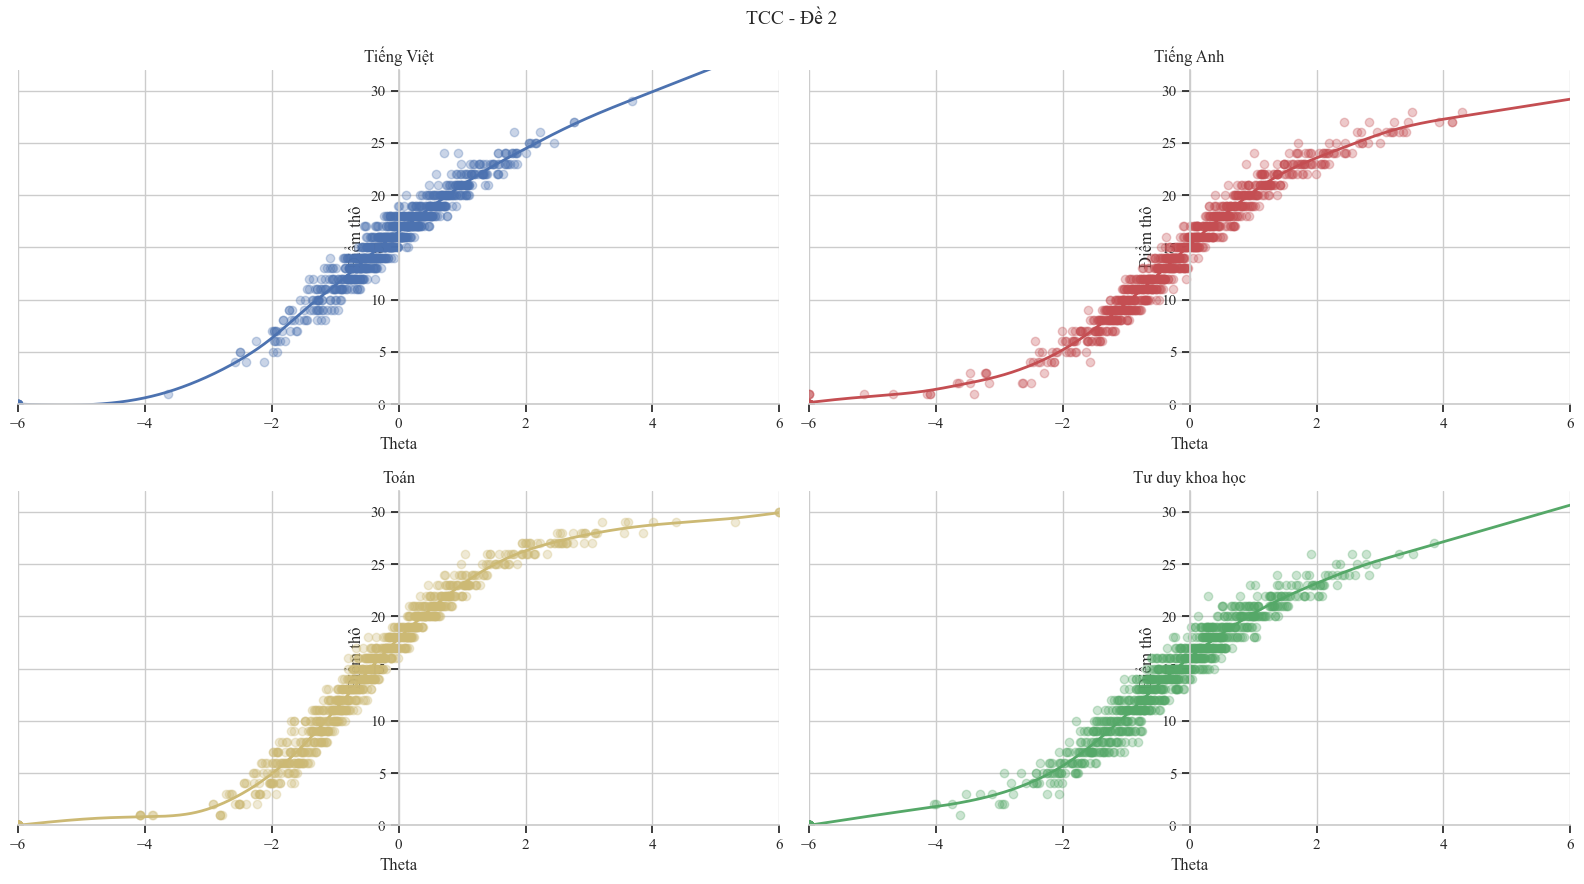

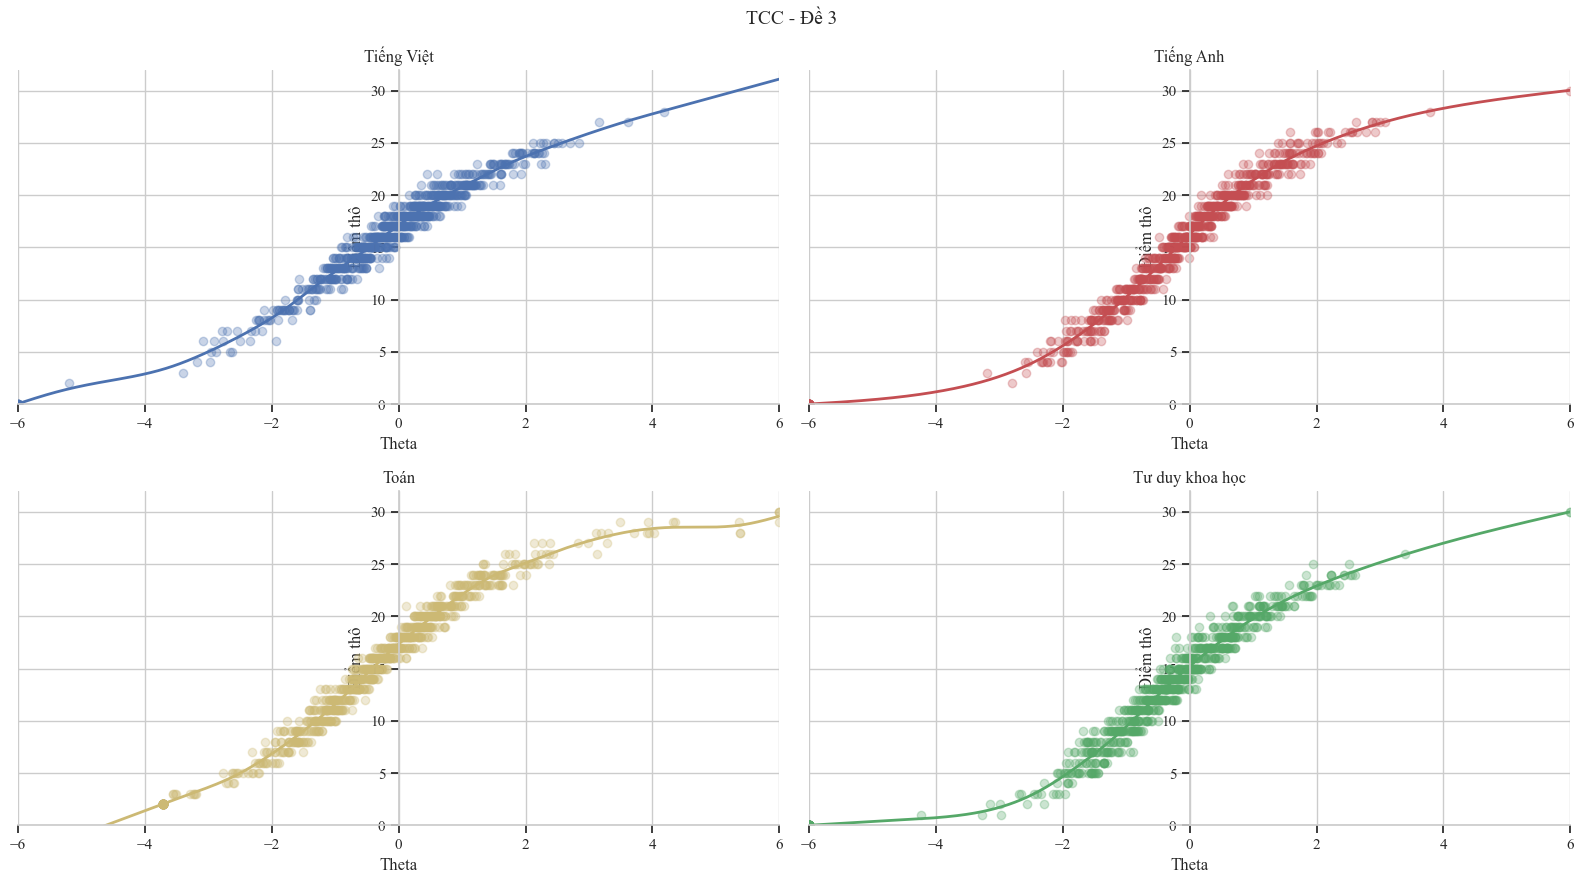

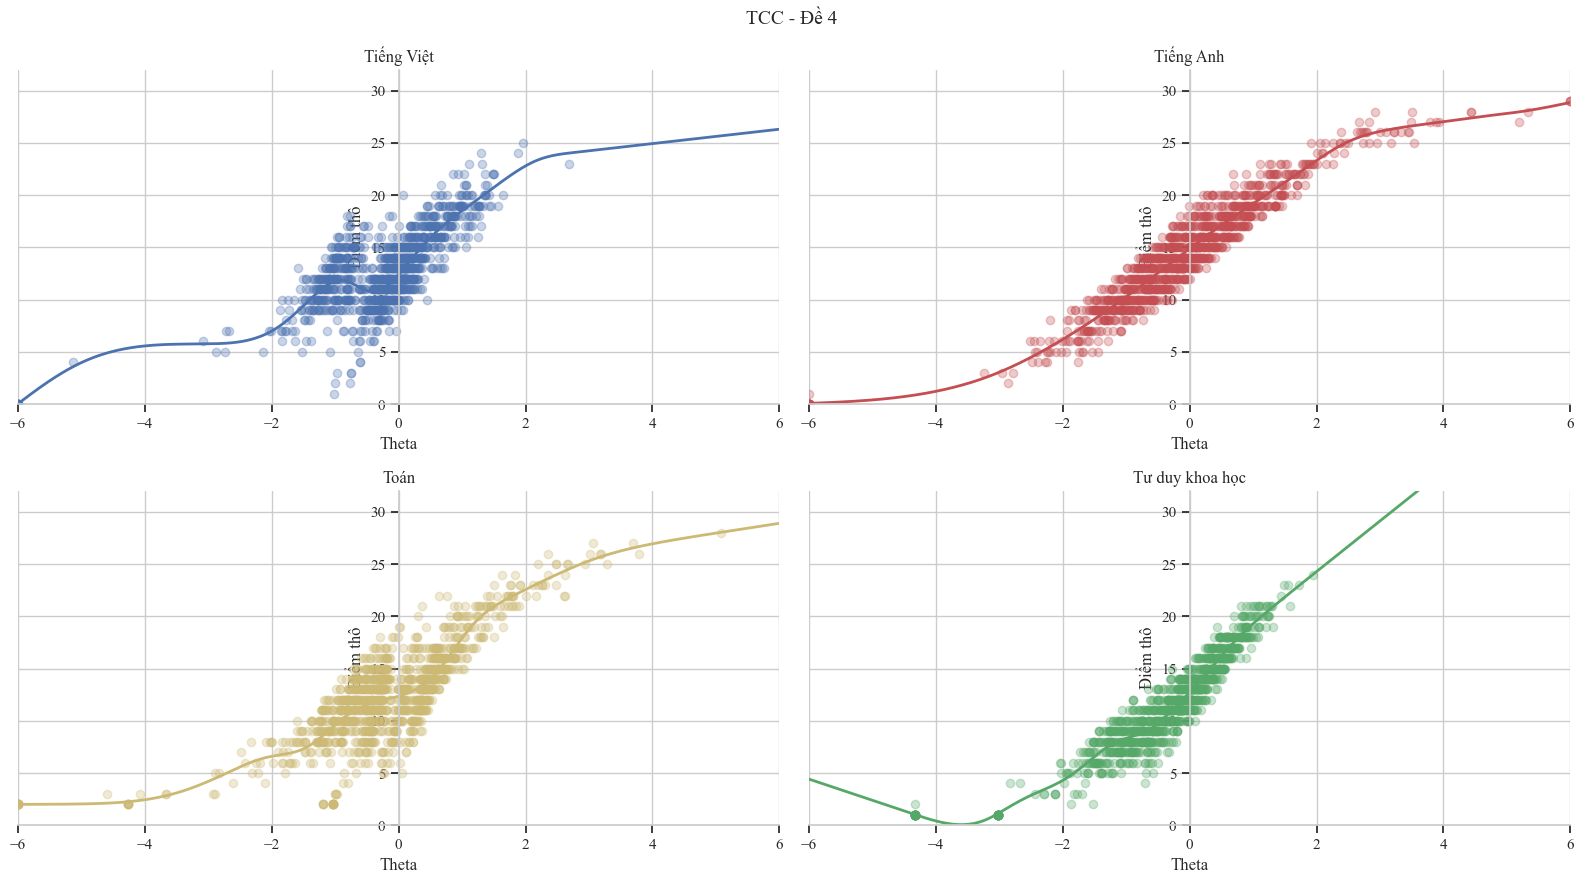

In [ ]:
drawTTC(df_TV1, df_TA1, df_TO1, df_KH1, title="TCC - Đề 1")
drawTTC(df_TV2, df_TA2, df_TO2, df_KH2, title="TCC - Đề 2")
drawTTC(df_TV3, df_TA3, df_TO3, df_KH3, title="TCC - Đề 3")
drawTTC(df_TV4, df_TA4, df_TO4, df_KH4, title="TCC - Đề 4")

So sánh độ khó câu hỏi với năng lực từng phần của thí sinh

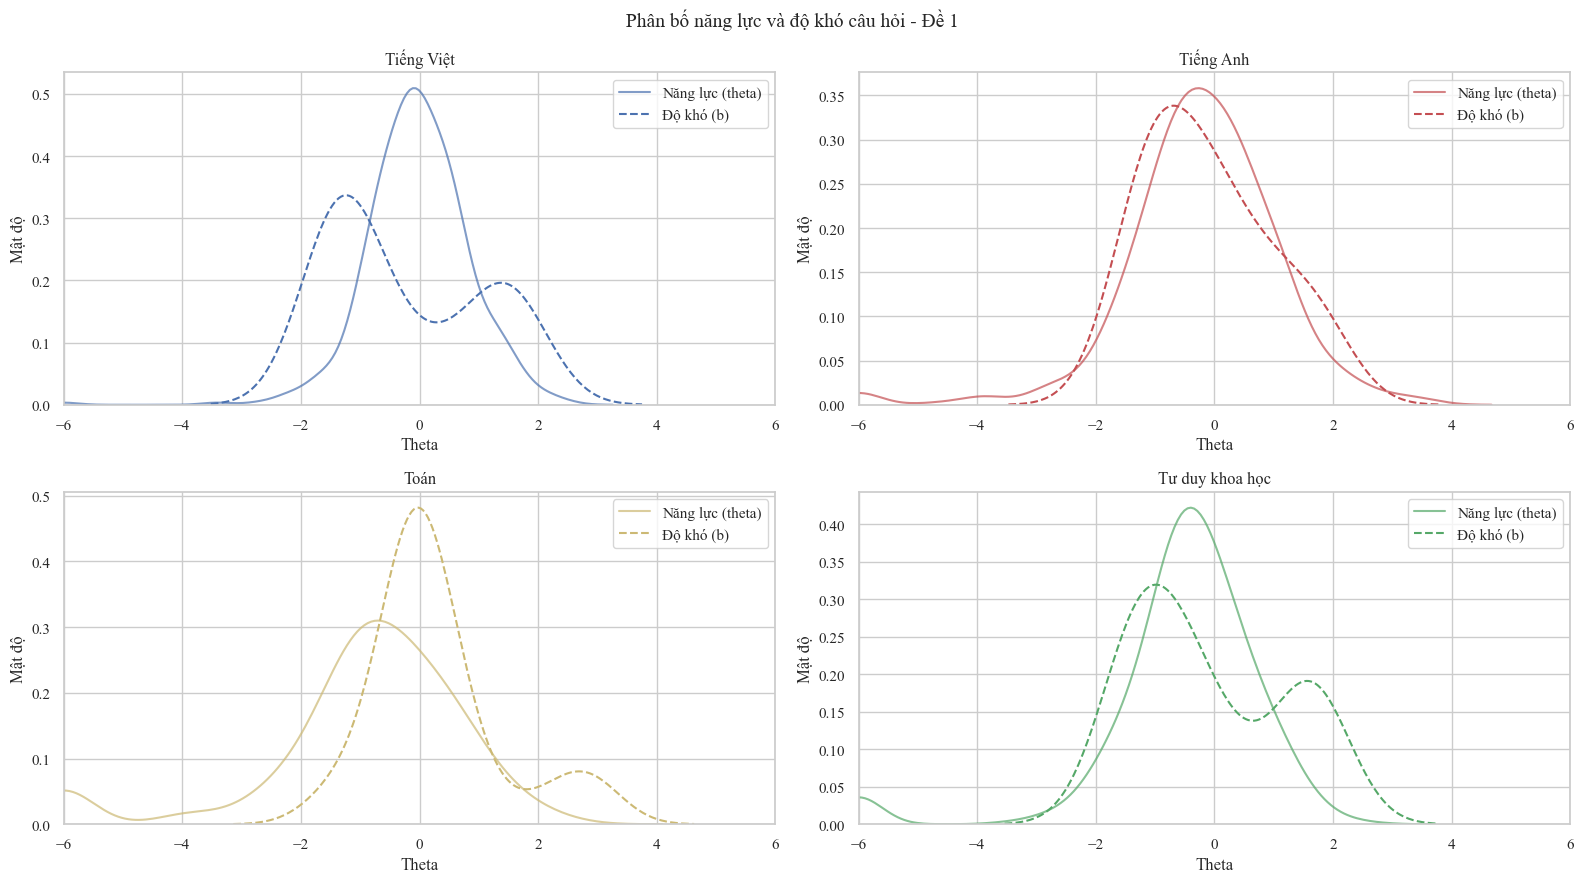

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

def plot_kde_theta_b(ax, theta, diff, title, color):
        sns.kdeplot(
            x=theta,
            color=color, fill=False, alpha=0.7, label="Năng lực (theta)", ax=ax
        )
        sns.kdeplot(
            x=diff,
            color=color, fill=False, alpha=1.0, linestyle="--", label="Độ khó (b)", ax=ax
        )

        ax.set_xlim(-6, 6)
        ax.set_ylabel("Mật độ")
        ax.set_title(f"{title}")
        ax.legend()

plot_kde_theta_b(axes[0], df_TV1["Theta"], item_irt_1.loc['Cau1':'Cau30', 'b'], "Tiếng Việt", color='b')
plot_kde_theta_b(axes[1], df_TA1["Theta"], item_irt_1.loc['Cau31':'Cau60', 'b'], "Tiếng Anh", color='r')
plot_kde_theta_b(axes[2], df_TO1["Theta"], item_irt_1.loc['Cau61':'Cau90', 'b'], "Toán", color='y')
plot_kde_theta_b(axes[3], df_KH1["Theta"], item_irt_1.loc['Cau91':'Cau120', 'b'], "Tư duy khoa học", color='g')

plt.suptitle("Phân bố năng lực và độ khó câu hỏi - Đề 1", fontsize=14)
plt.tight_layout()
plt.show()

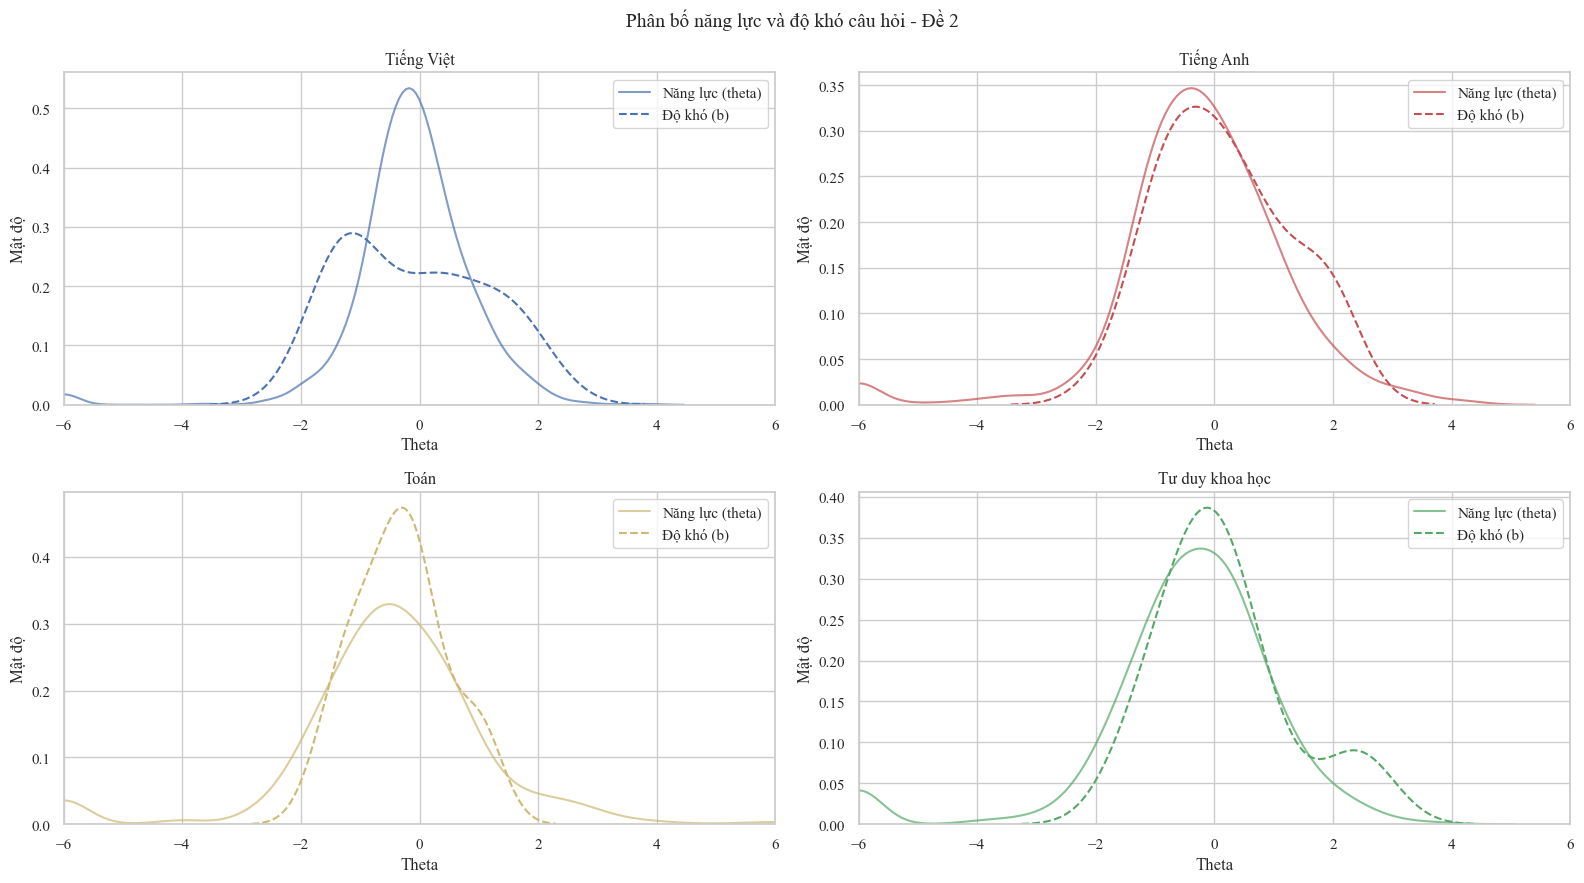

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
plot_kde_theta_b(axes[0], df_TV2["Theta"], item_irt_2.loc['Cau1':'Cau30', 'b'], "Tiếng Việt", color='b')
plot_kde_theta_b(axes[1], df_TA2["Theta"], item_irt_2.loc['Cau31':'Cau60', 'b'], "Tiếng Anh", color='r')
plot_kde_theta_b(axes[2], df_TO2["Theta"], item_irt_2.loc['Cau61':'Cau90', 'b'], "Toán", color='y')
plot_kde_theta_b(axes[3], df_KH2["Theta"], item_irt_2.loc['Cau91':'Cau120', 'b'], "Tư duy khoa học", color='g')

plt.suptitle("Phân bố năng lực và độ khó câu hỏi - Đề 2", fontsize=14)
plt.tight_layout()
plt.show()

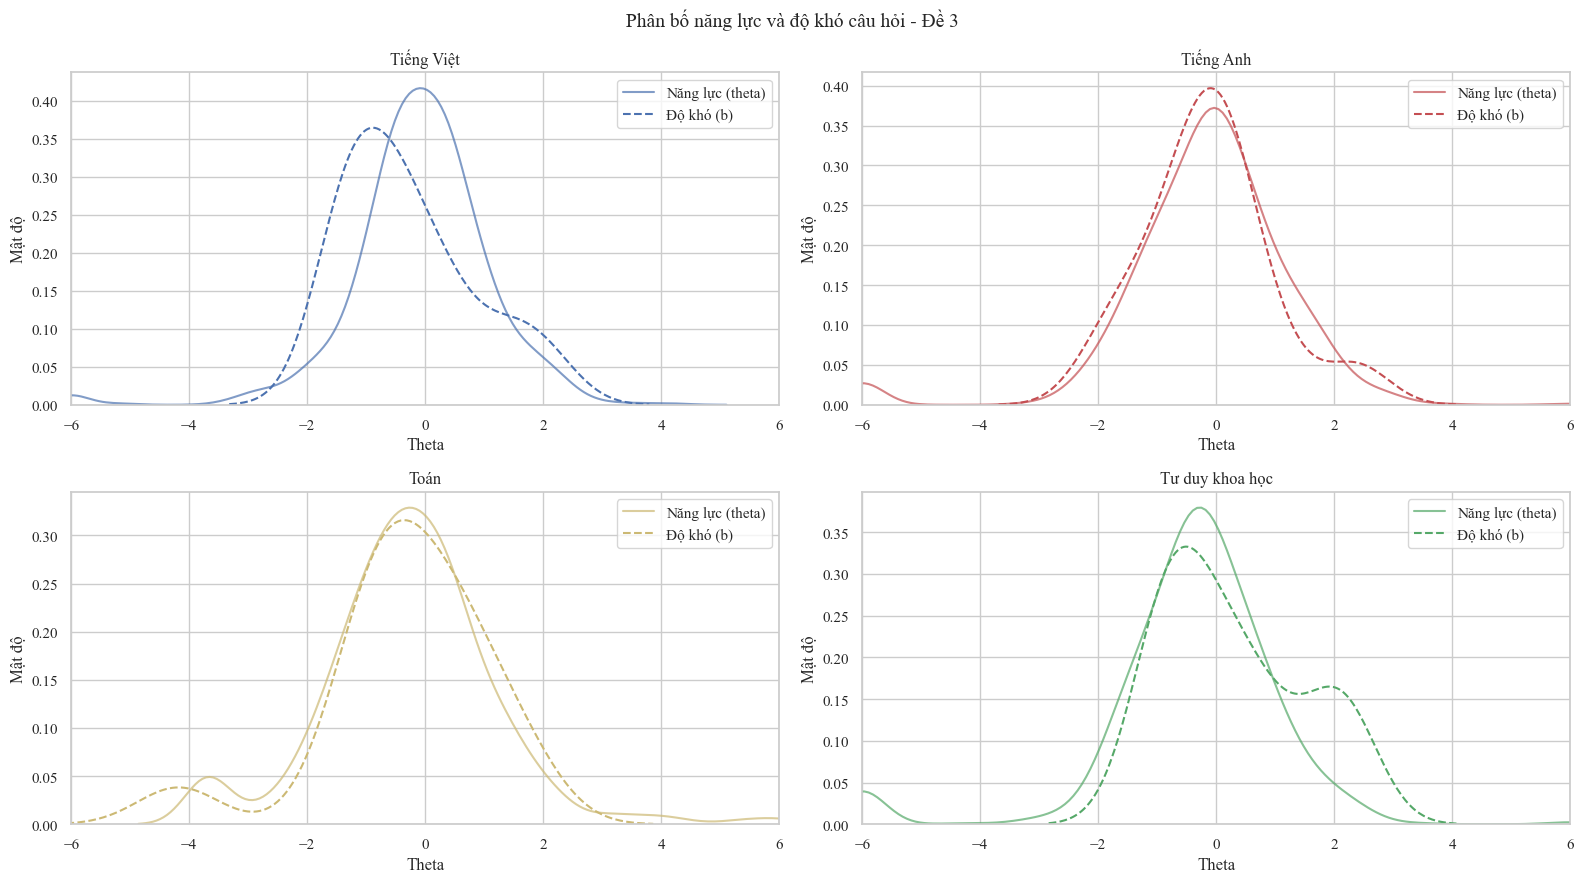

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
plot_kde_theta_b(axes[0], df_TV3["Theta"], item_irt_3.loc['Cau1':'Cau30', 'b'], "Tiếng Việt", color='b')
plot_kde_theta_b(axes[1], df_TA3["Theta"], item_irt_3.loc['Cau31':'Cau60', 'b'], "Tiếng Anh", color='r')
plot_kde_theta_b(axes[2], df_TO3["Theta"], item_irt_3.loc['Cau61':'Cau90', 'b'], "Toán", color='y')
plot_kde_theta_b(axes[3], df_KH3["Theta"], item_irt_3.loc['Cau91':'Cau120', 'b'], "Tư duy khoa học", color='g')

plt.suptitle("Phân bố năng lực và độ khó câu hỏi - Đề 3", fontsize=14)
plt.tight_layout()
plt.show()

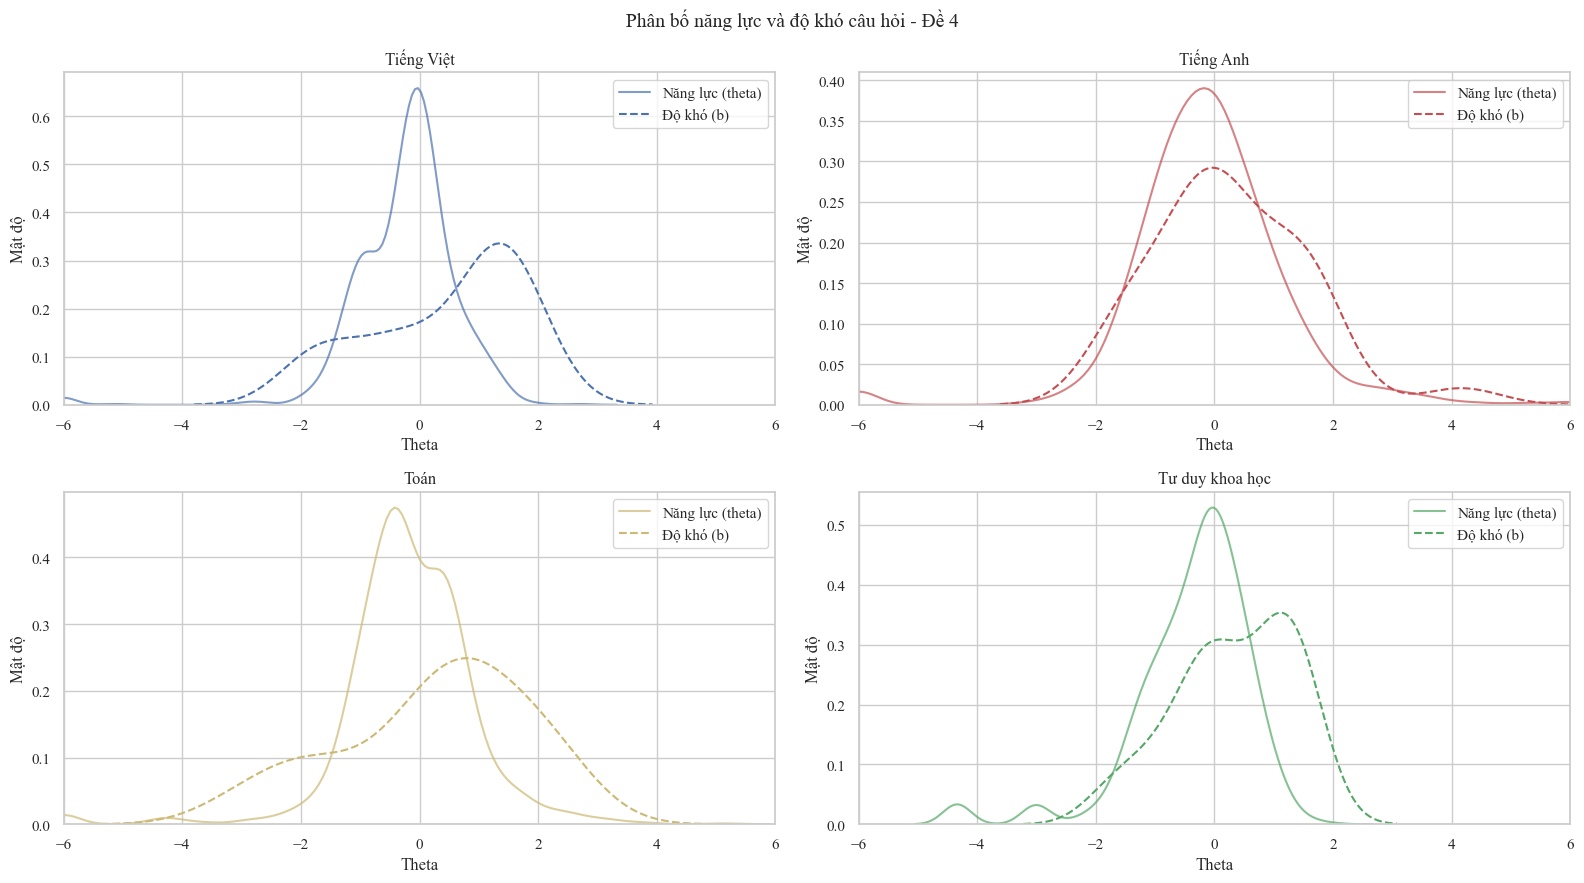

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
plot_kde_theta_b(axes[0], df_TV4["Theta"], item_irt_4.loc['Cau1':'Cau30', 'b'], "Tiếng Việt", color='b')
plot_kde_theta_b(axes[1], df_TA4["Theta"], item_irt_4.loc['Cau31':'Cau60', 'b'], "Tiếng Anh", color='r')
plot_kde_theta_b(axes[2], df_TO4["Theta"], item_irt_4.loc['Cau61':'Cau90', 'b'], "Toán", color='y')
plot_kde_theta_b(axes[3], df_KH4["Theta"], item_irt_4.loc['Cau91':'Cau120', 'b'], "Tư duy khoa học", color='g')

plt.suptitle("Phân bố năng lực và độ khó câu hỏi - Đề 4", fontsize=14)
plt.tight_layout()
plt.show()

Misfit và sai số chuẩn của từng tham số trong câu hỏi

In [ ]:
chi_square_1, chi_square_2, chi_square_3 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

for df_list in [df_TV1, df_TA1, df_TO1, df_KH1]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_1.loc[start_item:end_item]) # loại các trường hợp không thi 1 phần
    res.index = item_irt_1.loc[start_item:end_item].index
    chi_square_1 = pd.concat([chi_square_1, res], axis=0)

for df_list in [df_TV2, df_TA2, df_TO2, df_KH2]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_2.loc[start_item:end_item])
    res.index = item_irt_2.loc[start_item:end_item].index
    chi_square_2 = pd.concat([chi_square_2, res], axis=0)

for df_list in [df_TV3, df_TA3, df_TO3, df_KH3]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_3.loc[start_item:end_item])
    res.index = item_irt_3.loc[start_item:end_item].index
    chi_square_3 = pd.concat([chi_square_3, res], axis=0)

for df_list in [df_TV4, df_TA4, df_TO4, df_KH4]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_4.loc[start_item:end_item])
    res.index = item_irt_4.loc[start_item:end_item].index
    chi_square_4 = pd.concat([chi_square_4, res], axis=0)


item_irt_1 = pd.concat([item_irt_1, chi_square_1], axis=1)
item_irt_2 = pd.concat([item_irt_2, chi_square_2], axis=1)
item_irt_3 = pd.concat([item_irt_3, chi_square_3], axis=1)
item_irt_4 = pd.concat([item_irt_4, chi_square_4], axis=1)

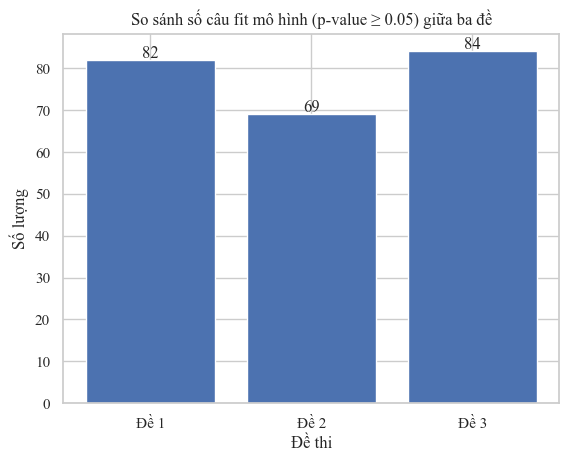

In [ ]:
num_pvalue_1 = item_irt_1[item_irt_1['p_value']>=0.05].shape[0]
num_pvalue_2 = item_irt_2[item_irt_2['p_value']>=0.05].shape[0]
num_pvalue_3 = item_irt_3[item_irt_3['p_value']>=0.05].shape[0]
num_pvalue_4 = item_irt_4[item_irt_4['p_value']>=0.05].shape[0]

labels = ["Đề 1", "Đề 2", "Đề 3", "Đề 4"]
values = [num_pvalue_1, num_pvalue_2, num_pvalue_3, num_pvalue_4]

plt.bar(labels, values)
plt.xlabel("Đề thi")
plt.ylabel("Số lượng")
plt.title("So sánh số câu fit mô hình (p-value ≥ 0.05) giữa bốn đề")
for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12)
plt.show()


In [ ]:
chi_square_1['Phân loại'] = (
    chi_square_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

chi_square_2['Phân loại'] = (
    chi_square_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

chi_square_3['Phân loại'] = (
    chi_square_3.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

chi_square_4['Phân loại'] = (
    chi_square_4.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

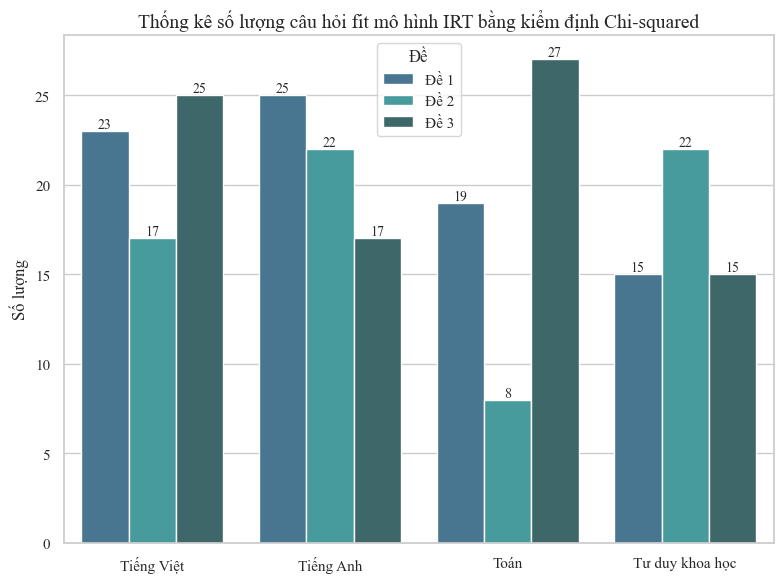

In [ ]:
ip.plot_item(chi_square_1[chi_square_1['p_value']>=0.05],
             chi_square_2[chi_square_2['p_value']>=0.05],
                chi_square_3[chi_square_3['p_value']>=0.05],
               chi_square_4[chi_square_4['p_value']>=0.05],
             title='Thống kê số lượng câu hỏi fit mô hình IRT bằng kiểm định Chi-squared', order=['Tiếng Việt', 'Tiếng Anh', 'Toán', 'Tư duy khoa học'], palette='mako_d', size=(8,6))

In [ ]:
for item_list in ([item_irt_1, item_irt_2, item_irt_3, item_irt_4]):
    ses = irt.all_item_se(item_list[['a', 'b']].to_numpy())
    item_list['a_SE'] = ses[:, 0]
    item_list['b_SE'] = ses[:, 1]

Text(0.5, 1.0, 'Sai số chuẩn ước lượng tham số các câu hỏi')

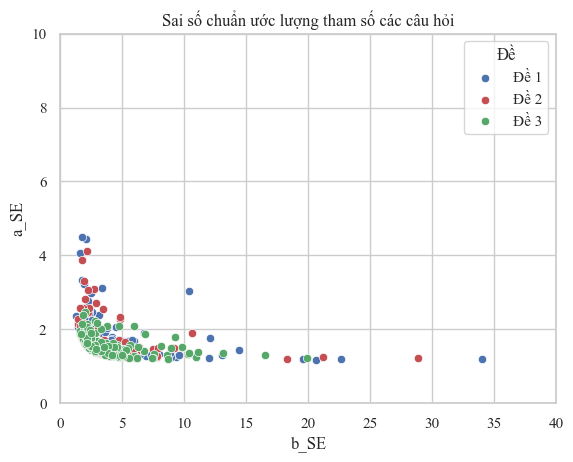

In [ ]:
sns.scatterplot(data=item_irt_1, x='b_SE', y='a_SE', color='b', label='Đề 1')
sns.scatterplot(data=item_irt_2, x='b_SE', y='a_SE', color='r', label='Đề 2')
sns.scatterplot(data=item_irt_3, x='b_SE', y='a_SE', color='g', label='Đề 3')
sns.scatterplot(data=item_irt_4, x='b_SE', y='a_SE', color='m', label='Đề 4')
plt.xlim(0, 40)
plt.ylim(0, 10)
plt.legend(title='Đề')
plt.title("Sai số chuẩn ước lượng tham số các câu hỏi")

Text(0.5, 1.0, 'Thống kê các câu hỏi không phù hợp với mô hình theo p_value')

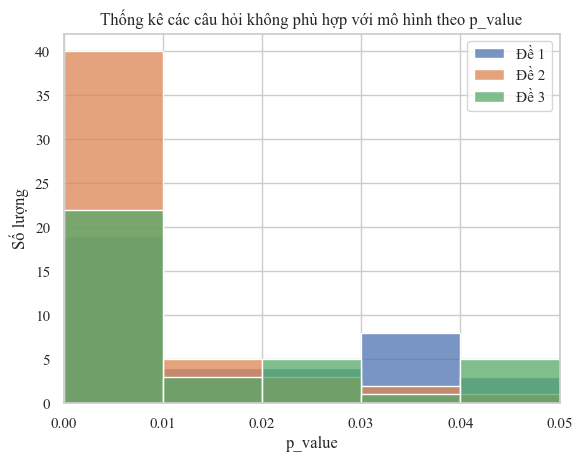

In [ ]:
sns.histplot(item_irt_1[item_irt_1['p_value'] <0.05]['p_value'], label='Đề 1', bins=5, binrange=(0, 0.05))
sns.histplot(item_irt_2[item_irt_2['p_value'] <0.05]['p_value'], label='Đề 2', bins=5, binrange=(0, 0.05))
sns.histplot(item_irt_3[item_irt_3['p_value'] <0.05]['p_value'], label='Đề 3', bins=5, binrange=(0, 0.05))
sns.histplot(item_irt_4[item_irt_4['p_value'] <0.05]['p_value'], label='Đề 4', bins=5, binrange=(0, 0.05))
plt.legend()
plt.xlim(0, 0.05)
plt.ylabel('Số lượng')
plt.title('Thống kê các câu hỏi không phù hợp với mô hình theo p_value')

In [ ]:
print('Thống kê ở đề 1:')
print(f'- Các câu hỏi misfit: {list(item_irt_1[item_irt_1['p_value'] <0.05].index)}')
print(f'- Các câu hỏi có a_SE cao: {list(item_irt_1[item_irt_1['a_SE'] > 3.0].index)}')
print(f'- Các câu hỏi có b_SE cao: {list(item_irt_1[item_irt_1['b_SE'] > 10.0].index)}')
print(f"CẦN PHẢI XEM XÉT VÀ CHỈNH SỬA HOẶC LOẠI BỎ: {list(item_irt_1[(item_irt_1['p_value'] < 0.05) &
                                                    ((item_irt_1['b_SE'] > 10.0) | (item_irt_1['a_SE'] > 3.0))
        ].index
    )}"
)


print('\nThống kê ở đề 2:')
print(f'- Các câu hỏi misfit: {list(item_irt_2[item_irt_2['p_value'] <0.05].index)}')
print(f'- Các câu hỏi có a_SE cao: {list(item_irt_2[item_irt_2['a_SE'] > 3.0].index)}')
print(f'- Các câu hỏi có b_SE cao: {list(item_irt_2[item_irt_2['b_SE'] > 10.0].index)}')
print(f"CẦN PHẢI XEM XÉT VÀ CHỈNH SỬA HOẶC LOẠI BỎ: {list(item_irt_2[(item_irt_2['p_value'] < 0.05) &
                                                    ((item_irt_2['b_SE'] > 10.0) | (item_irt_2['a_SE'] > 3.0))
        ].index
    )}"
)

print('\nThống kê ở đề 3:')
print(f'- Các câu hỏi misfit: {list(item_irt_3[item_irt_3['p_value'] <0.05].index)}')
print(f'- Các câu hỏi có a_SE cao: {list(item_irt_3[item_irt_3['a_SE'] > 3.0].index)}')
print(f'- Các câu hỏi có b_SE cao: {list(item_irt_3[item_irt_3['b_SE'] > 10.0].index)}')
print(f"CẦN PHẢI XEM XÉT VÀ CHỈNH SỬA HOẶC LOẠI BỎ: {list(item_irt_3[(item_irt_3['p_value'] < 0.05) &
                                                    ((item_irt_3['b_SE'] > 10.0) | (item_irt_3['a_SE'] > 3.0))
        ].index
    )}"
)

print('\nThống kê ở đề 4:')
print(f'- Các câu hỏi misfit: {list(item_irt_4[item_irt_4['p_value'] <0.05].index)}')
print(f'- Các câu hỏi có a_SE cao: {list(item_irt_4[item_irt_4['a_SE'] > 3.0].index)}')
print(f'- Các câu hỏi có b_SE cao: {list(item_irt_4[item_irt_4['b_SE'] > 10.0].index)}')
print(f"CẦN PHẢI XEM XÉT VÀ CHỈNH SỬA HOẶC LOẠI BỎ: {list(item_irt_4[(item_irt_4['p_value'] < 0.05) &
                                                    ((item_irt_4['b_SE'] > 10.0) | (item_irt_4['a_SE'] > 3.0))
        ].index
    )}"
)

Thống kê ở đề 1:
- Các câu hỏi misfit: ['Cau2', 'Cau3', 'Cau4', 'Cau7', 'Cau14', 'Cau16', 'Cau30', 'Cau31', 'Cau32', 'Cau39', 'Cau47', 'Cau55', 'Cau61', 'Cau62', 'Cau64', 'Cau67', 'Cau71', 'Cau74', 'Cau79', 'Cau85', 'Cau88', 'Cau89', 'Cau90', 'Cau91', 'Cau97', 'Cau98', 'Cau104', 'Cau105', 'Cau106', 'Cau107', 'Cau109', 'Cau110', 'Cau111', 'Cau112', 'Cau114', 'Cau115', 'Cau116', 'Cau119']
- Các câu hỏi có a_SE cao: ['Cau27', 'Cau28', 'Cau31', 'Cau67', 'Cau94', 'Cau108', 'Cau113']
- Các câu hỏi có b_SE cao: ['Cau9', 'Cau12', 'Cau14', 'Cau23', 'Cau66', 'Cau67', 'Cau71', 'Cau89', 'Cau102', 'Cau107', 'Cau111']
CẦN PHẢI XEM XÉT VÀ CHỈNH SỬA HOẶC LOẠI BỎ: ['Cau14', 'Cau31', 'Cau67', 'Cau71', 'Cau89', 'Cau107', 'Cau111']

Thống kê ở đề 2:
- Các câu hỏi misfit: ['Cau4', 'Cau5', 'Cau8', 'Cau9', 'Cau12', 'Cau13', 'Cau15', 'Cau18', 'Cau19', 'Cau25', 'Cau27', 'Cau28', 'Cau29', 'Cau31', 'Cau34', 'Cau35', 'Cau36', 'Cau37', 'Cau39', 'Cau48', 'Cau56', 'Cau63', 'Cau64', 'Cau65', 'Cau67', 'Cau68', 'Cau69'

Sai số chuẩn trong ước lượng năng lực thí sinh

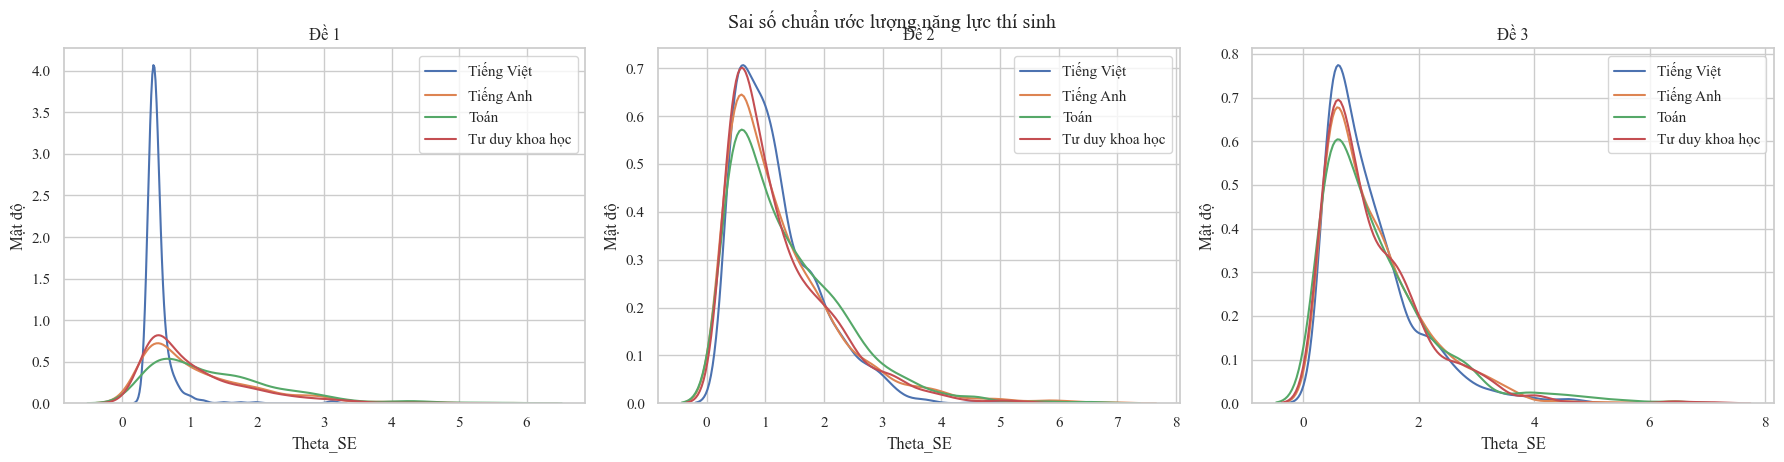

In [ ]:
def plot_theta_se(df_list, item_irt):
    items = [c for c in df_list.columns if c.startswith("Cau")]

    response = df_list[items].replace(-1, 0)

    se = irt.all_ability_se(
        response.to_numpy(),
        item_irt.loc[items][['a', 'b']].to_numpy(),
        df_list['Theta'][df_list['Null'] < 30].to_numpy()
    )

    return se


list_names = [
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"]
]

all_df_groups = [
    [df_TV1, df_TA1, df_TO1, df_KH1],
    [df_TV2, df_TA2, df_TO2, df_KH2],
    [df_TV3, df_TA3, df_TO3, df_KH3],
    [df_TV4, df_TA4, df_TO4, df_KH4]
]

all_item_irt = [
    item_irt_1,
    item_irt_2,
    item_irt_3,
    item_irt_4
]

titles = [
    "Đề 1",
    "Đề 2",
    "Đề 3",
    "Đề 4"
]

# =========================
# TẠO SUBPLOT 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, df_group, names, item_irt, title in zip(
    axes,
    all_df_groups,
    list_names,
    all_item_irt,
    titles
):
    for df, name in zip(df_group, names):

        se = plot_theta_se(df, item_irt)

        sns.kdeplot(
            se,
            label=name,
            ax=ax
        )

    ax.set_xlabel("Theta_SE")
    ax.set_ylabel('Mật độ')
    ax.set_title(title)
    ax.legend()

plt.suptitle(
    'Sai số chuẩn ước lượng năng lực thí sinh',
    y=0.98
)

plt.tight_layout()
plt.show()

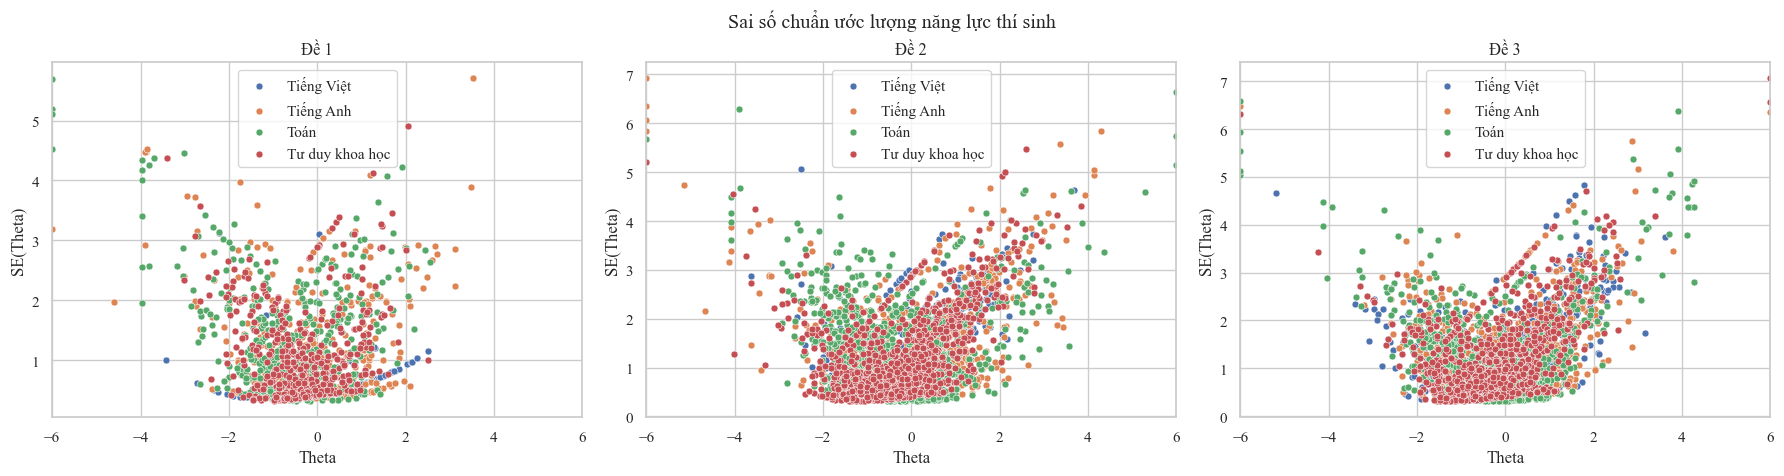

In [ ]:
list_names = [
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học"]
]

all_df_groups = [
    [df_TV1, df_TA1, df_TO1, df_KH1],
    [df_TV2, df_TA2, df_TO2, df_KH2],
    [df_TV3, df_TA3, df_TO3, df_KH3],
    [df_TV4, df_TA4, df_TO4, df_KH4]
]

all_item_irt = [
    item_irt_1,
    item_irt_2,
    item_irt_3,
    item_irt_4
]

titles = [
    "Đề 1",
    "Đề 2",
    "Đề 3",
    "Đề 4"
]

# =========================
# TẠO SUBPLOT 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, df_group, names, item_irt, title in zip(
    axes,
    all_df_groups,
    list_names,
    all_item_irt,
    titles
):
    for df, name in zip(df_group, names):

        # lọc dữ liệu giống plot_theta_se
        mask = df['Null'] < 30

        theta = df.loc[mask, 'Theta']

        theta_se = plot_theta_se(
            df,
            item_irt
        )

        sns.scatterplot(
            x=theta,
            y=theta_se,
            ax=ax,
            label=name,
            s=25
        )

    ax.set_xlabel("Theta")
    ax.set_ylabel("SE(Theta)")
    ax.set_title(title)

    ax.set_xlim(-6, 6)

    ax.legend(
        title="Môn",
        loc='upper center'
    )

plt.suptitle(
    'Sai số chuẩn ước lượng năng lực thí sinh',
    y=0.98
)

plt.tight_layout()
plt.show()

## Phân tích tương quan và phân tích hồi quy

### Tương quan điểm thực của hai đề thi

In [ ]:
df_true_1_copy, df_true_2_copy, df_true_3_copy = df_true_1.copy(), df_true_2.copy(), df_true_3.copy()
df_true_1_copy = df_true_1_copy.merge(df_dot1[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')
df_true_2_copy = df_true_2_copy.merge(df_dot2[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')
df_true_3_copy = df_true_3_copy.merge(df_dot3[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')

df_true_1_copy = df_true_1_copy.merge(df_survey, how='right', left_on='Email', right_on='Mail').dropna().drop(columns=['Mail', 'SBD']).set_index('Email')
df_true_2_copy = df_true_2_copy.merge(df_survey, how='right', left_on='Email', right_on='Mail').dropna().drop(columns=['Mail', 'SBD']).set_index('Email')
df_true_3_copy = df_true_3_copy.merge(df_survey, how='right', left_on='Email', right_on='Mail').dropna().drop(columns=['Mail', 'SBD']).set_index('Email')

In [ ]:
df_true_1 = df_true_1.merge(df_dot1[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')
df_true_2 = df_true_2.merge(df_dot2[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')
df_true_3 = df_true_3.merge(df_dot3[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')

In [ ]:
corr_12 = df_true_1.merge(df_true_2, how='inner', left_on='Email', right_on='Email', suffixes=('_1', '_2'))
corr_12

,SBD_1,TrueTV_1,TrueTA_1,TrueTO_1,TrueKH_1,Total_True_1,Email,SBD_2,TrueTV_2,TrueTA_2,TrueTO_2,TrueKH_2,Total_True_2
0,110001,217,145,55,150,567,07vudinhchien8a2@gmail.com,120001,142,140,79,101,462
1,110003,191,194,109,148,642,19.nguyenminhtuankiet.9.1@gmail.com,120003,184,181,94,174,633
2,110005,198,133,133,253,717,2008trankhanh@gmail.com,120005,191,136,154,192,673
3,110006,209,208,0,202,619,2008truongthanhxuan@gmail.com,120006,249,190,0,215,654
4,110010,204,151,26,136,517,anhao0103@gmail.com,120012,182,117,89,148,536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,110464,186,149,60,156,551,vosonghuong1002@gmail.com,120723,197,164,177,98,636
245,110466,178,144,34,93,449,vppphucdat@gmail.com,120726,152,101,36,90,379
246,110468,182,164,167,196,709,vui406319@gmail.com,120728,171,212,228,199,810
247,110472,219,130,115,170,634,vyd73822@gmail.com,120736,139,111,174,105,529


In [ ]:
# 1 - 3
corr_13 = df_true_1.merge(
    df_true_3,
    how='inner',
    on='Email',
    suffixes=('_1', '_3')
)

# 2 - 3
corr_23 = df_true_2.merge(
    df_true_3,
    how='inner',
    on='Email',
    suffixes=('_2', '_3')
)

corr_13, corr_23

(      SBD_1  TrueTV_1  TrueTA_1  TrueTO_1  TrueKH_1  Total_True_1  \
 0    110001       217       145        55       150           567   
 1    110002       152       243       202       154           751   
 2    110010       204       151        26       136           517   
 3    110015       199       190        61       133           583   
 4    110016       168       119       143       161           591   
 ..      ...       ...       ...       ...       ...           ...   
 129  110457       216       225       167       214           822   
 130  110459       180       220       132       153           685   
 131  110460       185       211        96        58           550   
 132  110468       182       164       167       196           709   
 133  110472       219       130       115       170           634   
 
                           Email   SBD_3  TrueTV_3  TrueTA_3  TrueTO_3  \
 0    07vudinhchien8a2@gmail.com  130002       143       167       105   
 1        

In [ ]:
def test_correlation(corr_both, title, x_1, x_2):
    parts = ['TV', 'TA', 'TO', 'KH']
    results = []
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for col in parts:

        # Lọc dữ liệu hợp lệ (phải có điểm thực cả hai đề thi)
        corr_check = corr_both[[f'True{col}_{x_1}', f'True{col}_{x_2}']].where(
            lambda x: (x[f'True{col}_{x_1}'] > 0) & (x[f'True{col}_{x_2}'] > 0)
        ).dropna()

        X = corr_check[[f'True{col}_{x_1}']].values.reshape(-1, 1)
        y = corr_check[f'True{col}_{x_2}'].values

        model = LinearRegression()
        model.fit(X, y)

        y_pred = model.predict(X)
        residuals = y - y_pred

        slope = model.coef_[0]
        intercept = model.intercept_
        r_sq = r2_score(y, y_pred)
        r, _ = pearsonr(corr_check[f'True{col}_{x_1}'], corr_check[f'True{col}_{x_2}'])

        mse = np.mean((y - y_pred)**2)
        rmse = np.sqrt(mse)
        n, p = X.shape
        rse = np.sqrt(np.sum(residuals**2) / (n - p - 1))
        mae = np.mean(np.abs(y - y_pred))
        skewness = skew(residuals)

        results.append([
            col, r_sq, r, mse, rmse, mae, rse,
            skewness,
        ])
        sns.scatterplot(
            data=corr_check,
            x=f'True{col}_{x_1}',
            y=f'True{col}_{x_2}',
            ax=axes[['TV', 'TA', 'TO', 'KH'].index(col)]
        )
        sns.lineplot(
            x=corr_check[f'True{col}_{x_1}'],
            y=y_pred,
            color='red',
            linewidth=2,
            ax=axes[['TV', 'TA', 'TO', 'KH'].index(col)]
        )
        axes[['TV', 'TA', 'TO', 'KH'].index(col)].set_xlim(0, 300)
        axes[['TV', 'TA', 'TO', 'KH'].index(col)].set_ylim(0, 300)

        plt.suptitle(title, y=0.92)

    df_reg = pd.DataFrame(results, columns=[
        'Section', 'R²', 'Pearson_r',
        'MSE', 'RMSE', 'MAE', 'RSE',
        'Skewness'
    ])
    print(f"=== {title} ===")
    print(df_reg.round(4))

=== Tương quan tuyến tính giữa Đề 1 và Đề 2 theo từng phần thi ===
  Section      R²  Pearson_r        MSE     RMSE      MAE      RSE  Skewness
0      TV  0.1609     0.4011  1253.8590  35.4099  27.6925  35.5535   -0.1853
1      TA  0.3266     0.5715  2117.6886  46.0184  35.6912  46.2073    0.3571
2      TO  0.4772     0.6908  2216.4184  47.0789  37.2501  47.2813   -0.2140
3      KH  0.3027     0.5502  1620.0045  40.2493  31.5603  40.4202    0.0595
=== Tương quan tuyến tính giữa Đề 1 và Đề 3 theo từng phần thi ===
  Section      R²  Pearson_r        MSE     RMSE      MAE      RSE  Skewness
0      TV  0.1460     0.3821  1257.5199  35.4615  26.2105  35.7292   -0.9034
1      TA  0.3871     0.6221  1786.6826  42.2692  33.4594  42.5906    0.2587
2      TO  0.3313     0.5756  1869.2537  43.2349  33.4722  43.5850   -0.4274
3      KH  0.1535     0.3917  2336.0979  48.3332  38.6864  48.7093    0.1125
=== Tương quan tuyến tính giữa Đề 2 và Đề 3 theo từng phần thi ===
  Section      R²  Pearson_r 

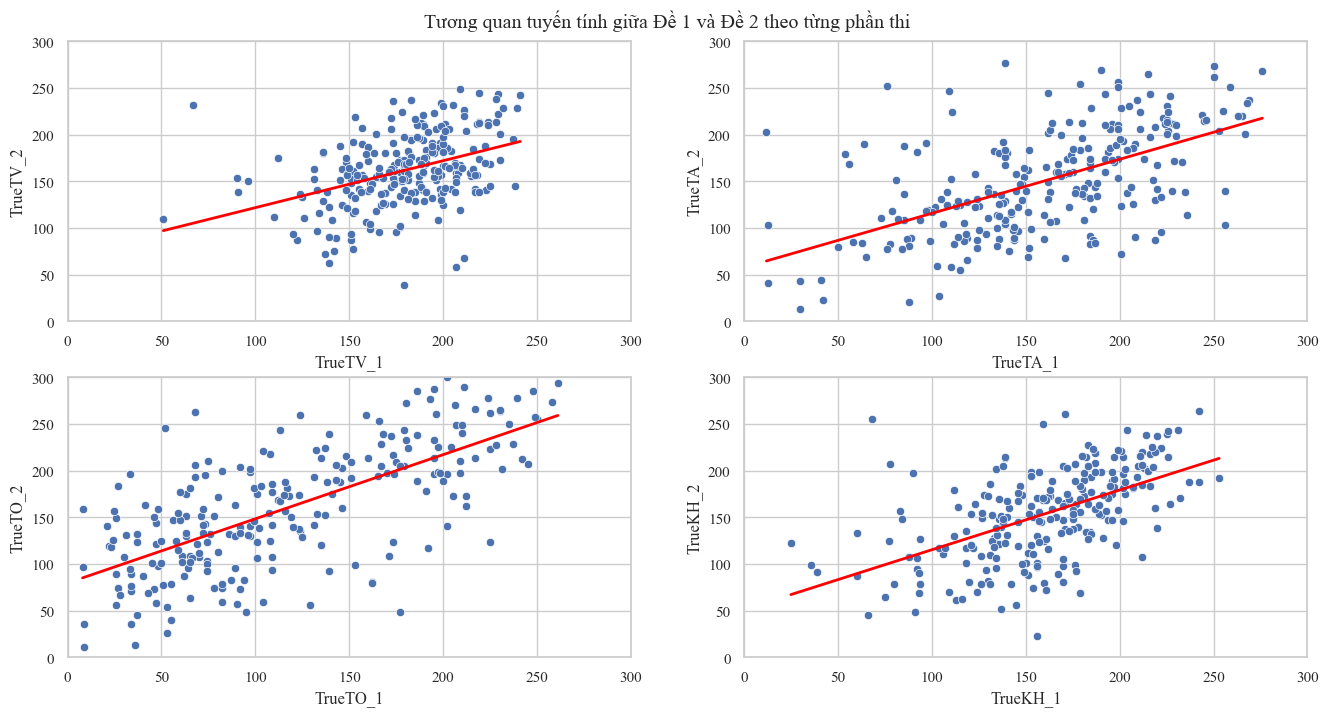

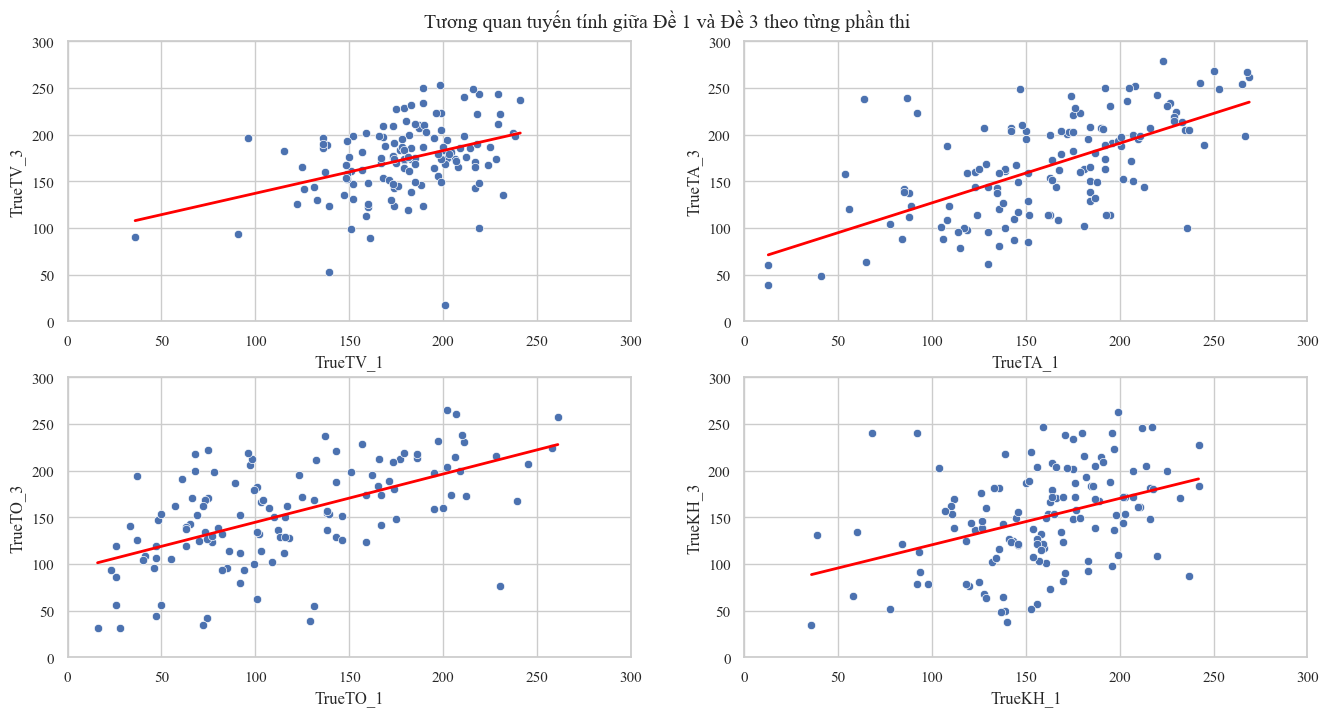

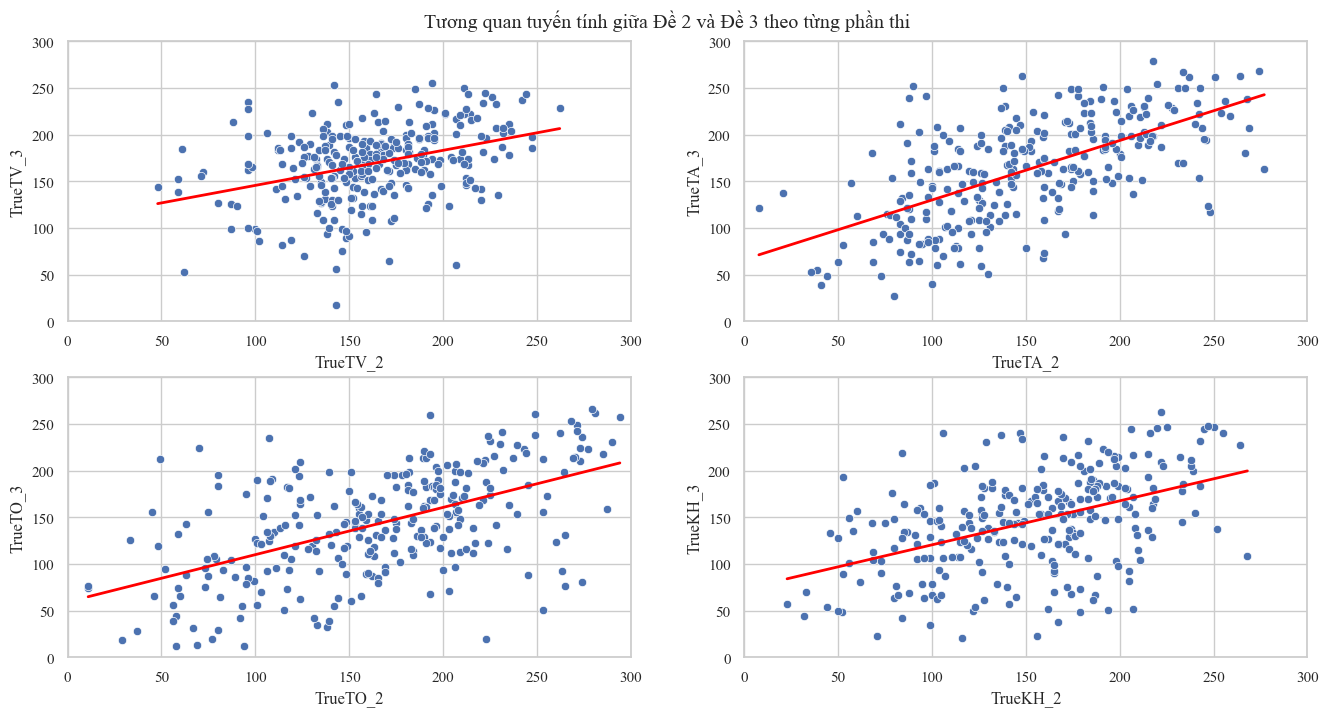

In [ ]:
reg_12 = test_correlation(
    corr_12,
    'Tương quan tuyến tính giữa Đề 1 và Đề 2 theo từng phần thi',
    x_1=1, x_2=2
)

reg_13 = test_correlation(
    corr_13,
    'Tương quan tuyến tính giữa Đề 1 và Đề 3 theo từng phần thi',
    x_1=1, x_2=3
)

reg_23 = test_correlation(
    corr_23,
    'Tương quan tuyến tính giữa Đề 2 và Đề 3 theo từng phần thi',
    x_1=2, x_2=3
)


### Tương quan giữa điểm thô và điểm thực

Tương quan giữa các phần và công thức quy đổi điểm thô sang điểm thực

Đề 1
TV: True = 8.6137 × Raw + 25.0883 | r = 0.9217 | R² = 0.8495 | MSE = 154.87 | RMSE = 12.44
TA: True = 9.8194 × Raw + 3.5841 | r = 0.9915 | R² = 0.9831 | MSE = 53.77 | RMSE = 7.33
TO: True = 10.0465 × Raw + 0.7212 | r = 0.9906 | R² = 0.9812 | MSE = 72.90 | RMSE = 8.54
KH: True = 9.2381 × Raw + 13.5437 | r = 0.9646 | R² = 0.9305 | MSE = 132.67 | RMSE = 11.52


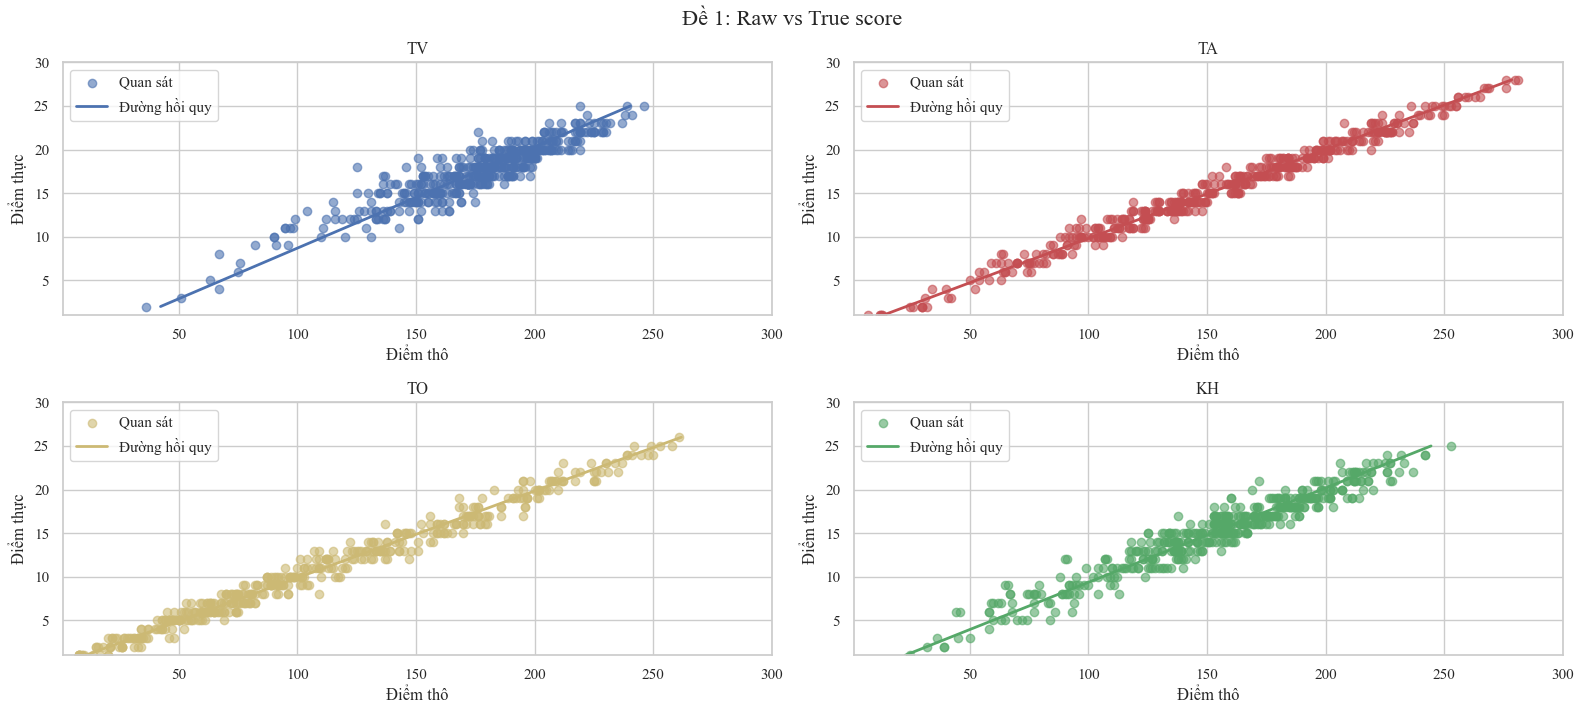


Đề 2
TV: True = 9.3131 × Raw + 11.2155 | r = 0.9666 | R² = 0.9343 | MSE = 93.35 | RMSE = 9.66
TA: True = 9.8884 × Raw + 2.5280 | r = 0.9854 | R² = 0.9711 | MSE = 89.36 | RMSE = 9.45
TO: True = 9.4321 × Raw + 12.5612 | r = 0.9871 | R² = 0.9743 | MSE = 101.87 | RMSE = 10.09
KH: True = 9.5920 × Raw + 6.5212 | r = 0.9713 | R² = 0.9434 | MSE = 146.44 | RMSE = 12.10


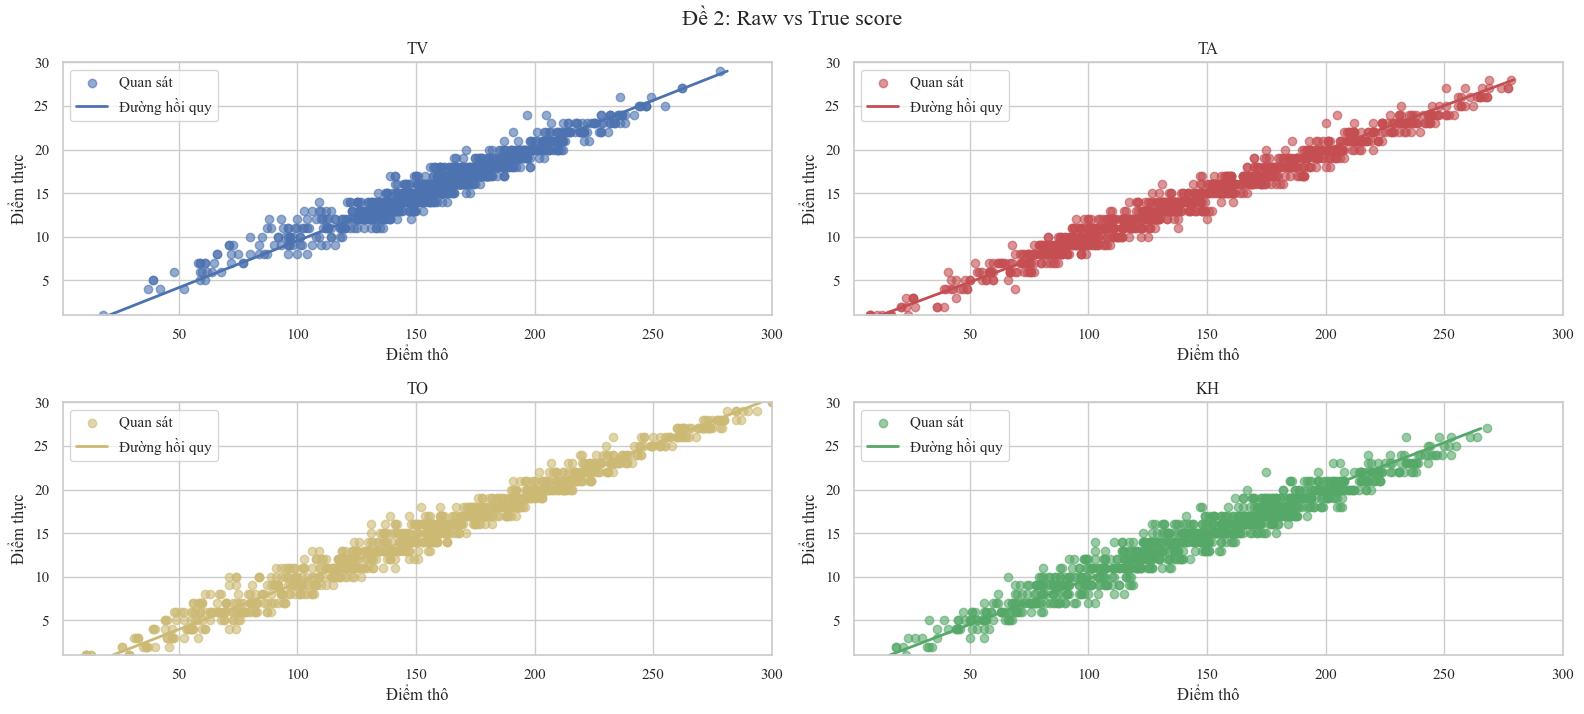


Đề 3
TV: True = 9.5554 × Raw + 7.6742 | r = 0.9776 | R² = 0.9557 | MSE = 70.65 | RMSE = 8.41
TA: True = 9.8659 × Raw + 2.7093 | r = 0.9869 | R² = 0.9739 | MSE = 77.82 | RMSE = 8.82
TO: True = 9.7244 × Raw + 5.0781 | r = 0.9890 | R² = 0.9782 | MSE = 67.89 | RMSE = 8.24
KH: True = 9.7921 × Raw + 4.8693 | r = 0.9782 | R² = 0.9569 | MSE = 110.15 | RMSE = 10.50


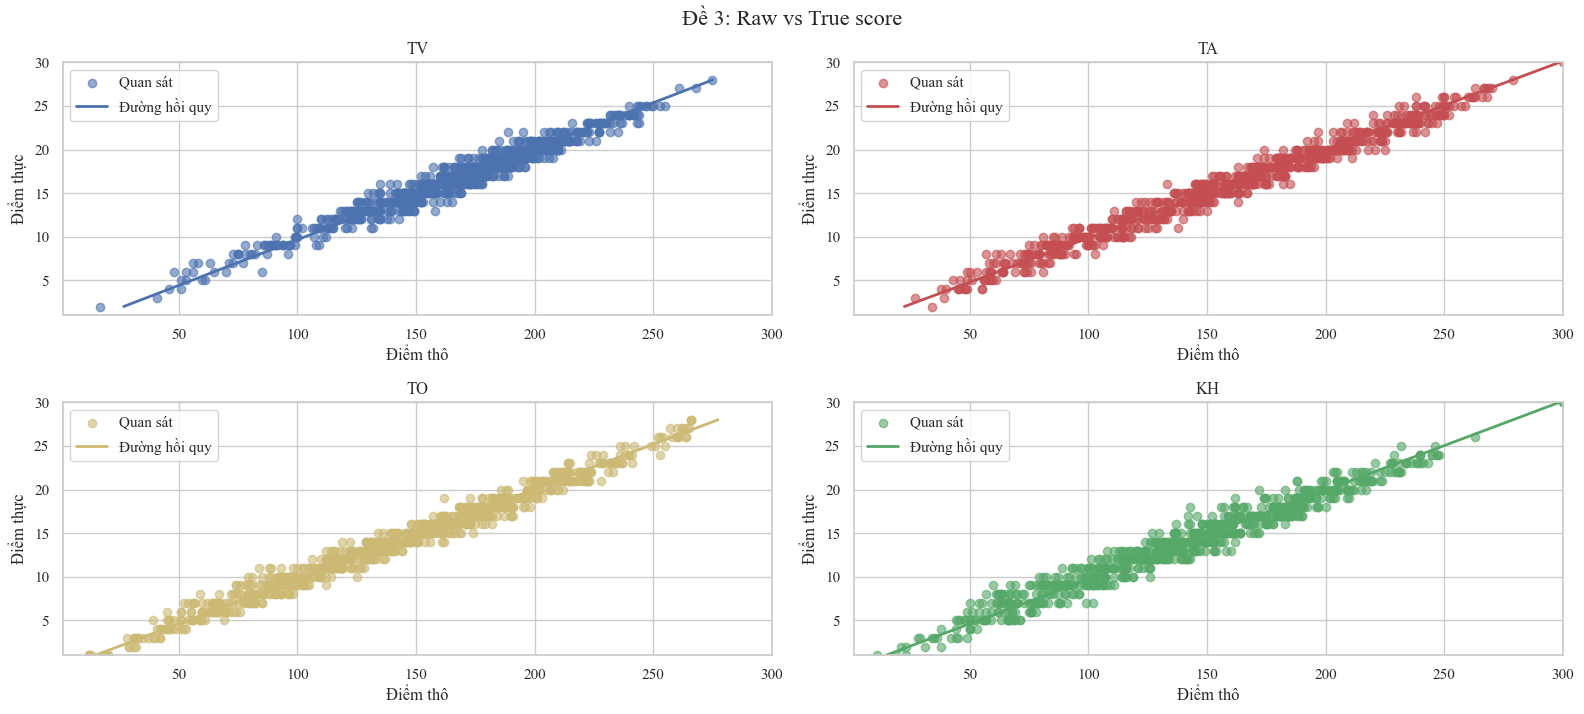

In [ ]:
def raw_true_analysis(df_list, title_prefix):
    """
    df_list: list các tuple (label, dataframe)
             dataframe phải có cột 'Raw' và 'True'
    title_prefix: 'Đề 1' hoặc 'Đề 2'
    """

    print(f'\n{title_prefix}')

    color_map = {
        'TV': 'b',
        'TA': 'r',
        'TO': 'y',
        'KH': 'g'
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for i, (label, df) in enumerate(df_list):
        # Lọc dữ liệu hợp lệ
        df_part = df[df['Raw'] > 0].copy()

        x = df_part['Raw'].to_numpy().reshape(-1, 1)
        y = df_part['True'].to_numpy()

        # 1. Tương quan Pearson
        corr, _ = pearsonr(df_part['Raw'], df_part['True'])

        # 2. Hồi quy tuyến tính
        model = LinearRegression()
        model.fit(x, y)

        alpha = model.coef_[0]
        beta = model.intercept_

        # 3. Dự đoán & sai số
        y_pred = model.predict(x)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, y_pred)

        print(
            f'{label}: '
            f'True = {alpha:.4f} × Raw + {beta:.4f} | '
            f'r = {corr:.4f} | '
            f'R² = {r2:.4f} | '
            f'MSE = {mse:.2f} | RMSE = {rmse:.2f}'
        )

        # 4. Scatter + đường hồi quy
        ax = axes[i]
        color = color_map.get(label, 'black')

        ax.scatter(
            df_part['True'],
            df_part['Raw'],
            alpha=0.6,
            color=color,
            label='Quan sát'
        )

        x_line = np.linspace(df_part['Raw'].min(), df_part['Raw'].max(), 1000)
        y_line = alpha * x_line + beta
        ax.plot(y_line, x_line, color=color, linewidth=2, label='Đường hồi quy')

        ax.set_xlabel('Điểm thô')
        ax.set_ylabel('Điểm thực')
        ax.set_xlim(1, 300)
        ax.set_ylim(1, 30)
        ax.set_title(f'{label}')

        ax.legend(loc='upper left')

    plt.suptitle(f'{title_prefix}: Raw vs True score', fontsize=16, y=0.92)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



# ===== CHẠY PHÂN TÍCH =====
print('Tương quan giữa các phần và công thức quy đổi điểm thô sang điểm thực')

# Đề 1
raw_true_analysis(
    df_list=[
        ('TV', df_TV1),
        ('TA', df_TA1),
        ('TO', df_TO1),
        ('KH', df_KH1),
    ],
    title_prefix='Đề 1'
)

# Đề 2
raw_true_analysis(
    df_list=[
        ('TV', df_TV2),
        ('TA', df_TA2),
        ('TO', df_TO2),
        ('KH', df_KH2),
    ],
    title_prefix='Đề 2'
)

# Đề 3
raw_true_analysis(
    df_list=[
        ('TV', df_TV3),
        ('TA', df_TA3),
        ('TO', df_TO3),
        ('KH', df_KH3),
    ],
    title_prefix='Đề 3'
)

### Tương quan giữa tham số cổ điển và tham số ước lượng

In [ ]:
def correlation_table(classic_list, est_list, titles, sections):
    rows = []

    for (classic, est, title) in zip(classic_list, est_list, titles):
        for start, name in sections:

            x = classic.iloc[start:start+30]
            y = est.iloc[start:start+30]

            # Loại NaN và inf
            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            # Nếu đủ số quan sát thì tính corr
            if len(x) > 2:
                corr, _ = pearsonr(x, y)
                corr = round(corr, 4)
            else:
                corr = np.nan

            rows.append([title, name, corr])

    df = pd.DataFrame(rows, columns=["Pair", "Section", "Corr"])
    return df.pivot(index="Pair", columns="Section", values="Corr")


sections = [(0, 'TV'), (30, 'TA'), (60, 'TO'), (90, 'KH')]
titles = ["Diff", "Disc", "Pt.Bis"]

classic_list_1 = [1 - diff_1['CTT'], disc_1['D-Index'], nhieu_1['Ans']]
est_list_1     = [item_irt_1['b'], item_irt_1['a'], item_irt_1['a']]

classic_list_2 = [1 - diff_2['CTT'], disc_2['D-Index'], nhieu_2['Ans']]
est_list_2     = [item_irt_2['b'], item_irt_2['a'], item_irt_2['a']]

classic_list_3 = [1 - diff_3['CTT'], disc_3['D-Index'], nhieu_3['Ans']]
est_list_3     = [item_irt_3['b'], item_irt_3['a'], item_irt_3['a']]

table_1 = correlation_table(classic_list_1, est_list_1, titles, sections)
table_2 = correlation_table(classic_list_2, est_list_2, titles, sections)
table_3 = correlation_table(classic_list_3, est_list_3, titles, sections)

print("Tương quan giữa tham số cổ điển và tham số ước lượng\nĐỀ 1")
print(table_1)
print("\nĐỀ 2")
print(table_2)
print("\nĐỀ 3")
print(table_3)


Tương quan giữa tham số cổ điển và tham số ước lượng
ĐỀ 1
Section      KH      TA      TO      TV
Pair                                   
Diff     0.9151  0.9689  0.8958  0.9352
Disc     0.2050  0.2812  0.7226 -0.0859
Pt.Bis   0.6634  0.5881  0.7232  0.4749

ĐỀ 2
Section      KH      TA      TO      TV
Pair                                   
Diff     0.8976  0.9209  0.9512  0.9762
Disc     0.6327  0.7927 -0.1054 -0.1497
Pt.Bis   0.7409  0.9046  0.5573  0.2612

ĐỀ 3
Section      KH      TA      TO      TV
Pair                                   
Diff     0.9637  0.9155  0.9351  0.9719
Disc     0.5617  0.6936 -0.4560  0.2274
Pt.Bis   0.7393  0.8259  0.9145  0.4646


### Tương quan giữa kết quả học tập và kết quả thi thử

In [ ]:
thi_sinh_set = thisinh_all3 | thisinh_exactly2
thi_sinh = pd.Series(list(thi_sinh_set), name='Mail')

df_survey_copy = df_survey.merge(
    thi_sinh.to_frame(),
    how='right',
    on='Mail'
)


In [ ]:
df_survey_copy

,Mail,TO10_1,TV10_1,TA10_1,TO10_2,TV10_2,TA10_2,TO11_1,TV11_1,TA11_1,TO11_2,TV11_2,TA11_2
0,vinhq150708@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tthanhnu2801@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nguyentienanh240908@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dmtngoc2011@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,9.1,8.6,7.8,9.5,8.9,9.2
4,nhyynhyy1234@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,vn060308@gmail.com,9.5,8.0,9.5,9.5,8.0,9.5,9.3,8.0,9.5,9.3,8.0,9.5
453,thanhharri1554800@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,trannguyennguyen174200943@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
455,trangphuong04278@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tính toán tương giữa điểm trung bình từng học kì với điểm thực của mỗi đề (theo từng môn)

In [ ]:
def calculate_correlations(df_true):
    correlations = {}
    subjects = ['TV', 'TA', 'TO']
    semesters = ['10_1', '10_2', '11_1', '11_2']

    for subject in subjects:
        score_col = f'True{subject}'
        for sem in semesters:
            subject_col = f'{subject}{sem}'

            x = df_true[score_col]
            y = df_true[subject_col]

            # Loại bỏ NaN
            mask = (~x.isna()) & (~y.isna())
            x_valid = x[mask]
            y_valid = y[mask]

            if len(x_valid) < 2:
                correlations[f'{score_col} vs {subject_col}'] = None
                continue

            corr, _ = pearsonr(x_valid, y_valid)
            correlations[f'{score_col} vs {subject_col}'] = round(corr, 4)

    return correlations


def print_correlations(title, corr_dict):
    print(title)
    for key, value in corr_dict.items():
        print(f'{key}: {value}')
    print()


corr1 = calculate_correlations(df_true_1_copy)
corr2 = calculate_correlations(df_true_2_copy)
corr3 = calculate_correlations(df_true_3_copy)

print_correlations("Hệ số tương quan đề 1:", corr1)
print_correlations("Hệ số tương quan đề 2:", corr2)
print_correlations("Hệ số tương quan đề 3:", corr3)

Hệ số tương quan đề 1:
TrueTV vs TV10_1: 0.1708
TrueTV vs TV10_2: 0.1498
TrueTV vs TV11_1: 0.0963
TrueTV vs TV11_2: 0.0981
TrueTA vs TA10_1: 0.4188
TrueTA vs TA10_2: 0.4176
TrueTA vs TA11_1: 0.4429
TrueTA vs TA11_2: 0.4542
TrueTO vs TO10_1: 0.3192
TrueTO vs TO10_2: 0.324
TrueTO vs TO11_1: 0.2325
TrueTO vs TO11_2: 0.2713

Hệ số tương quan đề 2:
TrueTV vs TV10_1: 0.121
TrueTV vs TV10_2: 0.173
TrueTV vs TV11_1: 0.1536
TrueTV vs TV11_2: 0.1477
TrueTA vs TA10_1: 0.3183
TrueTA vs TA10_2: 0.2954
TrueTA vs TA11_1: 0.3318
TrueTA vs TA11_2: 0.3403
TrueTO vs TO10_1: 0.3261
TrueTO vs TO10_2: 0.2975
TrueTO vs TO11_1: 0.297
TrueTO vs TO11_2: 0.2792

Hệ số tương quan đề 3:
TrueTV vs TV10_1: 0.1138
TrueTV vs TV10_2: 0.1447
TrueTV vs TV11_1: 0.1192
TrueTV vs TV11_2: 0.0958
TrueTA vs TA10_1: 0.3508
TrueTA vs TA10_2: 0.3251
TrueTA vs TA11_1: 0.3599
TrueTA vs TA11_2: 0.2837
TrueTO vs TO10_1: 0.3756
TrueTO vs TO10_2: 0.2698
TrueTO vs TO11_1: 0.3127
TrueTO vs TO11_2: 0.2452

